In [1]:
import lxml
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from lxml import etree
import gzip

# Paths

In [2]:
# Output Files path
output_path = r'output/specificCarrierReceiverShapleyExample/'
if not os.path.exists(output_path):
    raise Exception("Output path does not exist: " + output_path)
else:
    print(os.listdir(output_path))

# List of run instance folders
run_instance_folders = filter(lambda x: "-200" in x and "0.01p" in x, os.listdir(output_path))
run_instance_folders = sorted(run_instance_folders)
print("Run instance folders:", run_instance_folders)

['penSweep-af0.60-p0.045-exactShapley-i00', 'penSweep-af0.75-p0.000-proportional-i01', 'allocSweep-af0.55-p0.010-exactShapley-i02', 'penSweep-af0.90-p0.045-proportional-i00', 'penSweep-af0.90-p0.035-marginal-i01', 'penSweep-af0.75-p0.035-proportional-i00', 'penSweep-af0.60-p0.020-marginal-i00', 'penSweep-af0.60-p0.003-marginal-i01', 'penSweep-af0.90-p0.020-proportional-i00', 'penSweep-af0.60-p0.015-exactShapley-i01', 'penSweep-af0.75-p0.050-proportional-i00', 'allocSweep-af0.90-p0.010-exactShapley-i01', 'penSweep-af0.60-p0.005-proportional-i02', 'penSweep-af0.90-p0.015-proportional-i01', 'penSweep-af0.60-p0.020-exactShapley-i00', 'penSweep-af0.75-p0.030-approxShapStrat-i01', 'allocSweep-af0.60-p0.010-proportional-i01', 'penSweep-af0.90-p0.015-approxShapStrat-i00', 'penSweep-af0.60-p0.040-approxShapStrat-i01', 'allocSweep-af0.60-p0.010-approxShapMC-i00', 'allocSweep-af0.50-p0.010-exactShapley-i00', 'penSweep-af0.60-p0.035-marginal-i00', 'penSweep-af0.60-p0.003-exactShapley-i02', 'penSwe

# Utils

## Count collaborative receivers

In [3]:
def count_collaborative_receivers(receiver_file_path, original_tw=(6, 8)):
    """
    Count collaborative receivers from a receiver XML file.
    
    Parameters:
    -----------
    receiver_file_path : str
        Path to the receivers.xml.gz file
    original_tw : tuple
        Original time window as (start_hour, end_hour), default is (6, 8)
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'collaborative_receivers': list of collaborative receiver details
        - 'non_collaborative_receivers': list of non-collaborative receiver details
        - 'count_collaborative': count of collaborative receivers
        - 'count_non_collaborative': count of non-collaborative receivers
    """
    from lxml import etree
    import gzip
    
    # Lists to store receiver information
    collaborative_receivers = []
    non_collaborative_receivers = []
    
    # Parse the XML file
    with gzip.open(receiver_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    # Iterate through all receivers
    for receiver in root.findall('.//receiver'):
        receiver_id = receiver.get('id')
        
        # Find the selected plan
        selected_plan = receiver.find('.//plan[@selected="yes"]')
        
        if selected_plan is not None:
            # Get the score
            score = float(selected_plan.get('score', -9999999))
            
            # Get the time window
            time_window = selected_plan.find('timeWindow')
            
            if time_window is not None:
                # Parse start and end times (format: "HH:MM:SS")
                start_time = time_window.get('start')
                end_time = time_window.get('end')
                
                # Convert to hours for comparison
                start_hour = int(start_time.split(':')[0])
                end_hour = int(end_time.split(':')[0])
                
                receiver_info = {
                    'id': receiver_id,
                    'time_window': (start_hour, end_hour),
                    'time_window_str': f"{start_time} - {end_time}",
                    'score': score
                }
                
                # Check if time window is different from original_tw
                if (start_hour, end_hour) == original_tw:
                    non_collaborative_receivers.append(receiver_info)
                else:
                    collaborative_receivers.append(receiver_info)
    total_score = 0
    for receiver in collaborative_receivers + non_collaborative_receivers:
        total_score += receiver['score']

    return {
        'collaborative_receivers': collaborative_receivers,
        'non_collaborative_receivers': non_collaborative_receivers,
        'count_collaborative': len(collaborative_receivers),
        'count_non_collaborative': len(non_collaborative_receivers),
        'total_receivers': len(collaborative_receivers) + len(non_collaborative_receivers),
        'total_score': total_score
    }

In [4]:
''' 
Plot the relationship between collaborative receivers/total scores and set factor.
    It needs a dictionary with the key as penalty value-like strings 
    and the value as the proportion of collaborative receivers.
    It will share the x-axis as penalty values, 
    and the left y-axis as the proportion of collaborative receivers; 
    the right y-axis as the total scores of all receivers.
'''
def plot_collaboration_stat(factor_type: str,
                            prop_collaborators_dict: dict, 
                            stat_total_scores_dict: dict,
                            output_path: str = None):
    if factor_type.lower() not in ['penalty', 'allocation']:
        raise ValueError("factor_type must be either 'penalty' or 'allocation'")
    if factor_type.lower() == 'penalty':
        x_label = 'Penalty Value (per second)'
        title = 'Collaboration Proportion and Total Scores with Penalty Values'
        file_name = 'collaboration_with_penalty.png'
        factor = list(prop_collaborators_dict.keys())
        factor = list(map(lambda x: list(filter(lambda y: 'p' in y, x.split("-")))[0].replace("p", ""), factor))
        # factor = sorted(factor)
    else:
        x_label = 'Allocation Factor'
        title = 'Collaboration Proportion and Total Scores with Allocation Factors'
        file_name = 'collaboration_with_allocation.png'
        factor = list(prop_collaborators_dict.keys())
        factor = list(map(lambda x: list(filter(lambda y: 'a' in y, x.split("-")))[0].replace("a", ""), factor))
        # factor = sorted(factor)
        
    factor = list(map(lambda x: float(x), factor))
    # Sort the factor and corresponding values
    sorted_indices = np.argsort(factor)
    factor = [factor[i] for i in sorted_indices]
    prop_collaborators_dict = {list(prop_collaborators_dict.keys())[i]: list(prop_collaborators_dict.values())[i] for i in sorted_indices}
    stat_total_scores_dict = {list(stat_total_scores_dict.keys())[i]: list(stat_total_scores_dict.values())[i] for i in sorted_indices}
    proportions = list(prop_collaborators_dict.values())
    total_scores = list(stat_total_scores_dict.values())

    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Proportion of Collaborative Receivers', color=color)
    ax1.plot(factor, proportions, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_xticks(factor)
    ax1.set_xticklabels([str(p) for p in factor])

    # Set the orientation of the x tick labels to vertical
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Total Scores of All Receivers', color=color)
    ax2.plot(factor, total_scores, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(min(total_scores) - 0.1*abs(min(total_scores)), max(total_scores) + 0.1*abs(max(total_scores)))
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.title(title)
    plt.grid(True)

    if output_path:
        plt.savefig(os.path.join(output_path, file_name))

# Main

In [4]:
original_tw = (6, 8) 
detail_results = {}
stat_scores = {}
stat_count_collaboration_receivers = {}
stat_prop_collaboration_receivers = {}
for run_folder in run_instance_folders:
    print(f"Analyzing run instance folder: {run_folder}")
    receiver_file_path = os.path.join(output_path, run_folder, 'receivers.xml.gz')
    if not os.path.exists(receiver_file_path):
        raise Exception("Missing receiver file.")
    
     # Original time window
    result = count_collaborative_receivers(receiver_file_path, original_tw)
    
    # Store results
    detail_results[run_folder] = result
    stat_scores[run_folder] = result['total_score']
    stat_count_collaboration_receivers[run_folder] = result['count_collaborative']
    stat_prop_collaboration_receivers[run_folder] = result['count_collaborative'] / result['total_receivers'] if result['total_receivers'] > 0 else 0

# plot_collaboration_stat(factor_type='penalty',
#                         prop_collaborators_dict=stat_prop_collaboration_receivers,
#                         stat_total_scores_dict=stat_scores,
#                         output_path=None)
plot_collaboration_stat(factor_type='allocation',
                        prop_collaborators_dict=stat_prop_collaboration_receivers,
                        stat_total_scores_dict=stat_scores,
                        output_path=None)

NameError: name 'run_instance_folders' is not defined

In [44]:
stat_scores

{'0.001-200': -1346.3733180219074,
 '0.003-200': -1403.1865585797973,
 '0.005-200': -1442.14382250386,
 '0.01-200': -1504.1314816,
 '0.02-200': -1538.3325508,
 '0.03-200': -1548.1008899522453,
 '0.035-200': -1600.0,
 '0.04-200': -1600.0,
 '0.05-200': -1600.0}

# Main for various penalty and allocation factors

In [5]:
sa_kw = ['allocSweep', 'penSweep']

# Define allocation methods
ALLOCATION_METHODS = ['exactShapley', 'marginal', 'proportional', 'approxShapMC', 'approxShapStrat']
METHOD_LABELS = {
    'exactShapley': 'Exact Shapley',
    'marginal': 'Marginal',
    'proportional': 'Proportional',
    'approxShapMC': 'Approx Shapley (MC)',
    'approxShapStrat': 'Approx Shapley (Stratified)'
}

def parse_folder_name(folder_name):
    """
    Parse folder name to extract allocation factor, penalty, and method.
    Example: 'allocSweep-af0.40-p0.010-exactShapley' -> (0.40, 0.010, 'exactShapley')
    """
    parts = folder_name.split('-')
    af = float(parts[1].replace('af', ''))
    p = float(parts[2].replace('p', ''))
    method = parts[3]
    return af, p, method

In [6]:
alloc_folders = list(filter(lambda x: sa_kw[0] in x, os.listdir(output_path)))
pen_folders = list(filter(lambda x: sa_kw[1] in x, os.listdir(output_path)))

In [7]:
def get_carrier_final_score(folder_path):
    """
    Get the final iteration's carrier score from carrier_scores.txt file.
    
    Parameters:
    -----------
    folder_path : str
        Path to the run instance folder
    
    Returns:
    --------
    float : The final carrier score (avg. EXECUTED from last iteration)
    """
    score_file = os.path.join(folder_path, 'carrier_scores.txt')
    if not os.path.exists(score_file):
        return None
    
    with open(score_file, 'r') as f:
        lines = f.readlines()
    
    # Get the last line (final iteration)
    if len(lines) > 1:
        last_line = lines[-1].strip()
        parts = last_line.split('\t')
        if len(parts) >= 2:
            return float(parts[1])  # avg. EXECUTED score
    return None


def collect_sweep_data(folders, output_path, original_tw=(6, 8)):
    """
    Collect collaboration statistics from sweep folders.
    
    Returns:
    --------
    pandas.DataFrame with columns: folder, af, penalty, method, count_collaborative, 
                                   count_non_collaborative, total_receivers, prop_collaborative, 
                                   total_score (receiver), carrier_score, combined_score
    """
    data = []
    for folder in folders:
        af, penalty, method = parse_folder_name(folder)
        folder_path = os.path.join(output_path, folder)
        receiver_file_path = os.path.join(folder_path, 'receivers.xml.gz')
        
        if os.path.exists(receiver_file_path):
            result = count_collaborative_receivers(receiver_file_path, original_tw)
            prop_collaborative = result['count_collaborative'] / result['total_receivers'] if result['total_receivers'] > 0 else 0
            
            # Get carrier score
            carrier_score = get_carrier_final_score(folder_path)
            combined_score = result['total_score'] + (carrier_score if carrier_score else 0)
            
            data.append({
                'folder': folder,
                'af': af,
                'penalty': penalty,
                'method': method,
                'count_collaborative': result['count_collaborative'],
                'count_non_collaborative': result['count_non_collaborative'],
                'total_receivers': result['total_receivers'],
                'prop_collaborative': prop_collaborative,
                'receiver_score': result['total_score'],
                'carrier_score': carrier_score,
                'combined_score': combined_score
            })
        else:
            print(f"Warning: File not found - {receiver_file_path}")
    
    return pd.DataFrame(data)

In [8]:
def plot_allocation_sweep(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis: 
    One graph with 5 lines (one per method) showing how collaboration proportion 
    changes with allocation factor (penalty fixed).
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    for method in ALLOCATION_METHODS:
        method_df = df[df['method'] == method].sort_values('af')
        if not method_df.empty:
            ax.plot(method_df['af'], method_df['prop_collaborative'], 
                   marker=markers[method], color=colors[method], 
                   label=METHOD_LABELS[method], linewidth=2, markersize=8)
    
    ax.set_xlabel('Allocation Factor', fontsize=12)
    ax.set_ylabel('Proportion of Collaborative Receivers', fontsize=12)
    ax.set_title('Sensitivity Analysis: Allocation Factor vs Collaboration\n(Penalty Fixed at 0.01)', fontsize=14)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_factor.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_allocation_sweep_separate(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis with each method in a separate subplot.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = df[df['method'] == method].sort_values('af')
        if not method_df.empty:
            ax.plot(method_df['af'], method_df['prop_collaborative'], 
                   marker='o', color=colors[method], linewidth=2, markersize=6)
            ax.fill_between(method_df['af'], method_df['prop_collaborative'], alpha=0.3, color=colors[method])
        
        ax.set_xlabel('Allocation Factor', fontsize=10)
        ax.set_ylabel('Prop. Collaborative', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Hide the unused subplot
    axes[-1].axis('off')
    
    fig.suptitle('Sensitivity Analysis: Allocation Factor vs Collaboration (by Method)\n(Penalty Fixed at 0.01)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_factor_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_allocation_sweep_scores(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis for scores:
    One graph with all methods showing receiver scores, carrier scores, and combined scores.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    score_types = [('receiver_score', 'Receiver Score'), 
                   ('carrier_score', 'Carrier Score'), 
                   ('combined_score', 'Combined Score (Receiver + Carrier)')]
    
    for ax_idx, (score_col, score_label) in enumerate(score_types):
        ax = axes[ax_idx]
        for method in ALLOCATION_METHODS:
            method_df = df[df['method'] == method].sort_values('af')
            if not method_df.empty and score_col in method_df.columns:
                ax.plot(method_df['af'], method_df[score_col], 
                       marker=markers[method], color=colors[method], 
                       label=METHOD_LABELS[method], linewidth=2, markersize=6)
        
        ax.set_xlabel('Allocation Factor', fontsize=11)
        ax.set_ylabel(score_label, fontsize=11)
        ax.set_title(f'{score_label}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    
    fig.suptitle('Score Sensitivity Analysis: Allocation Factor\n(Penalty Fixed at 0.01)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_scores.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_allocation_sweep_scores_separate(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis for scores with each method in separate subplots.
    Each subplot shows receiver, carrier, and combined scores for one method.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_scores = {'receiver_score': '#1f77b4', 'carrier_score': '#ff7f0e', 'combined_score': '#2ca02c'}
    labels_scores = {'receiver_score': 'Receiver', 'carrier_score': 'Carrier', 'combined_score': 'Combined'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = df[df['method'] == method].sort_values('af')
        
        if not method_df.empty:
            for score_col, color in colors_scores.items():
                if score_col in method_df.columns:
                    ax.plot(method_df['af'], method_df[score_col], 
                           marker='o', color=color, linewidth=2, markersize=5,
                           label=labels_scores[score_col])
        
        ax.set_xlabel('Allocation Factor', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    
    axes[-1].axis('off')
    
    fig.suptitle('Score Sensitivity Analysis: Allocation Factor (by Method)\n(Penalty Fixed at 0.01)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_scores_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

In [9]:
def plot_penalty_sweep(df, output_path=None):
    """
    Plot penalty sensitivity analysis:
    3 graphs (one per allocation factor), each with 5 lines (one per method)
    showing how collaboration proportion changes with penalty value.
    """
    allocation_factors = sorted(df['af'].unique())
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    fig, axes = plt.subplots(1, len(allocation_factors), figsize=(6*len(allocation_factors), 6), sharey=True)
    if len(allocation_factors) == 1:
        axes = [axes]
    
    for idx, af in enumerate(allocation_factors):
        ax = axes[idx]
        af_df = df[df['af'] == af]
        
        for method in ALLOCATION_METHODS:
            method_df = af_df[af_df['method'] == method].sort_values('penalty')
            if not method_df.empty:
                ax.plot(method_df['penalty'], method_df['prop_collaborative'], 
                       marker=markers[method], color=colors[method], 
                       label=METHOD_LABELS[method], linewidth=2, markersize=6)
        
        ax.set_xlabel('Penalty Value (per second)', fontsize=11)
        if idx == 0:
            ax.set_ylabel('Proportion of Collaborative Receivers', fontsize=11)
        ax.set_title(f'Allocation Factor = {af}', fontsize=12)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        
        if idx == len(allocation_factors) - 1:
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
    
    fig.suptitle('Sensitivity Analysis: Penalty vs Collaboration\n(by Allocation Factor)', fontsize=14, y=1.02)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_penalty_sweep_separate(df, output_path=None):
    """
    Plot penalty sensitivity analysis with each method in a separate subplot grid.
    Creates a grid: rows = allocation factors, columns = methods
    """
    allocation_factors = sorted(df['af'].unique())
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    
    fig, axes = plt.subplots(len(allocation_factors), len(ALLOCATION_METHODS), 
                             figsize=(4*len(ALLOCATION_METHODS), 4*len(allocation_factors)), 
                             sharey=True, sharex=True)
    
    for row_idx, af in enumerate(allocation_factors):
        af_df = df[df['af'] == af]
        
        for col_idx, method in enumerate(ALLOCATION_METHODS):
            ax = axes[row_idx, col_idx] if len(allocation_factors) > 1 else axes[col_idx]
            method_df = af_df[af_df['method'] == method].sort_values('penalty')
            
            if not method_df.empty:
                ax.plot(method_df['penalty'], method_df['prop_collaborative'], 
                       marker='o', color=colors[method], linewidth=2, markersize=5)
                ax.fill_between(method_df['penalty'], method_df['prop_collaborative'], 
                               alpha=0.3, color=colors[method])
            
            if row_idx == len(allocation_factors) - 1:
                ax.set_xlabel('Penalty', fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f'AF={af}\nProp. Collab.', fontsize=9)
            if row_idx == 0:
                ax.set_title(f'{METHOD_LABELS[method]}', fontsize=10, fontweight='bold')
            
            ax.set_ylim(-0.05, 1.05)
            ax.grid(True, alpha=0.3)
    
    fig.suptitle('Sensitivity Analysis: Penalty vs Collaboration\n(by Method and Allocation Factor)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_penalty_sweep_scores(df, output_path=None):
    """
    Plot penalty sensitivity analysis for scores:
    3 rows (allocation factors) x 3 cols (receiver, carrier, combined scores)
    Each subplot has 5 lines (methods)
    """
    allocation_factors = sorted(df['af'].unique())
    score_types = [('receiver_score', 'Receiver Score'), 
                   ('carrier_score', 'Carrier Score'), 
                   ('combined_score', 'Combined Score')]
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    fig, axes = plt.subplots(len(allocation_factors), 3, 
                             figsize=(15, 5*len(allocation_factors)))
    
    for row_idx, af in enumerate(allocation_factors):
        af_df = df[df['af'] == af]
        
        for col_idx, (score_col, score_label) in enumerate(score_types):
            ax = axes[row_idx, col_idx] if len(allocation_factors) > 1 else axes[col_idx]
            
            for method in ALLOCATION_METHODS:
                method_df = af_df[af_df['method'] == method].sort_values('penalty')
                if not method_df.empty and score_col in method_df.columns:
                    ax.plot(method_df['penalty'], method_df[score_col], 
                           marker=markers[method], color=colors[method], 
                           label=METHOD_LABELS[method], linewidth=2, markersize=5)
            
            ax.set_xlabel('Penalty Value', fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(f'AF={af}\nScore', fontsize=10)
            if row_idx == 0:
                ax.set_title(f'{score_label}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if row_idx == 0 and col_idx == 2:
                ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    
    fig.suptitle('Score Sensitivity Analysis: Penalty\n(by Allocation Factor)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty_scores.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_penalty_sweep_scores_separate(df, output_path=None):
    """
    Plot penalty sensitivity analysis for scores with each method in separate subplots.
    Grid: rows = allocation factors, columns = methods
    Each subplot shows receiver, carrier, and combined scores for one method at one AF.
    """
    allocation_factors = sorted(df['af'].unique())
    
    colors_scores = {'receiver_score': '#1f77b4', 'carrier_score': '#ff7f0e', 'combined_score': '#2ca02c'}
    labels_scores = {'receiver_score': 'Receiver', 'carrier_score': 'Carrier', 'combined_score': 'Combined'}
    
    fig, axes = plt.subplots(len(allocation_factors), len(ALLOCATION_METHODS), 
                             figsize=(4*len(ALLOCATION_METHODS), 4*len(allocation_factors)))
    
    for row_idx, af in enumerate(allocation_factors):
        af_df = df[df['af'] == af]
        
        for col_idx, method in enumerate(ALLOCATION_METHODS):
            ax = axes[row_idx, col_idx] if len(allocation_factors) > 1 else axes[col_idx]
            method_df = af_df[af_df['method'] == method].sort_values('penalty')
            
            if not method_df.empty:
                for score_col, color in colors_scores.items():
                    if score_col in method_df.columns:
                        ax.plot(method_df['penalty'], method_df[score_col], 
                               marker='o', color=color, linewidth=2, markersize=4,
                               label=labels_scores[score_col] if row_idx == 0 and col_idx == 0 else None)
            
            if row_idx == len(allocation_factors) - 1:
                ax.set_xlabel('Penalty', fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f'AF={af}\nScore', fontsize=9)
            if row_idx == 0:
                ax.set_title(f'{METHOD_LABELS[method]}', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
    
    # Add a single legend for all subplots
    handles = [plt.Line2D([0], [0], color=c, marker='o', linewidth=2) for c in colors_scores.values()]
    fig.legend(handles, labels_scores.values(), loc='upper center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.02))
    
    fig.suptitle('Score Sensitivity Analysis: Penalty (by Method)\n', fontsize=14, y=1.05)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty_scores_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

# Run Sensitivity Analysis

In [36]:
# Collect data from allocation sweep folders
print("Collecting data from allocation sweep folders...")
alloc_df = collect_sweep_data(alloc_folders, output_path)
print(f"Collected {len(alloc_df)} records from allocation sweep")
print(f"Allocation factors: {sorted(alloc_df['af'].unique())}")
print(f"Penalty values: {sorted(alloc_df['penalty'].unique())}")
print(f"Methods: {alloc_df['method'].unique().tolist()}")
alloc_df

Collected 60 records from allocation sweep
Allocation factors: [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
Penalty values: [0.01]
Methods: ['exactShapley', 'approxShapMC', 'marginal', 'approxShapStrat', 'proportional']


,folder,af,penalty,method,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,allocSweep-af0.55-p0.010-exactShapley,0.55,0.01,exactShapley,0,8,8,0.000,-800.000000,392.142607,-407.857393
1,allocSweep-af0.55-p0.010-approxShapMC,0.55,0.01,approxShapMC,0,8,8,0.000,-800.000000,392.142607,-407.857393
2,allocSweep-af0.95-p0.010-marginal,0.95,0.01,marginal,0,8,8,0.000,-800.000000,392.142607,-407.857393
3,allocSweep-af0.95-p0.010-approxShapStrat,0.95,0.01,approxShapStrat,4,4,8,0.500,-652.958376,535.160565,-117.797811
4,allocSweep-af0.65-p0.010-approxShapStrat,0.65,0.01,approxShapStrat,3,5,8,0.375,-709.230605,637.468496,-71.762108
5,allocSweep-af0.50-p0.010-marginal,0.50,0.01,marginal,0,8,8,0.000,-800.000000,392.142607,-407.857393
6,allocSweep-af0.45-p0.010-proportional,0.45,0.01,proportional,0,8,8,0.000,-800.000000,392.142607,-407.857393
7,allocSweep-af0.50-p0.010-approxShapStrat,0.50,0.01,approxShapStrat,0,8,8,0.000,-800.000000,392.142607,-407.857393
8,allocSweep-af0.50-p0.010-approxShapMC,0.50,0.01,approxShapMC,0,8,8,0.000,-800.000000,392.142607,-407.857393
9,allocSweep-af0.50-p0.010-exactShapley,0.50,0.01,exactShapley,0,8,8,0.000,-800.000000,392.142607,-407.857393


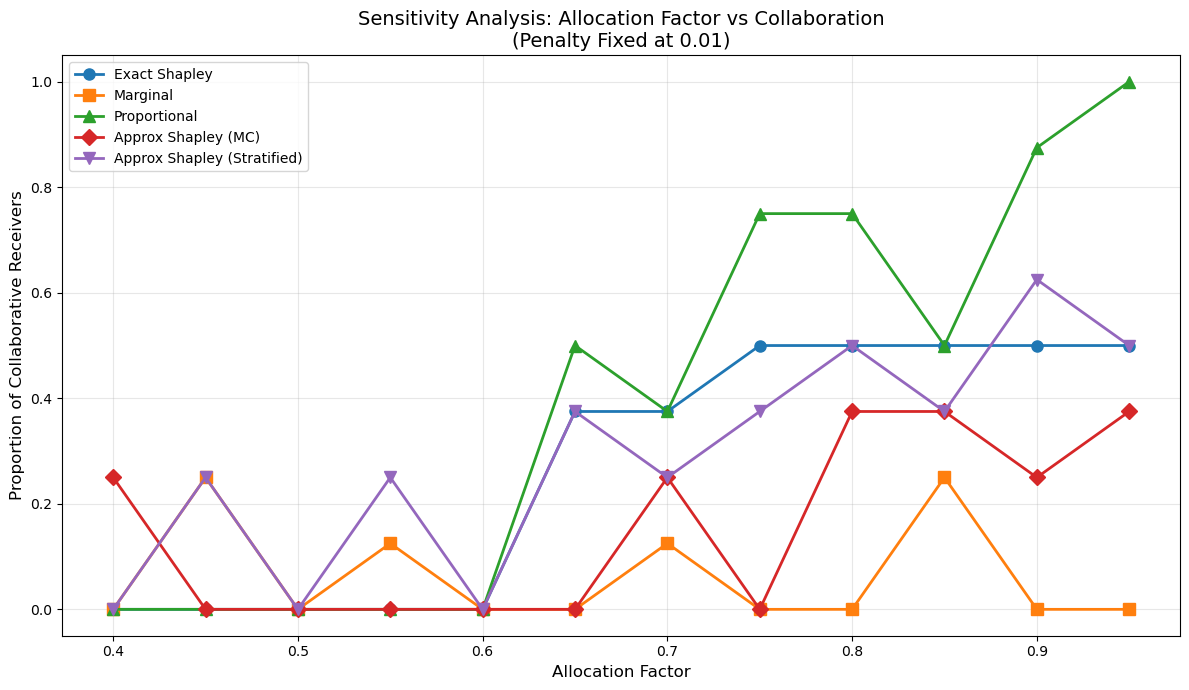

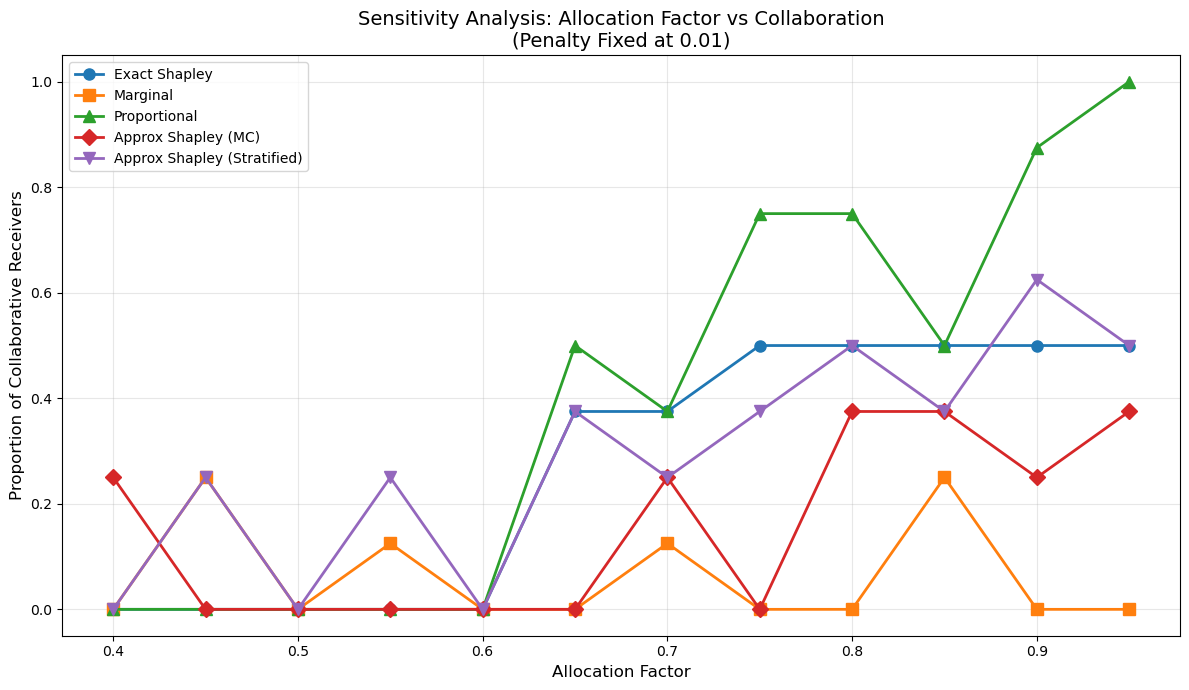

In [37]:
# Plot allocation factor sweep: Combined view (all methods in one graph)
plot_allocation_sweep(alloc_df, output_path=None)

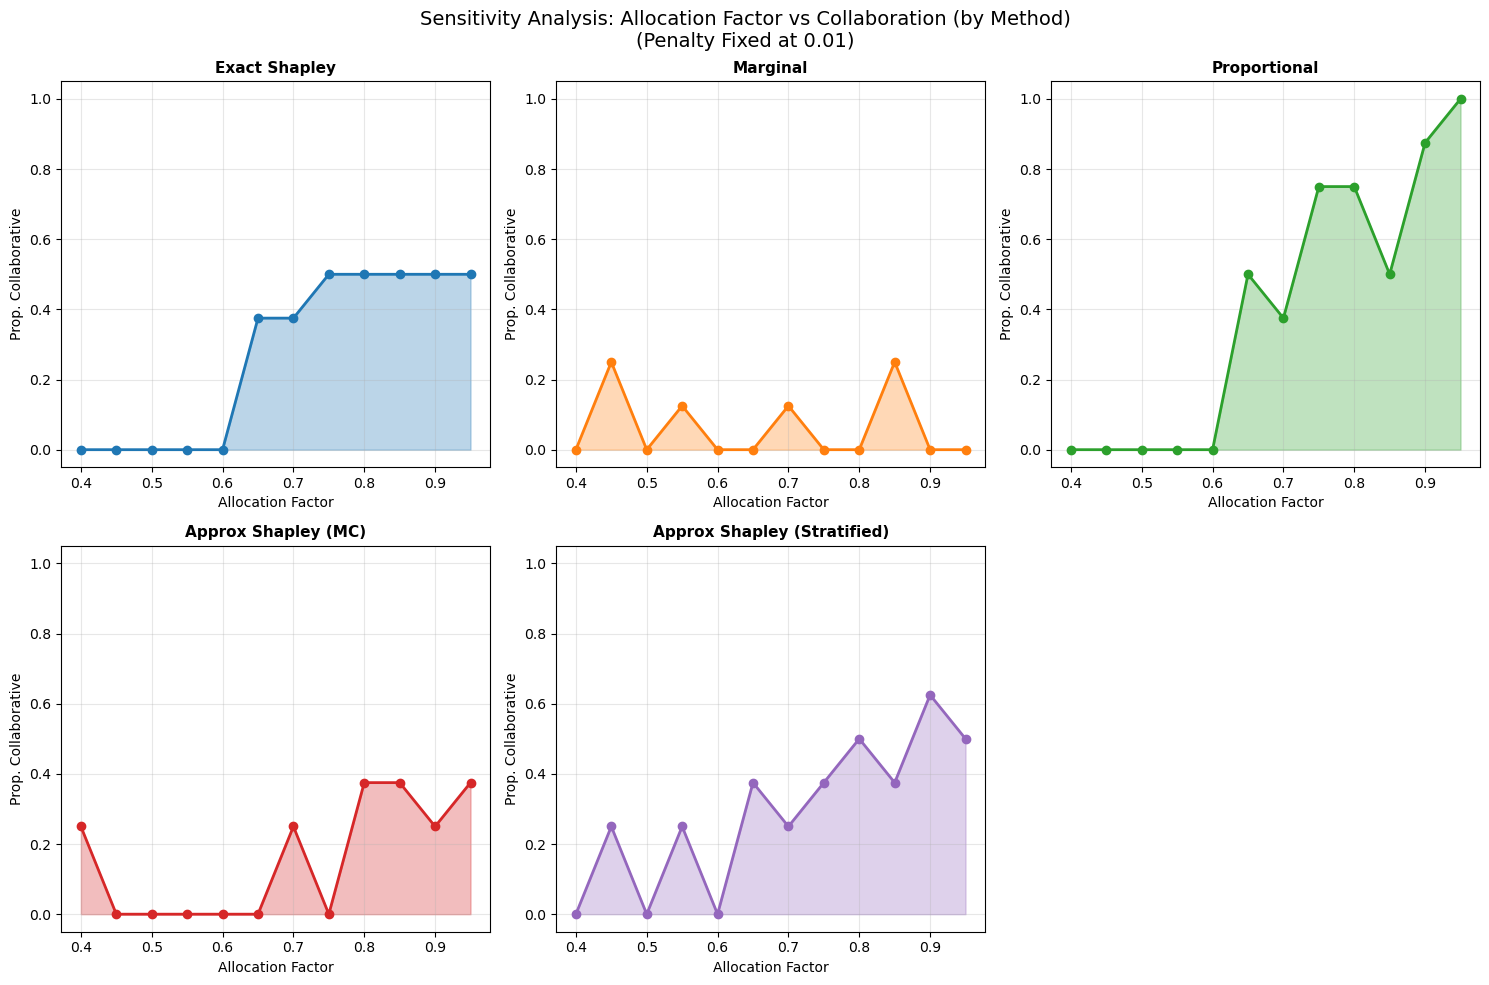

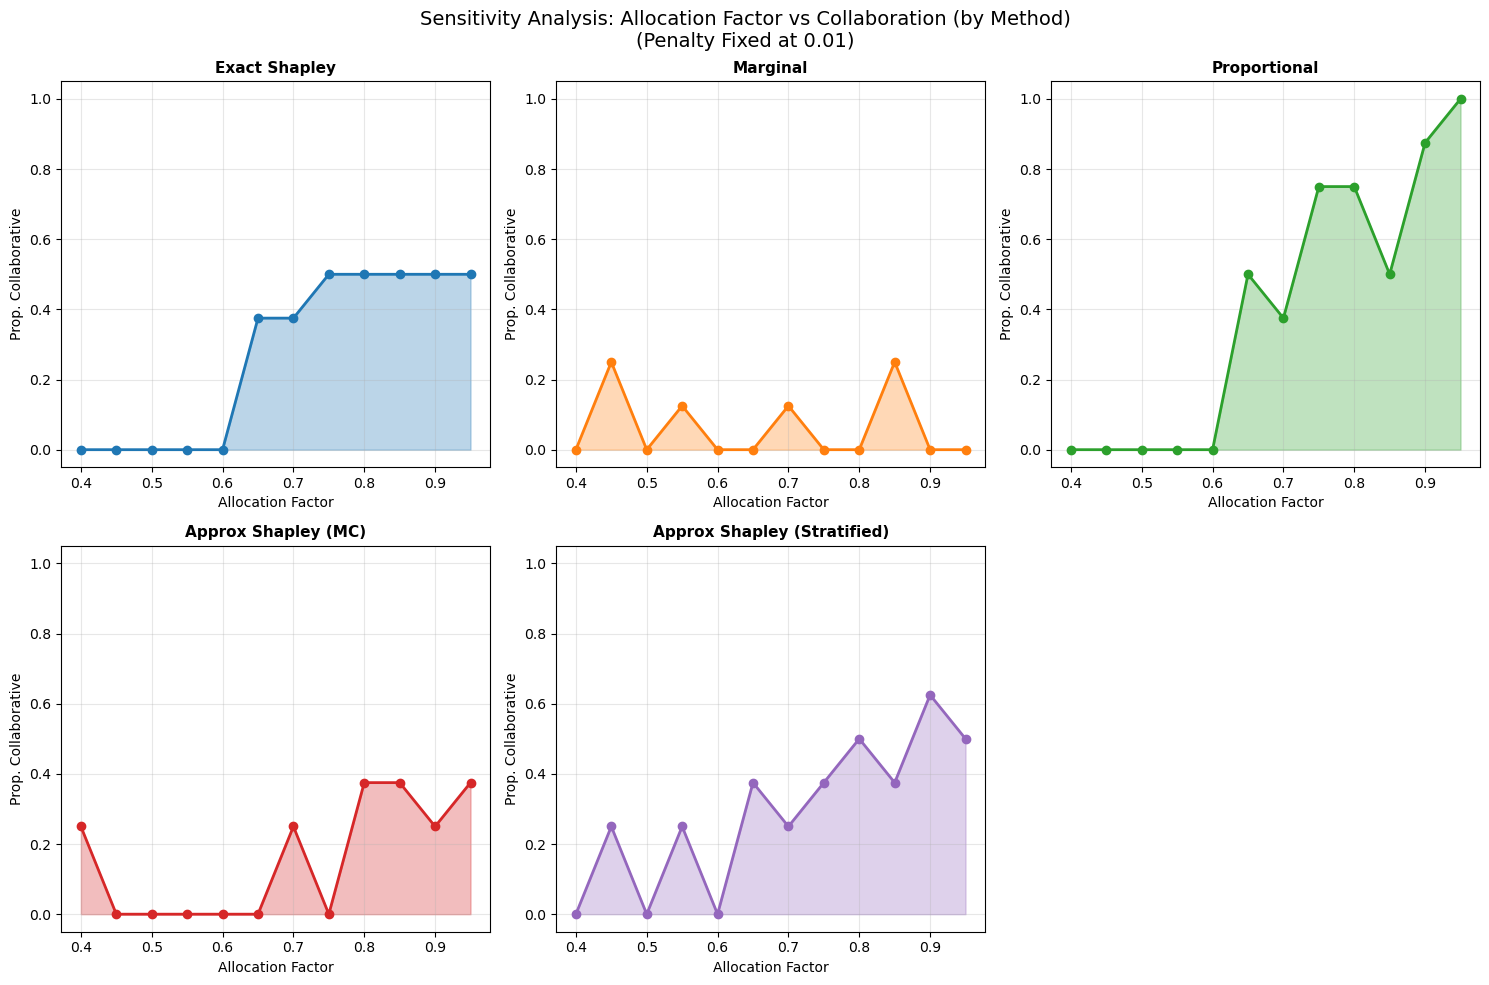

In [38]:
# Plot allocation factor sweep: Separate view (each method in its own subplot)
plot_allocation_sweep_separate(alloc_df, output_path=None)

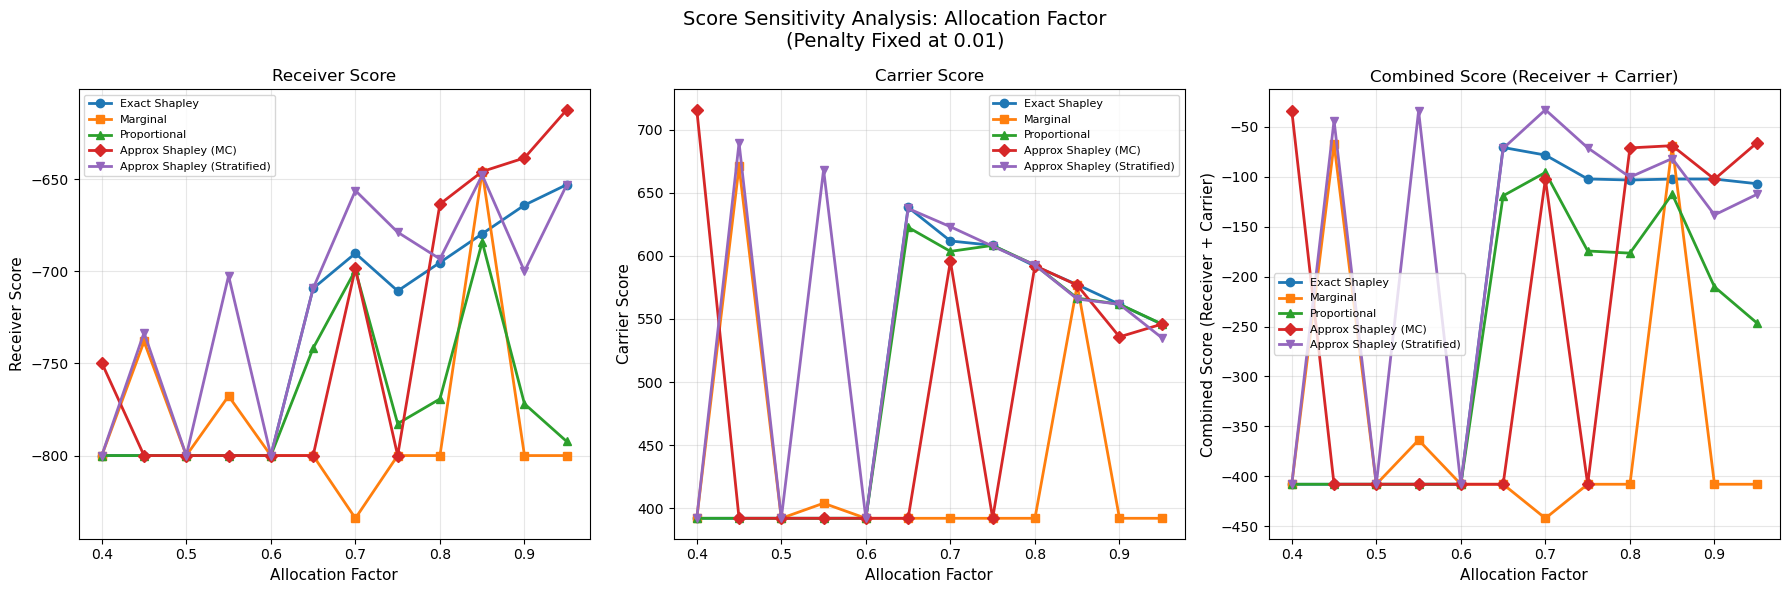

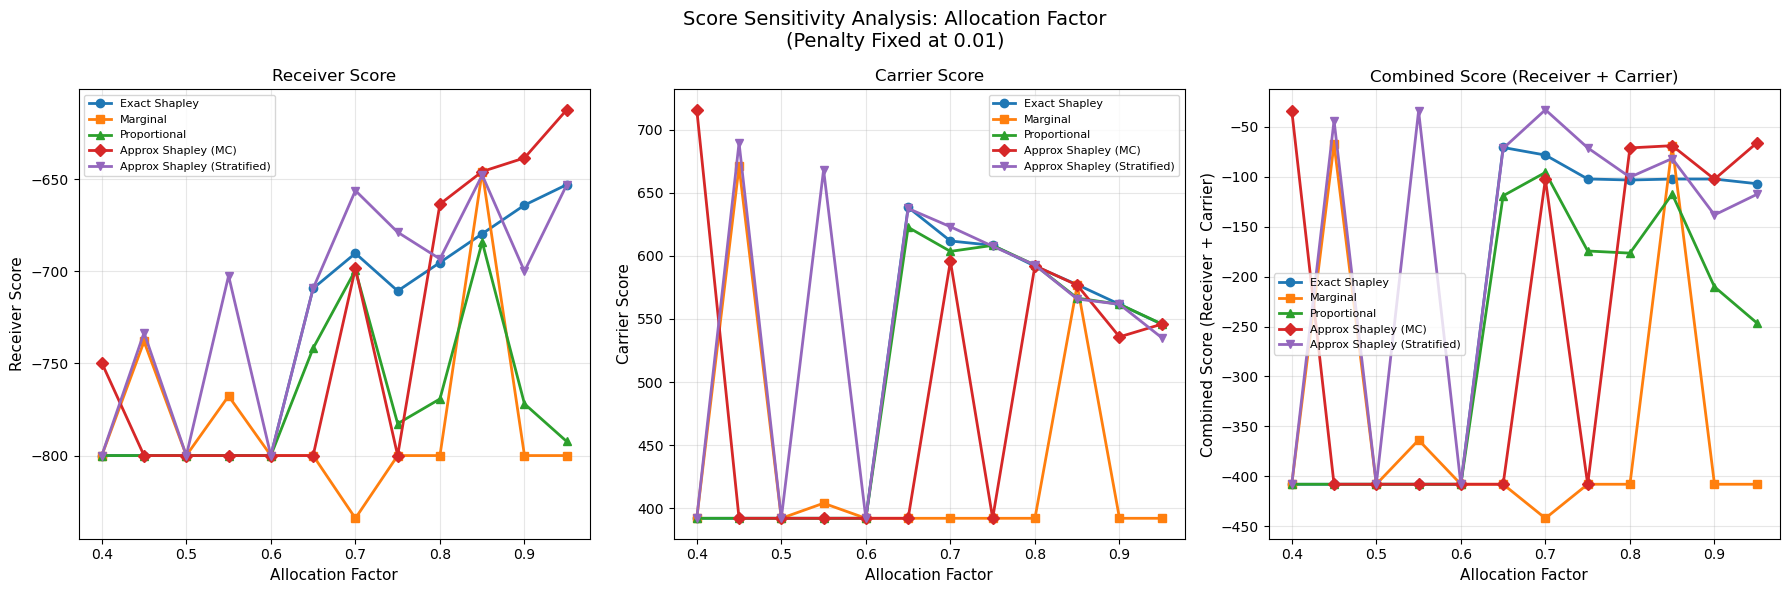

In [39]:
# Plot allocation factor sweep: Scores (receiver, carrier, combined) - All methods together
plot_allocation_sweep_scores(alloc_df, output_path=None)

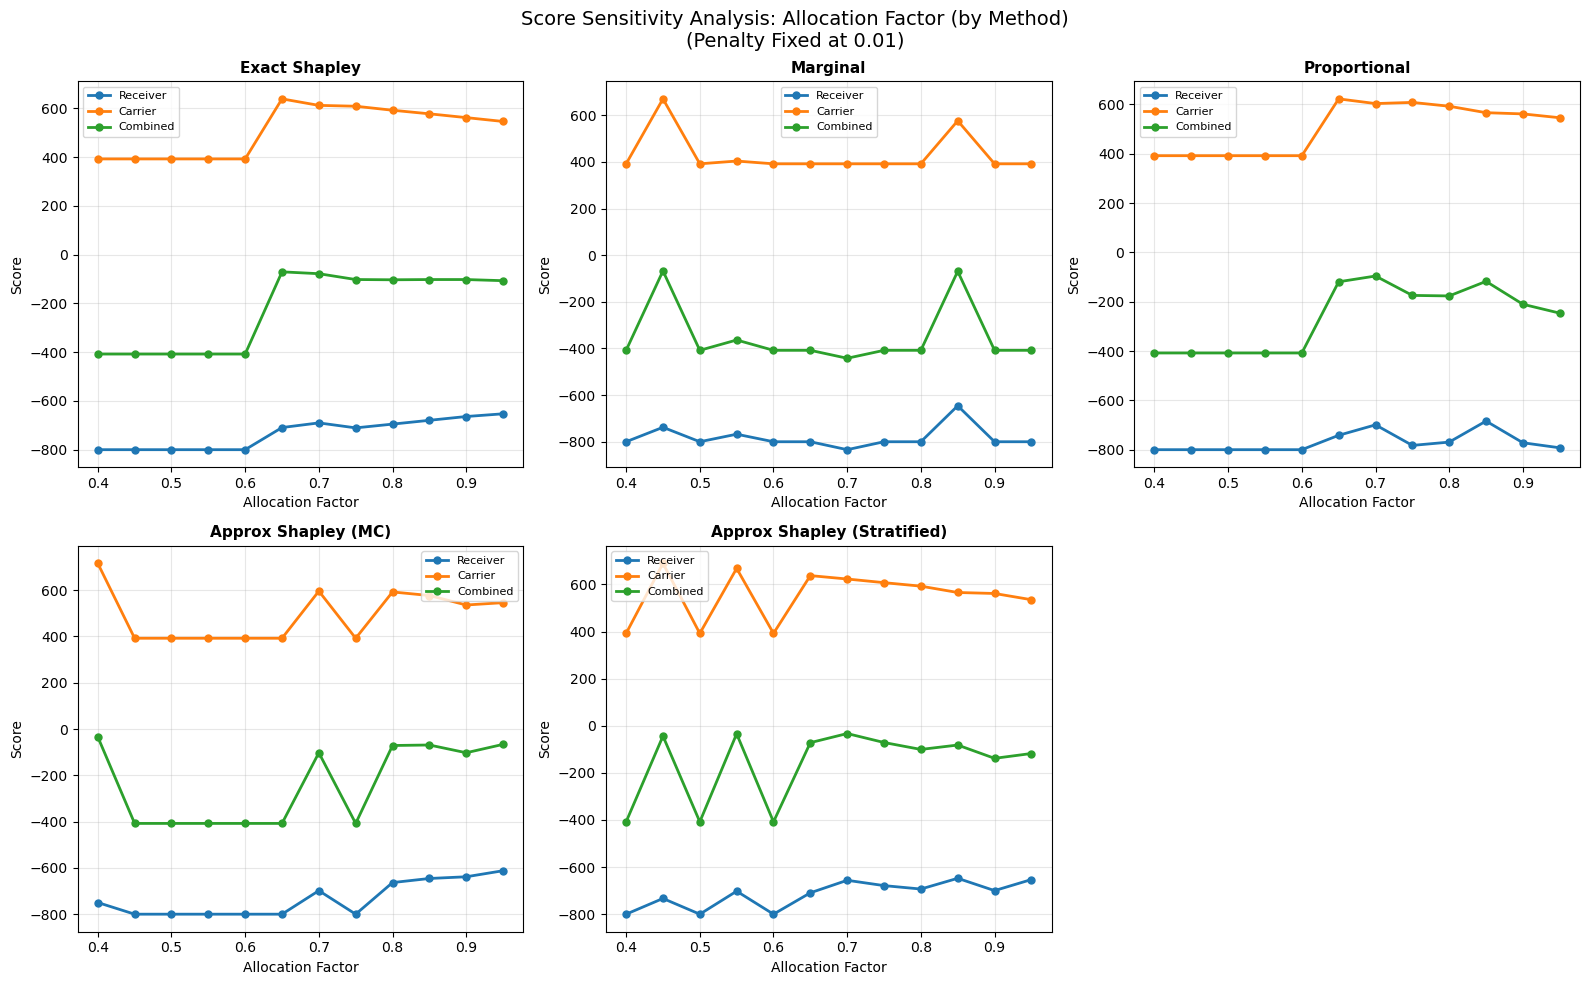

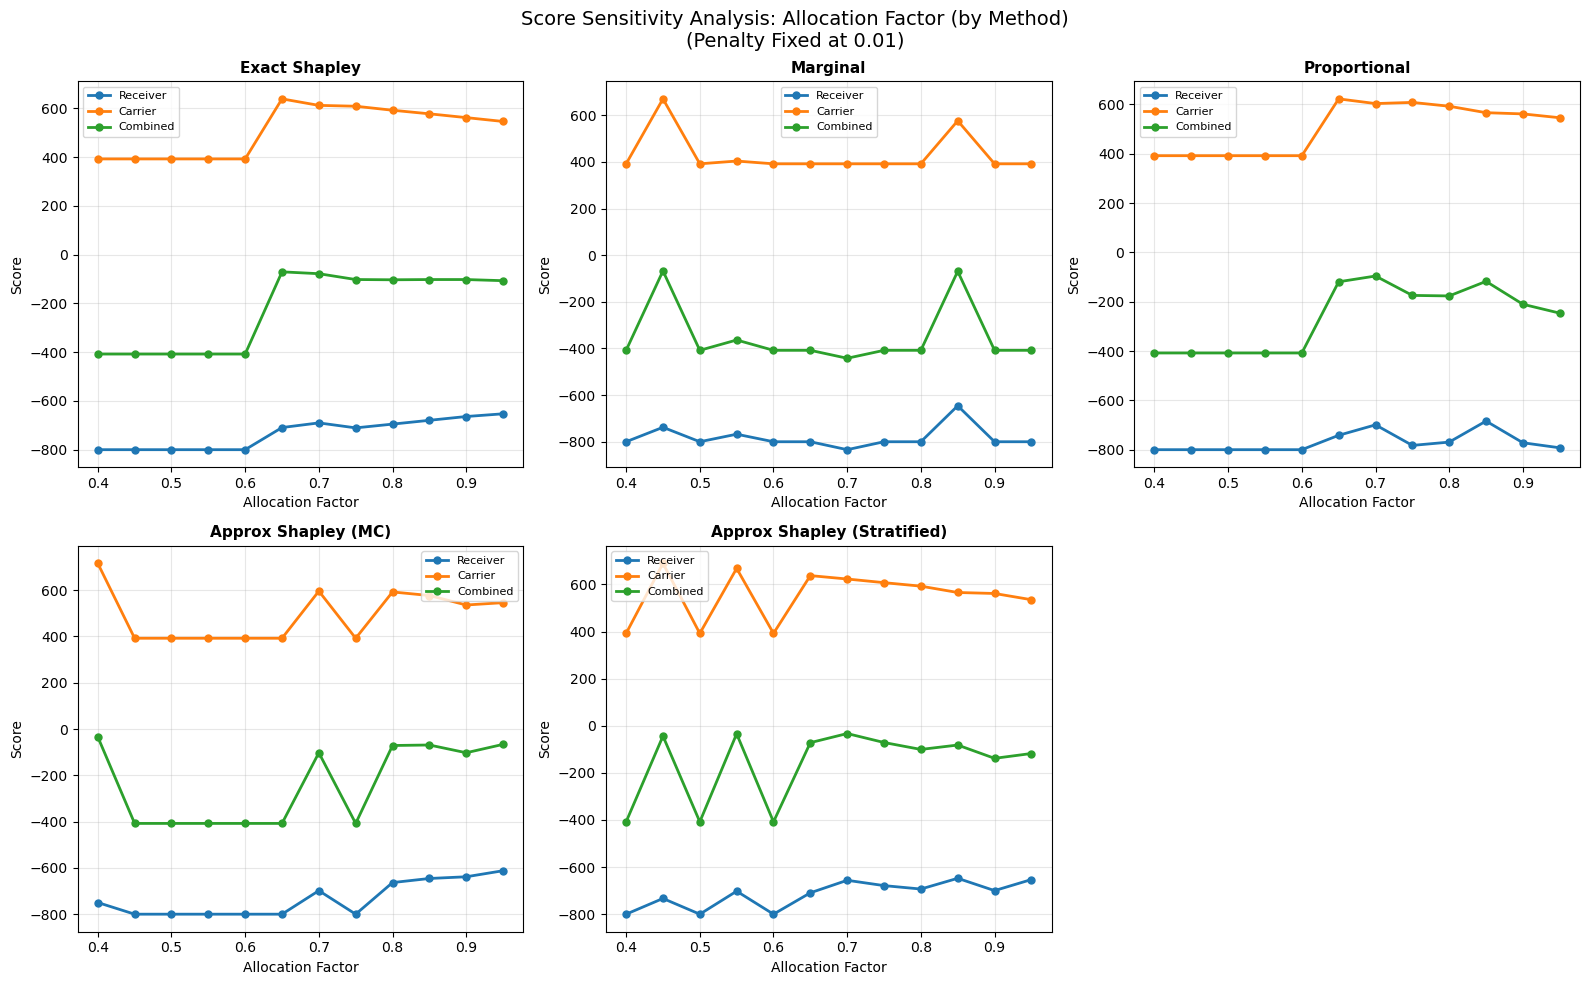

In [40]:
# Plot allocation factor sweep: Scores (receiver, carrier, combined) - Each method separate
plot_allocation_sweep_scores_separate(alloc_df, output_path=None)

In [45]:
# Collect data from penalty sweep folders
print("Collecting data from penalty sweep folders...")
pen_df = collect_sweep_data(pen_folders, output_path)
print(f"Collected {len(pen_df)} records from penalty sweep")
print(f"Allocation factors: {sorted(pen_df['af'].unique())}")
print(f"Penalty values: {sorted(pen_df['penalty'].unique())}")
print(f"Methods: {pen_df['method'].unique().tolist()}")
pen_df.head()

Collected 180 records from penalty sweep
Allocation factors: [0.6, 0.75, 0.9]
Penalty values: [0.0, 0.003, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
Methods: ['proportional', 'exactShapley', 'approxShapMC', 'approxShapStrat', 'marginal']
Collected 180 records from penalty sweep
Allocation factors: [0.6, 0.75, 0.9]
Penalty values: [0.0, 0.003, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
Methods: ['proportional', 'exactShapley', 'approxShapMC', 'approxShapStrat', 'marginal']


,folder,af,penalty,method,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,penSweep-af0.75-p0.003-proportional,0.75,0.003,proportional,8,0,8,1.000,-653.063216,608.317496,-44.745720
1,penSweep-af0.60-p0.005-exactShapley,0.60,0.005,exactShapley,5,3,8,0.625,-703.234666,655.008830,-48.225837
2,penSweep-af0.60-p0.050-exactShapley,0.60,0.050,exactShapley,0,8,8,0.000,-800.000000,392.142607,-407.857393
3,penSweep-af0.60-p0.050-approxShapMC,0.60,0.050,approxShapMC,0,8,8,0.000,-800.000000,392.142607,-407.857393
4,penSweep-af0.60-p0.005-approxShapMC,0.60,0.005,approxShapMC,4,4,8,0.500,-724.412878,642.261808,-82.151070


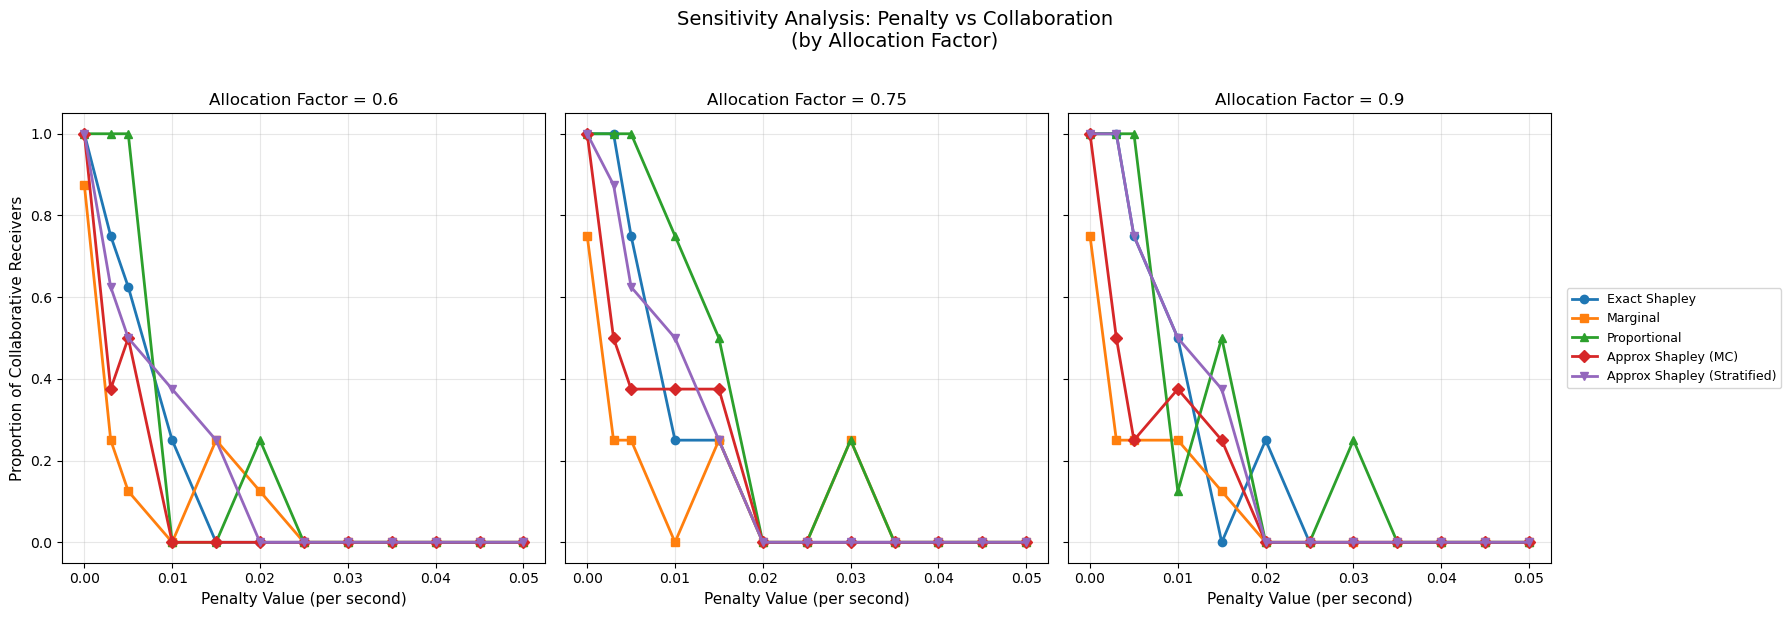

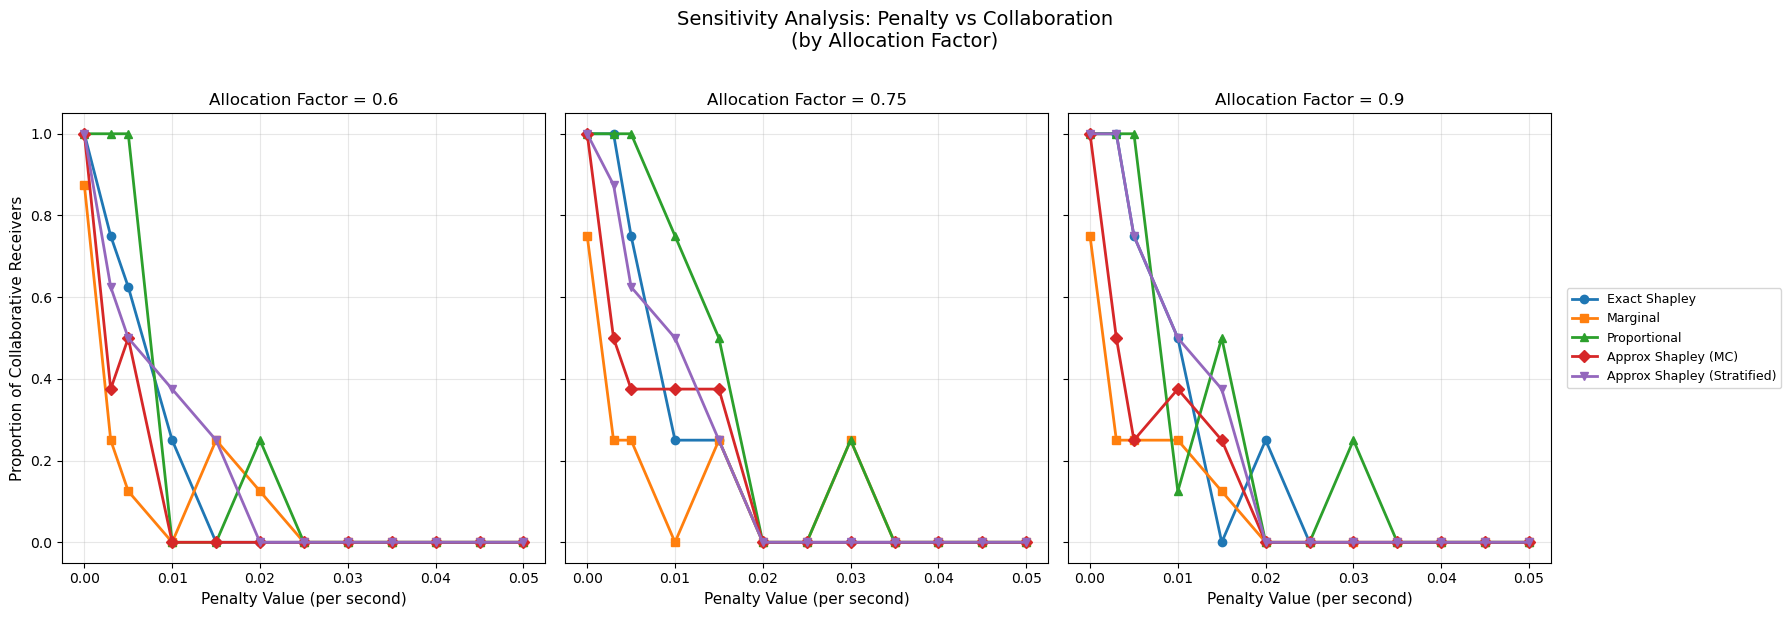

In [41]:
# Plot penalty sweep: Combined view (all methods in one graph per AF)
plot_penalty_sweep(pen_df, output_path=None)

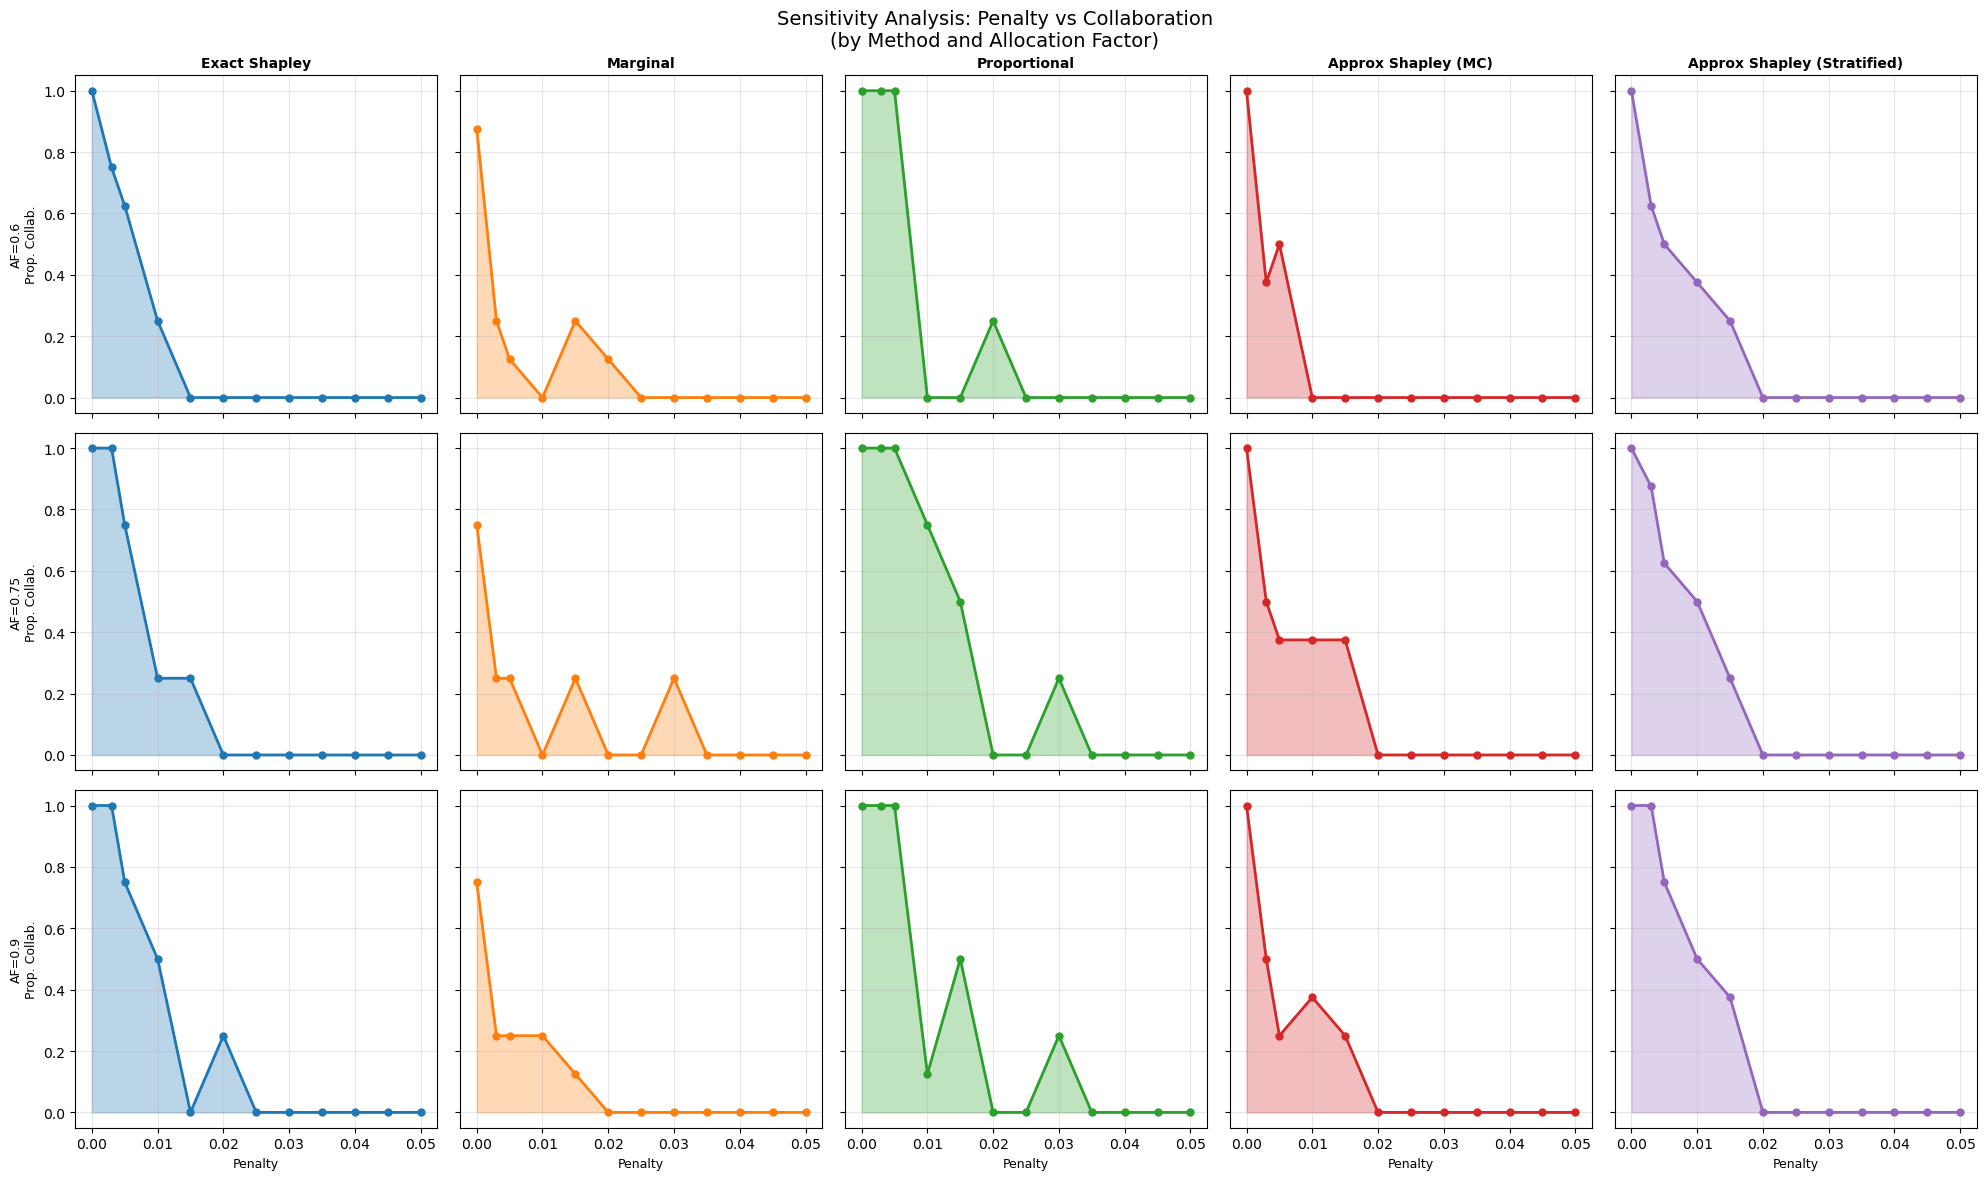

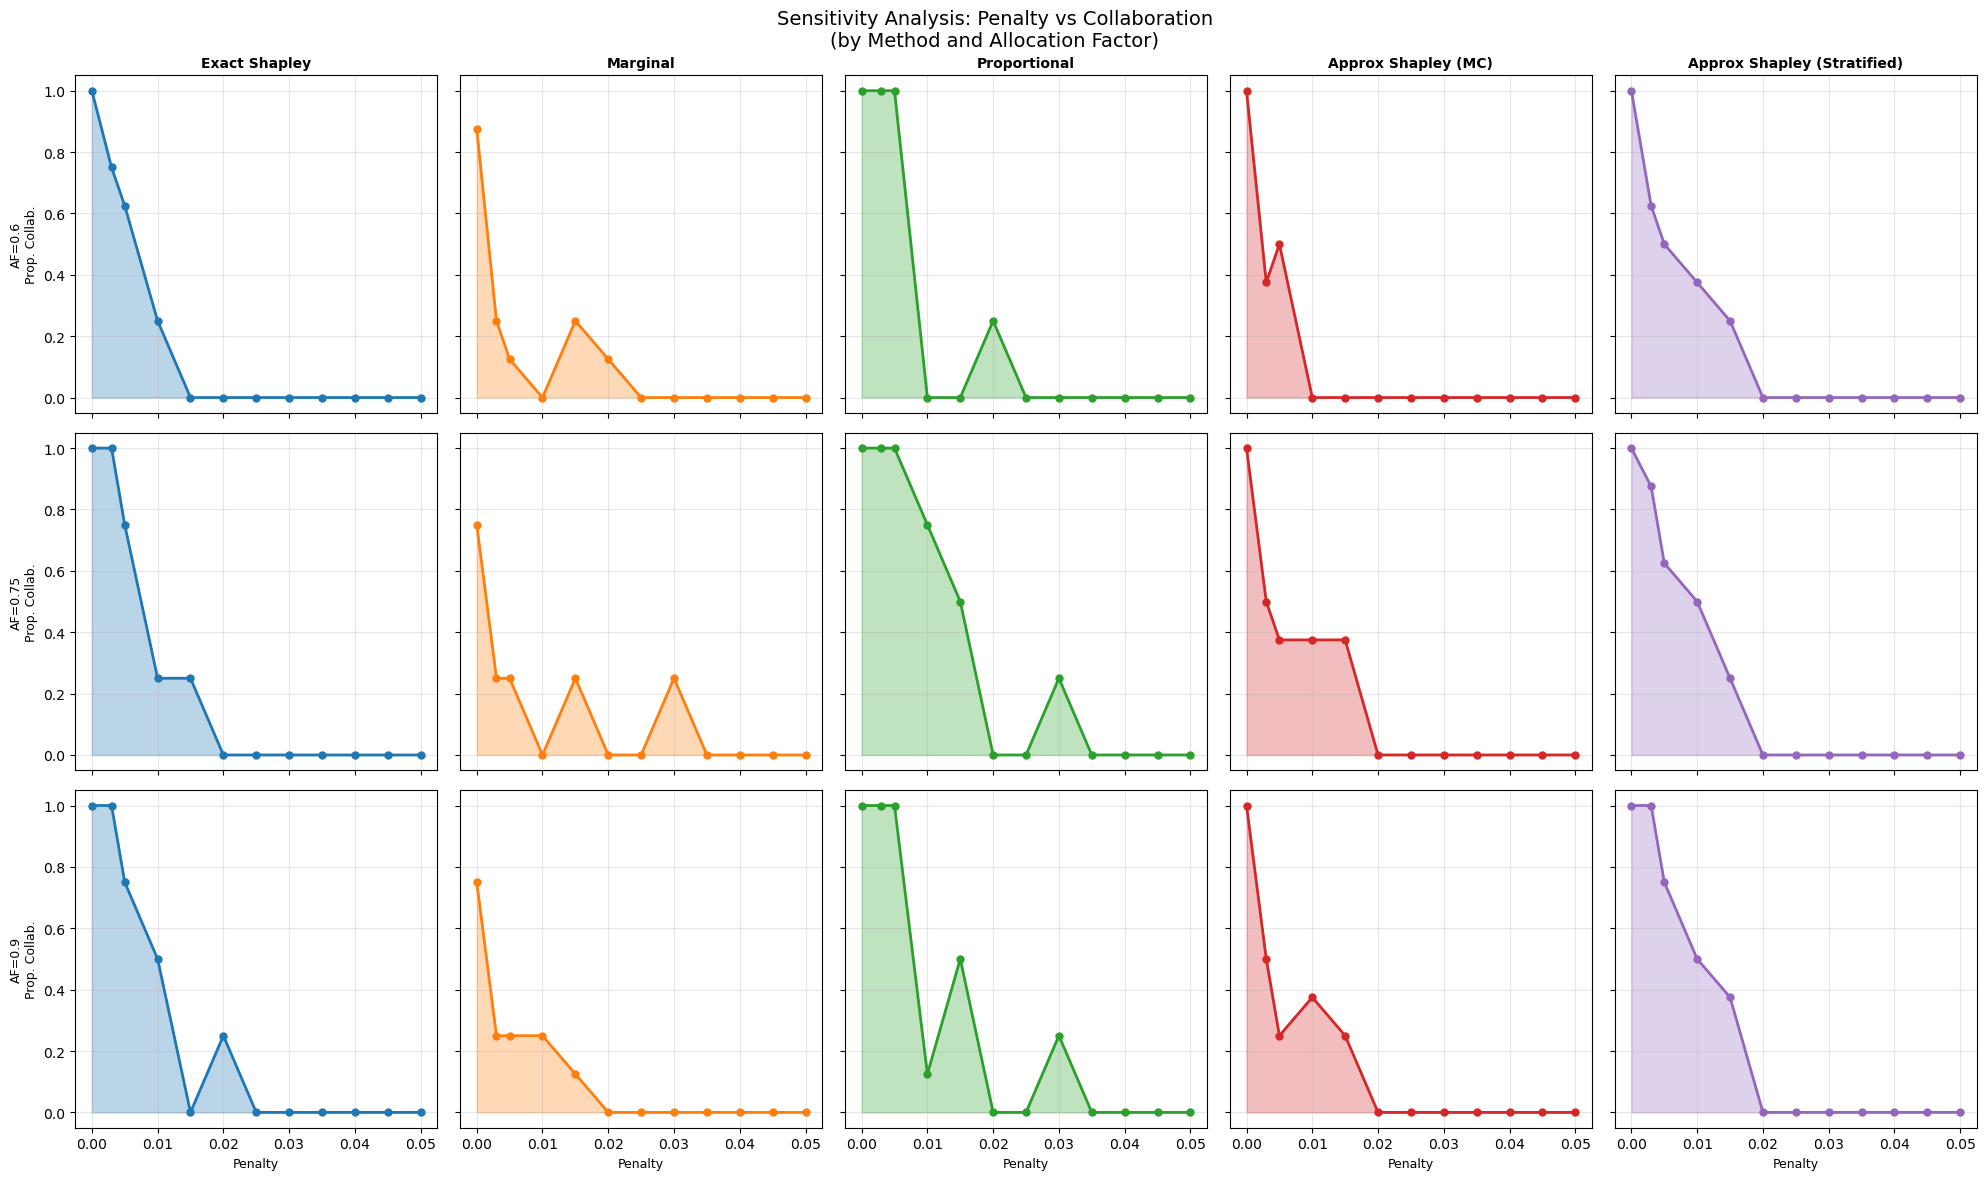

In [42]:
# Plot penalty sweep: Separate view (grid of AF x Method)
plot_penalty_sweep_separate(pen_df, output_path=None)

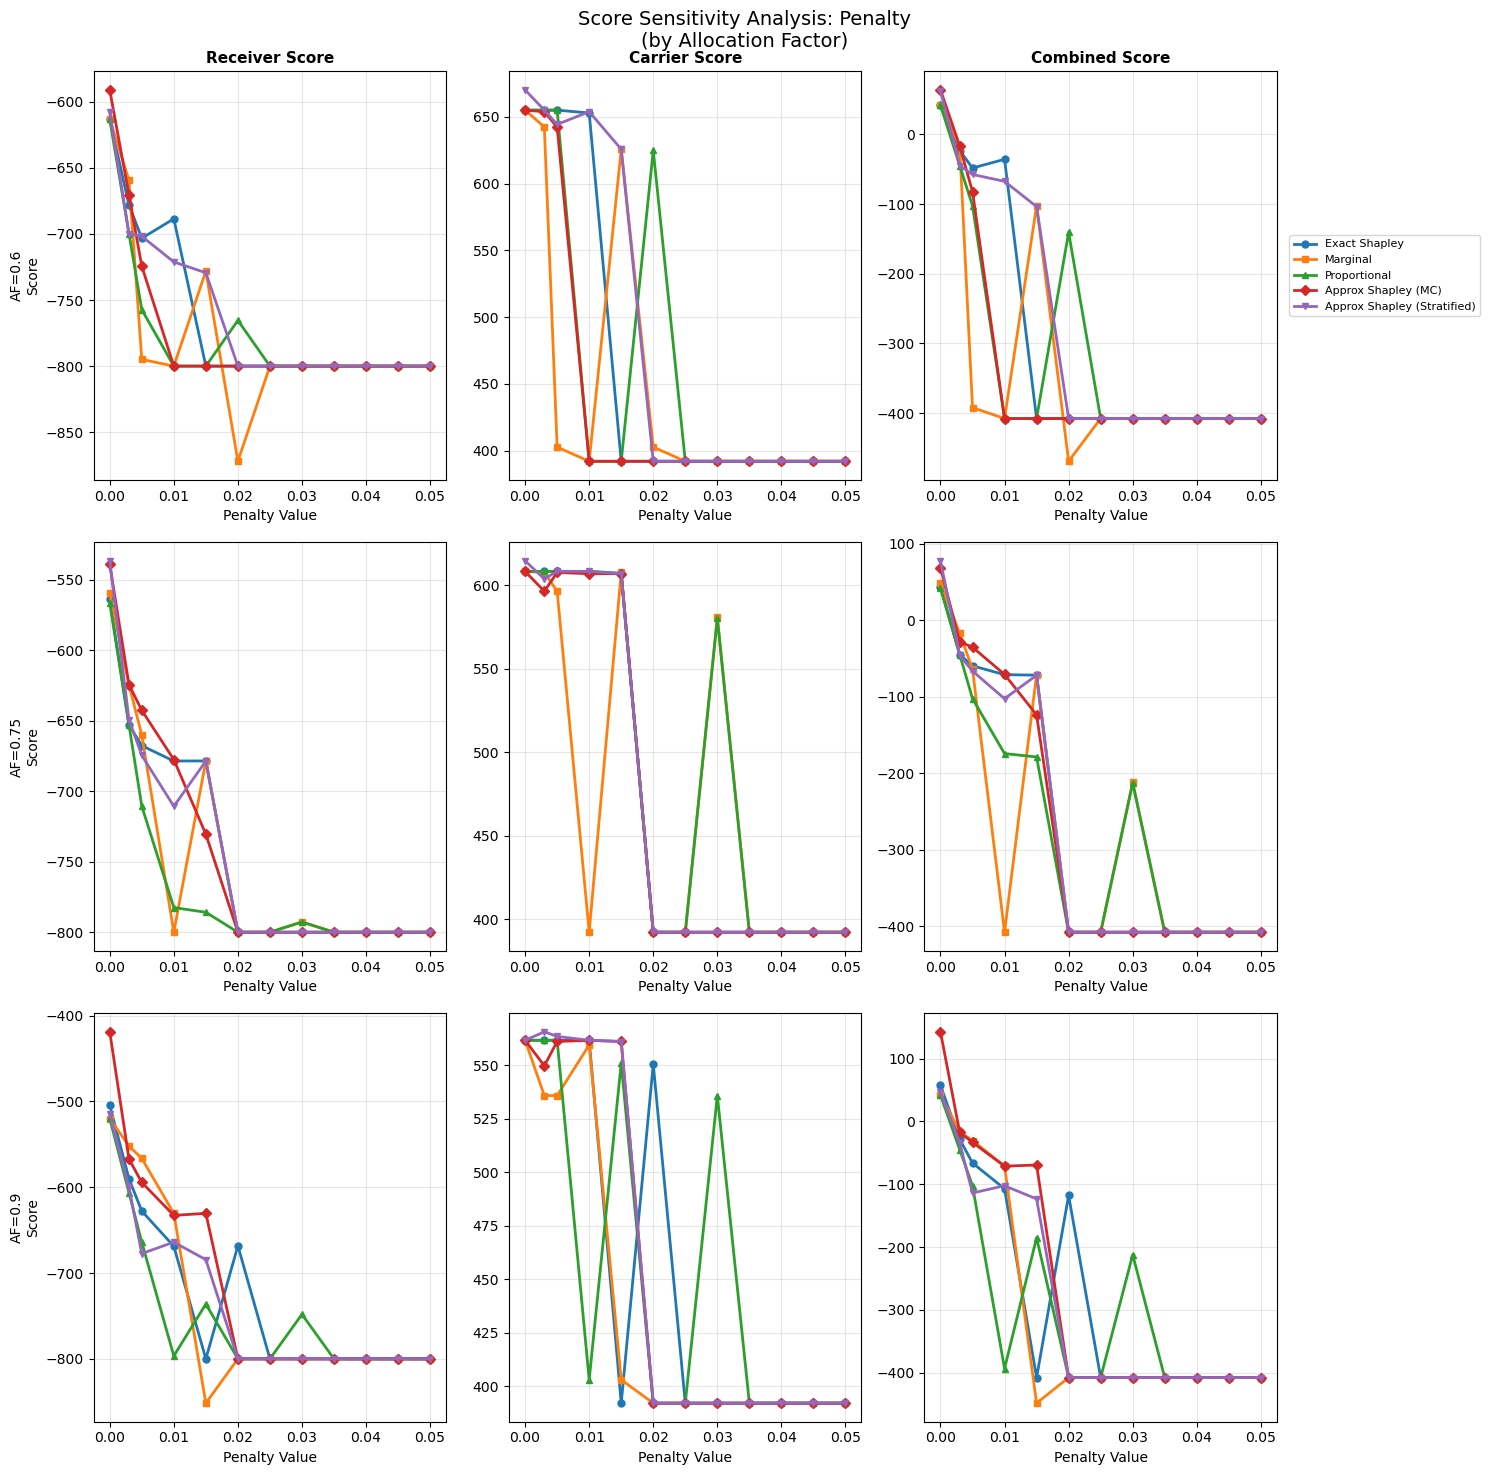

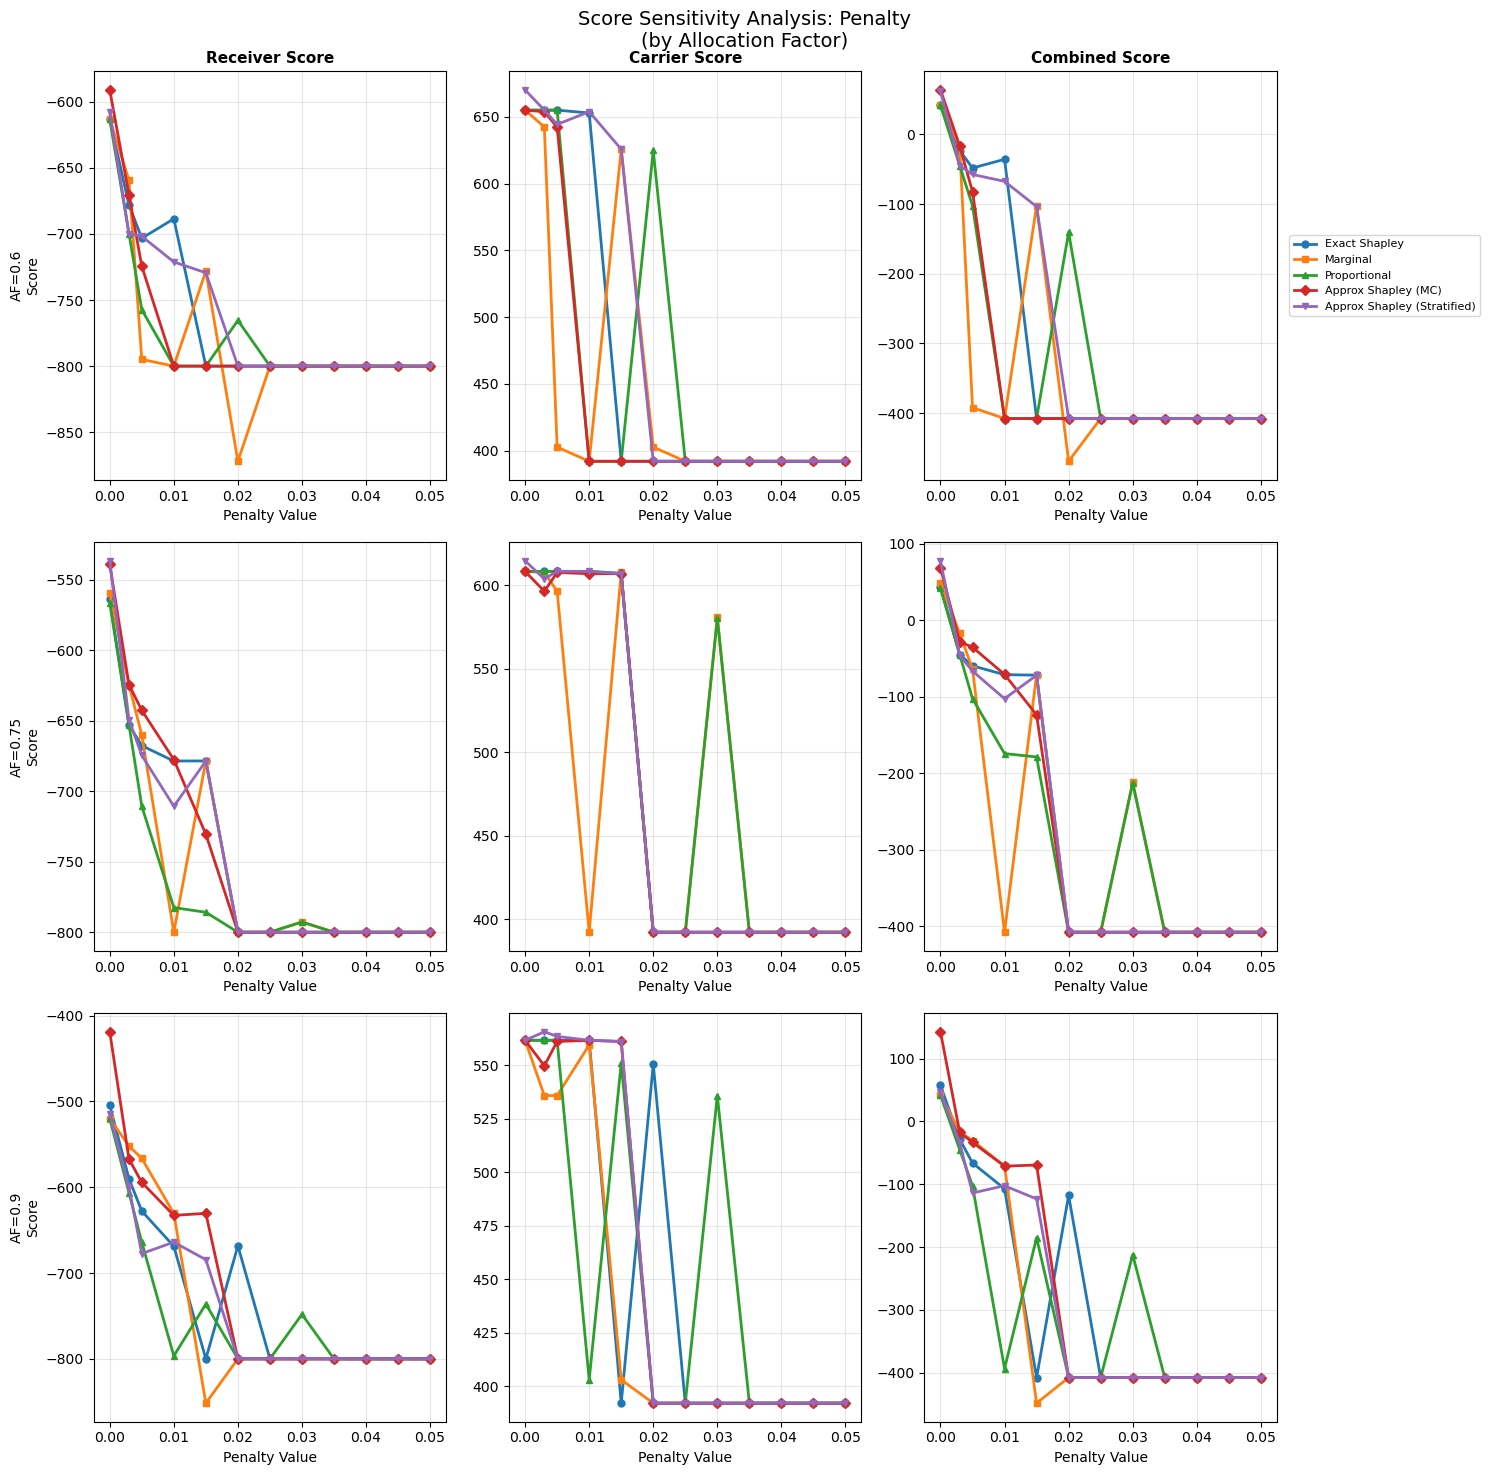

In [46]:
# Plot penalty sweep: Scores (receiver, carrier, combined) - All methods together per score type
plot_penalty_sweep_scores(pen_df, output_path=None)

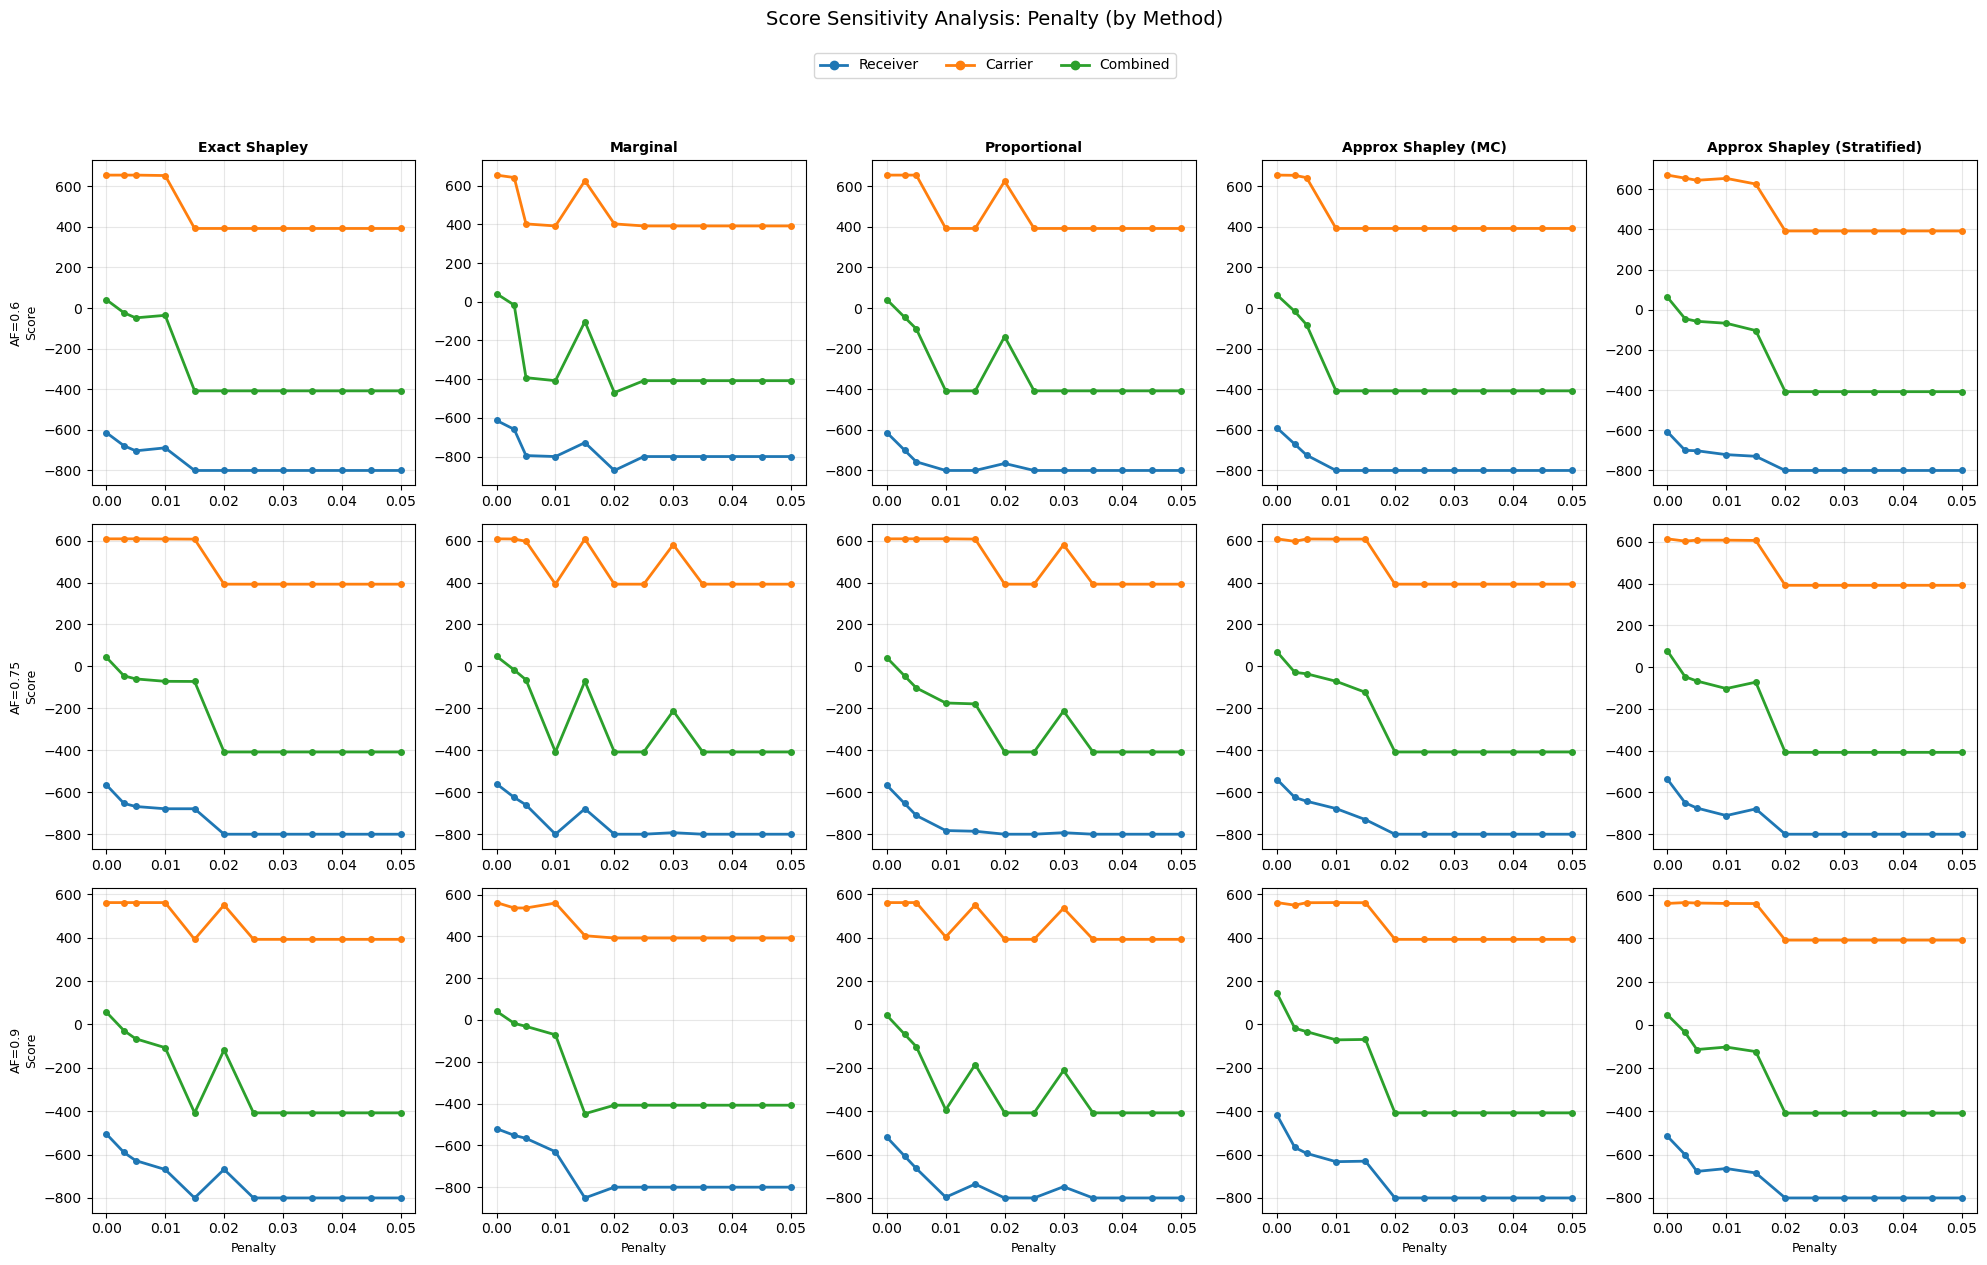

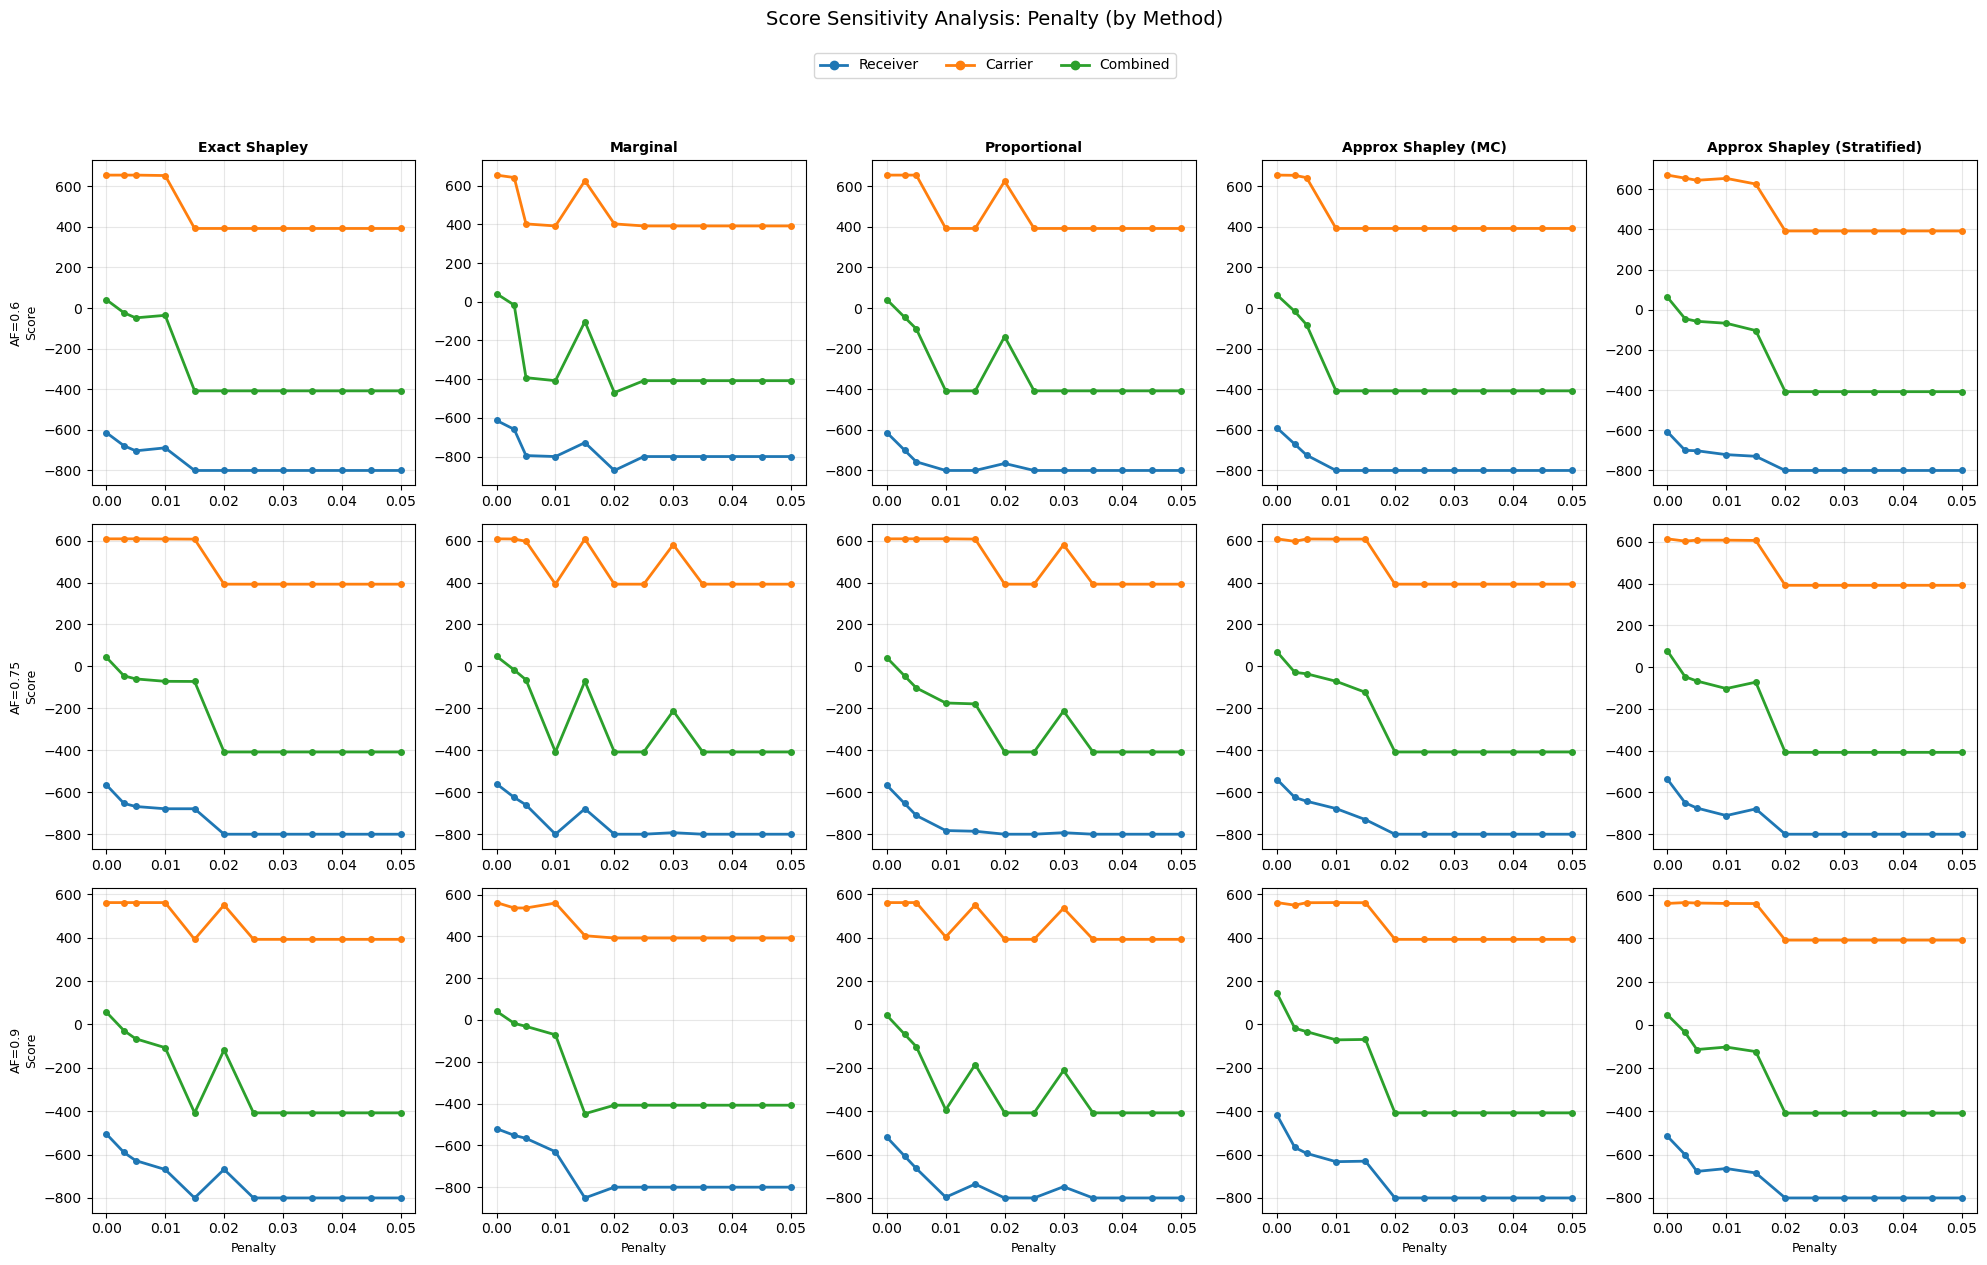

In [47]:
# Plot penalty sweep: Scores - Each method separate (grid of AF x Method)
plot_penalty_sweep_scores_separate(pen_df, output_path=None)

# Chessboard Carrier-Receiver Collaboration Analysis

This section analyzes the new chessboard scenarios with:
- Two depot locations: **center** and **left**
- Two sweep types: **allocSweep** and **penSweep**
- 5 run instances per scenario (i00-i04) to eliminate randomness
- Results are averaged across instances

In [10]:
# Chessboard output path
chessboard_output_path = r'output/chessboardCarrierReceiverCollab/'
if not os.path.exists(chessboard_output_path):
    raise Exception("Chessboard output path does not exist: " + chessboard_output_path)

# Get all folders
all_chessboard_folders = os.listdir(chessboard_output_path)
print(f"Total folders: {len(all_chessboard_folders)}")

# Separate by depot location and sweep type
center_alloc_folders = sorted([f for f in all_chessboard_folders if 'center' in f and 'allocSweep' in f ])
center_pen_folders = sorted([f for f in all_chessboard_folders if 'center' in f and 'penSweep' in f ])
left_alloc_folders = sorted([f for f in all_chessboard_folders if 'left' in f and 'allocSweep' in f ])
left_pen_folders = sorted([f for f in all_chessboard_folders if 'left' in f and 'penSweep' in f ])

print(f"Center allocSweep folders: {len(center_alloc_folders)}")
print(f"Center penSweep folders: {len(center_pen_folders)}")
print(f"Left allocSweep folders: {len(left_alloc_folders)}")
print(f"Left penSweep folders: {len(left_pen_folders)}")

Total folders: 2445
Center allocSweep folders: 0
Center penSweep folders: 1222
Left allocSweep folders: 0
Left penSweep folders: 1221


In [11]:
def parse_chessboard_folder_name(folder_name):
    """
    Parse chessboard folder name to extract depot location, customer_distribution_type, sweep type, allocation factor, penalty, method, and instance.
    Example: 'center-allocSweep-af0.40-p0.005-exactShapley-i00' -> ('center', 'allocSweep', 0.40, 0.005, 'exactShapley', 0)
    """
    parts = folder_name.split('-')
    depot = parts[0]  # 'center' or 'left'
    customer_distribution_type = parts[1]  # e.g., 'uniform' or other distribution types
    sweep_type = parts[2]  # 'allocSweep' or 'penSweep'
    af = float(parts[3].replace('af', ''))
    p = float(parts[4].replace('p', ''))
    method = parts[5]
    instance = int(parts[6].replace('i', ''))
    return depot, customer_distribution_type, sweep_type, af, p, method, instance


def collect_chessboard_sweep_data(folders, output_path, original_tw=(6, 8)):
    """
    Collect collaboration statistics from chessboard sweep folders.
    
    Returns:
    --------
    pandas.DataFrame with columns: folder, depot, customer_distribution_type, sweep_type, af, penalty, method, instance,
                                   count_collaborative, count_non_collaborative, total_receivers, 
                                   prop_collaborative, receiver_score, carrier_score, combined_score
    """
    data = []
    for folder in folders:
        try:
            depot, customer_distribution_type, sweep_type, af, penalty, method, instance = parse_chessboard_folder_name(folder)
        except Exception as e:
            print(f"Warning: Could not parse folder name '{folder}': {e}")
            continue
            
        folder_path = os.path.join(output_path, folder)
        receiver_file_path = os.path.join(folder_path, 'receivers.xml.gz')
        
        if os.path.exists(receiver_file_path):
            result = count_collaborative_receivers(receiver_file_path, original_tw)
            prop_collaborative = result['count_collaborative'] / result['total_receivers'] if result['total_receivers'] > 0 else 0
            
            # Get carrier score
            carrier_score = get_carrier_final_score(folder_path)
            combined_score = result['total_score'] + (carrier_score if carrier_score else 0)
            
            data.append({
                'folder': folder,
                'depot': depot,
                'customer_distribution_type': customer_distribution_type,
                'sweep_type': sweep_type,
                'af': af,
                'penalty': penalty,
                'method': method,
                'instance': instance,
                'count_collaborative': result['count_collaborative'],
                'count_non_collaborative': result['count_non_collaborative'],
                'total_receivers': result['total_receivers'],
                'prop_collaborative': prop_collaborative,
                'receiver_score': result['total_score'],
                'carrier_score': carrier_score,
                'combined_score': combined_score
            })
        else:
            print(f"Warning: File not found - {receiver_file_path}")
    
    return pd.DataFrame(data)


def aggregate_by_instance(df):
    """
    Aggregate data by averaging across instances.
    Groups by: depot, customer_distribution_type, sweep_type, af, penalty, method
    Calculates mean and std for: prop_collaborative, receiver_score, carrier_score, combined_score
    
    Note: prop_collaborative_mean is rounded to 1 decimal place (0.1 steps) since 
    the proportion is based on discrete receiver counts.
    """
    agg_df = df.groupby(['depot', 'customer_distribution_type', 'sweep_type', 'af', 'penalty', 'method']).agg({
        'count_collaborative': ['mean', 'std'],
        'count_non_collaborative': ['mean', 'std'],
        'total_receivers': 'mean',
        'prop_collaborative': ['mean', 'std'],
        'receiver_score': ['mean', 'std'],
        'carrier_score': ['mean', 'std'],
        'combined_score': ['mean', 'std'],
        'instance': 'count'  # Number of instances
    }).reset_index()
    
    # Flatten column names
    agg_df.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in agg_df.columns]
    agg_df.rename(columns={'instance_count': 'n_instances'}, inplace=True)
    
    # Round prop_collaborative_mean to 1 decimal place (0.1 steps)
    agg_df['prop_collaborative_mean'] = agg_df['prop_collaborative_mean'].round(1)
    
    return agg_df

In [12]:
# ============================================================================
# Plotting Functions for Chessboard Analysis (with error bars for std)
# ============================================================================

def plot_chessboard_alloc_sweep_comparison(agg_df, output_path=None):
    """
    Plot allocation factor sweep comparing center vs left depot.
    Two subplots side by side: left depot and center depot.
    Each subplot shows 5 lines (one per method) with error bars.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    depot_titles = {'left': 'Left Depot', 'center': 'Center Depot'}
    
    for idx, depot in enumerate(['left', 'center']):
        ax = axes[idx]
        depot_df = agg_df[agg_df['depot'] == depot]
        
        for method in ALLOCATION_METHODS:
            method_df = depot_df[depot_df['method'] == method].sort_values('af')
            if not method_df.empty:
                ax.errorbar(method_df['af'], method_df['prop_collaborative_mean'], 
                           yerr=method_df['prop_collaborative_std'],
                           marker=markers[method], color=colors[method], 
                           label=METHOD_LABELS[method], linewidth=2, markersize=8,
                           capsize=3, capthick=1)
        
        ax.set_xlabel('Allocation Factor', fontsize=12)
        ax.set_ylabel('Proportion of Collaborative Receivers', fontsize=12)
        ax.set_title(f'{depot_titles[depot]}', fontsize=14, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    
    fig.suptitle('Allocation Factor Sensitivity: Center vs Left Depot\n(Averaged over 5 instances, error bars show std)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_alloc_sweep_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_alloc_sweep_by_method(agg_df, output_path=None):
    """
    Plot allocation factor sweep: One subplot per method, comparing center vs left depot.
    Simple line plot without error bars or fill_between.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_depot = {'center': '#1f77b4', 'left': '#ff7f0e'}
    markers_depot = {'center': 'o', 'left': 's'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = agg_df[agg_df['method'] == method]
        
        for depot in ['center', 'left']:
            depot_method_df = method_df[method_df['depot'] == depot].sort_values('af')
            if not depot_method_df.empty:
                ax.plot(depot_method_df['af'], depot_method_df['prop_collaborative_mean'], 
                       marker=markers_depot[depot], color=colors_depot[depot], 
                       label=f'{depot.capitalize()} Depot', linewidth=2, markersize=6)
        
        ax.set_xlabel('Allocation Factor', fontsize=10)
        ax.set_ylabel('Prop. Collaborative', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    
    axes[-1].axis('off')
    
    fig.suptitle('Allocation Factor Sensitivity by Method: Center vs Left Depot\n(Averaged over 5 instances)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_alloc_sweep_by_method.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_alloc_sweep_scores(agg_df, output_path=None):
    """
    Plot allocation factor sweep for scores: comparing center vs left depot.
    3 columns (receiver, carrier, combined) x 2 rows (center, left)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    score_types = [('receiver_score', 'Receiver Score'), 
                   ('carrier_score', 'Carrier Score'), 
                   ('combined_score', 'Combined Score')]
    depot_titles = {'center': 'Center Depot', 'left': 'Left Depot'}
    
    for row_idx, depot in enumerate(['center', 'left']):
        depot_df = agg_df[agg_df['depot'] == depot]
        
        for col_idx, (score_col, score_label) in enumerate(score_types):
            ax = axes[row_idx, col_idx]
            
            for method in ALLOCATION_METHODS:
                method_df = depot_df[depot_df['method'] == method].sort_values('af')
                if not method_df.empty:
                    mean_col = f'{score_col}_mean'
                    std_col = f'{score_col}_std'
                    if mean_col in method_df.columns:
                        ax.errorbar(method_df['af'], method_df[mean_col], 
                                   yerr=method_df[std_col] if std_col in method_df.columns else None,
                                   marker=markers[method], color=colors[method], 
                                   label=METHOD_LABELS[method], linewidth=2, markersize=5,
                                   capsize=2, capthick=1)
            
            ax.set_xlabel('Allocation Factor', fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(f'{depot_titles[depot]}\nScore', fontsize=10)
            if row_idx == 0:
                ax.set_title(f'{score_label}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if row_idx == 0 and col_idx == 2:
                ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    
    fig.suptitle('Score Sensitivity: Allocation Factor (Center vs Left Depot)\n(Averaged over 5 instances)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_alloc_sweep_scores.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

In [13]:
# ============================================================================
# Penalty Sweep Plotting Functions for Chessboard Analysis
# ============================================================================

def plot_chessboard_pen_sweep_comparison(agg_df, output_path=None):
    """
    Plot penalty sweep comparing center vs left depot.
    Two subplots side by side: left depot and center depot.
    Each subplot shows 5 lines (one per method) with error bars.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    depot_titles = {'left': 'Left Depot', 'center': 'Center Depot'}
    
    for idx, depot in enumerate(['left', 'center']):
        ax = axes[idx]
        depot_df = agg_df[agg_df['depot'] == depot]
        
        for method in ALLOCATION_METHODS:
            method_df = depot_df[depot_df['method'] == method].sort_values('penalty')
            if not method_df.empty:
                ax.errorbar(method_df['penalty'], method_df['prop_collaborative_mean'], 
                           yerr=method_df['prop_collaborative_std'],
                           marker=markers[method], color=colors[method], 
                           label=METHOD_LABELS[method], linewidth=2, markersize=8,
                           capsize=3, capthick=1)
        
        ax.set_xlabel('Penalty Value (per second)', fontsize=12)
        ax.set_ylabel('Proportion of Collaborative Receivers', fontsize=12)
        ax.set_title(f'{depot_titles[depot]}', fontsize=14, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    
    fig.suptitle('Penalty Sensitivity: Center vs Left Depot\n(Averaged over 5 instances, error bars show std)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_pen_sweep_comparison.png'), dpi=150, bbox_inches='tight')
    # plt.show()
    # return fig


def plot_chessboard_pen_sweep_by_method(agg_df, output_path=None):
    """
    Plot penalty sweep: One subplot per method, comparing center vs left depot.
    Simple line plot without error bars or fill_between.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_depot = {'center': '#1f77b4', 'left': '#ff7f0e'}
    markers_depot = {'center': 'o', 'left': 's'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = agg_df[agg_df['method'] == method]
        
        for depot in ['center', 'left']:
            depot_method_df = method_df[method_df['depot'] == depot].sort_values('penalty')
            if not depot_method_df.empty:
                ax.plot(depot_method_df['penalty'], depot_method_df['prop_collaborative_mean'], 
                       marker=markers_depot[depot], color=colors_depot[depot], 
                       label=f'{depot.capitalize()} Depot', linewidth=2, markersize=6)
        
        ax.set_xlabel('Penalty Value', fontsize=10)
        ax.set_ylabel('Prop. Collaborative', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    
    axes[-1].axis('off')
    
    fig.suptitle('Penalty Sensitivity by Method: Center vs Left Depot\n(Averaged over 5 instances)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_pen_sweep_by_method.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_pen_sweep_scores(agg_df, output_path=None):
    """
    Plot penalty sweep for scores: comparing center vs left depot.
    3 columns (receiver, carrier, combined) x 2 rows (center, left)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    score_types = [('receiver_score', 'Receiver Score'), 
                   ('carrier_score', 'Carrier Score'), 
                   ('combined_score', 'Combined Score')]
    depot_titles = {'center': 'Center Depot', 'left': 'Left Depot'}
    
    for row_idx, depot in enumerate(['center', 'left']):
        depot_df = agg_df[agg_df['depot'] == depot]
        
        for col_idx, (score_col, score_label) in enumerate(score_types):
            ax = axes[row_idx, col_idx]
            
            for method in ALLOCATION_METHODS:
                method_df = depot_df[depot_df['method'] == method].sort_values('penalty')
                if not method_df.empty:
                    mean_col = f'{score_col}_mean'
                    std_col = f'{score_col}_std'
                    if mean_col in method_df.columns:
                        ax.errorbar(method_df['penalty'], method_df[mean_col], 
                                   yerr=method_df[std_col] if std_col in method_df.columns else None,
                                   marker=markers[method], color=colors[method], 
                                   label=METHOD_LABELS[method], linewidth=2, markersize=5,
                                   capsize=2, capthick=1)
            
            ax.set_xlabel('Penalty Value', fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(f'{depot_titles[depot]}\nScore', fontsize=10)
            if row_idx == 0:
                ax.set_title(f'{score_label}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if row_idx == 0 and col_idx == 2:
                ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    
    fig.suptitle('Score Sensitivity: Penalty (Center vs Left Depot)\n(Averaged over 5 instances)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_pen_sweep_scores.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

In [14]:
# ============================================================================
# Comprehensive Comparison Plots (Center vs Left in same plot)
# ============================================================================

def plot_chessboard_alloc_comprehensive(agg_df, output_path=None):
    """
    Comprehensive plot: 5 subplots (one per method), each showing center vs left depot
    for allocation factor sweep. Uses different line styles for depot distinction.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    linestyles = {'center': '-', 'left': '--'}
    markers = {'center': 'o', 'left': 's'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = agg_df[agg_df['method'] == method]
        
        for depot in ['center', 'left']:
            depot_df = method_df[method_df['depot'] == depot].sort_values('af')
            if not depot_df.empty:
                ax.errorbar(depot_df['af'], depot_df['prop_collaborative_mean'], 
                           yerr=depot_df['prop_collaborative_std'],
                           marker=markers[depot], color=colors[method],
                           linestyle=linestyles[depot],
                           label=f'{depot.capitalize()}', linewidth=2, markersize=7,
                           capsize=3, capthick=1)
        
        ax.set_xlabel('Allocation Factor', fontsize=11)
        ax.set_ylabel('Prop. Collaborative', fontsize=11)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=12, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10)
    
    # Add legend explanation in the empty subplot
    ax_legend = axes[-1]
    ax_legend.axis('off')
    ax_legend.text(0.5, 0.7, 'Legend', fontsize=14, fontweight='bold', ha='center', transform=ax_legend.transAxes)
    ax_legend.text(0.5, 0.5, '— Solid line: Center Depot\n--- Dashed line: Left Depot', 
                   fontsize=11, ha='center', va='center', transform=ax_legend.transAxes)
    ax_legend.text(0.5, 0.25, 'Error bars: Standard deviation\nacross 5 instances', 
                   fontsize=10, ha='center', va='center', transform=ax_legend.transAxes, style='italic')
    
    fig.suptitle('Allocation Factor Sensitivity Analysis\nComparing Center vs Left Depot Location', fontsize=15)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_alloc_comprehensive.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_pen_comprehensive(agg_df, output_path=None):
    """
    Comprehensive plot: 5 subplots (one per method), each showing center vs left depot
    for penalty sweep. Uses different line styles for depot distinction.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    linestyles = {'center': '-', 'left': '--'}
    markers = {'center': 'o', 'left': 's'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = agg_df[agg_df['method'] == method]
        
        for depot in ['center', 'left']:
            depot_df = method_df[method_df['depot'] == depot].sort_values('penalty')
            if not depot_df.empty:
                ax.errorbar(depot_df['penalty'], depot_df['prop_collaborative_mean'], 
                           yerr=depot_df['prop_collaborative_std'],
                           marker=markers[depot], color=colors[method],
                           linestyle=linestyles[depot],
                           label=f'{depot.capitalize()}', linewidth=2, markersize=7,
                           capsize=3, capthick=1)
        
        ax.set_xlabel('Penalty Value (per second)', fontsize=11)
        ax.set_ylabel('Prop. Collaborative', fontsize=11)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=12, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10)
    
    # Add legend explanation in the empty subplot
    ax_legend = axes[-1]
    ax_legend.axis('off')
    ax_legend.text(0.5, 0.7, 'Legend', fontsize=14, fontweight='bold', ha='center', transform=ax_legend.transAxes)
    ax_legend.text(0.5, 0.5, '— Solid line: Center Depot\n--- Dashed line: Left Depot', 
                   fontsize=11, ha='center', va='center', transform=ax_legend.transAxes)
    ax_legend.text(0.5, 0.25, 'Error bars: Standard deviation\nacross 5 instances', 
                   fontsize=10, ha='center', va='center', transform=ax_legend.transAxes, style='italic')
    
    fig.suptitle('Penalty Sensitivity Analysis\nComparing Center vs Left Depot Location', fontsize=15)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'chessboard_pen_comprehensive.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_scores_comprehensive(raw_df, sweep_type='alloc', output_path=None):
    """
    Box plot for scores: 2 rows (carrier, receiver) x 5 columns (methods)
    Each subplot shows box plots for each x point (allocation factor or penalty),
    with separate boxes for center and left depot.
    Uses raw_df (not aggregated) to show distribution across instances.
    """
    score_types = [('carrier_score', 'Carrier Score'), 
                   ('receiver_score', 'Receiver Score')]
    
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    
    colors_depot = {'center': '#1f77b4', 'left': '#ff7f0e'}
    
    x_col = 'af' if sweep_type == 'alloc' else 'penalty'
    x_label = 'Allocation Factor' if sweep_type == 'alloc' else 'Penalty Value'
    
    # Filter by sweep type
    sweep_filter = 'allocSweep' if sweep_type == 'alloc' else 'penSweep'
    df = raw_df[raw_df['sweep_type'] == sweep_filter].copy()
    
    for row_idx, (score_col, score_label) in enumerate(score_types):
        for col_idx, method in enumerate(ALLOCATION_METHODS):
            ax = axes[row_idx, col_idx]
            method_df = df[df['method'] == method].copy()
            
            if method_df.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                continue
            
            # Get unique x values and sort them
            x_values = sorted(method_df[x_col].unique())
            positions = []
            box_data_center = []
            box_data_left = []
            
            for i, x_val in enumerate(x_values):
                x_data = method_df[method_df[x_col] == x_val]
                
                center_scores = x_data[x_data['depot'] == 'center'][score_col].dropna().values
                left_scores = x_data[x_data['depot'] == 'left'][score_col].dropna().values
                
                box_data_center.append(center_scores if len(center_scores) > 0 else [np.nan])
                box_data_left.append(left_scores if len(left_scores) > 0 else [np.nan])
                positions.append(i)
            
            # Plot box plots - offset for center and left
            width = 0.35
            positions_center = [p - width/2 for p in positions]
            positions_left = [p + width/2 for p in positions]
            
            # Center depot boxes
            bp_center = ax.boxplot(box_data_center, positions=positions_center, widths=width*0.8,
                                   patch_artist=True, manage_ticks=False)
            for patch in bp_center['boxes']:
                patch.set_facecolor(colors_depot['center'])
                patch.set_alpha(0.7)
            for element in ['whiskers', 'caps', 'medians']:
                for item in bp_center[element]:
                    item.set_color(colors_depot['center'])
            
            # Left depot boxes
            bp_left = ax.boxplot(box_data_left, positions=positions_left, widths=width*0.8,
                                 patch_artist=True, manage_ticks=False)
            for patch in bp_left['boxes']:
                patch.set_facecolor(colors_depot['left'])
                patch.set_alpha(0.7)
            for element in ['whiskers', 'caps', 'medians']:
                for item in bp_left[element]:
                    item.set_color(colors_depot['left'])
            
            # Set x-axis ticks and labels
            ax.set_xticks(positions)
            ax.set_xticklabels([f'{v:.2f}' if sweep_type == 'alloc' else f'{v:.3f}' for v in x_values], 
                              fontsize=7, rotation=45)
            
            if row_idx == 1:
                ax.set_xlabel(x_label, fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(score_label, fontsize=9)
            if row_idx == 0:
                ax.set_title(f'{METHOD_LABELS[method]}', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            ax.tick_params(axis='both', labelsize=8)
            
            # Add legend only once
            if row_idx == 0 and col_idx == 4:
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor=colors_depot['center'], alpha=0.7, label='Center'),
                                   Patch(facecolor=colors_depot['left'], alpha=0.7, label='Left')]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    sweep_title = 'Allocation Factor' if sweep_type == 'alloc' else 'Penalty'
    fig.suptitle(f'Score Distribution: {sweep_title} Sweep\nComparing Center vs Left Depot (5 instances)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        filename = f'chessboard_{sweep_type}_scores_boxplot.png'
        plt.savefig(os.path.join(output_path, filename), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

In [15]:
# ============================================================================
# Single Instance Analysis Functions
# ============================================================================

def plot_chessboard_alloc_sweep_by_method_single_instance(raw_df, instance='i00', output_path=None):
    """
    Plot allocation factor sweep for a single instance: One subplot per method, comparing center vs left depot.
    Simple line plot without averaging across instances.
    
    Parameters:
    -----------
    raw_df : DataFrame
        Raw data with individual instance records
    instance : str
        Instance to analyze, e.g., 'i00', 'i01', 'i02', 'i03', 'i04'
    output_path : str, optional
        Path to save the figure
    """
    # Filter data for allocSweep and specified instance
    df = raw_df[(raw_df['sweep_type'] == 'allocSweep') & (raw_df['instance'] == instance)].copy()
    
    if df.empty:
        print(f"No data found for instance '{instance}' in allocSweep")
        return None
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_depot = {'center': '#1f77b4', 'left': '#ff7f0e'}
    markers_depot = {'center': 'o', 'left': 's'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = df[df['method'] == method]
        
        for depot in ['center', 'left']:
            depot_method_df = method_df[method_df['depot'] == depot].sort_values('af')
            if not depot_method_df.empty:
                ax.plot(depot_method_df['af'], depot_method_df['prop_collaborative'], 
                       marker=markers_depot[depot], color=colors_depot[depot], 
                       label=f'{depot.capitalize()} Depot', linewidth=2, markersize=6)
        
        ax.set_xlabel('Allocation Factor', fontsize=10)
        ax.set_ylabel('Prop. Collaborative', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    
    axes[-1].axis('off')
    
    fig.suptitle(f'Allocation Factor Sensitivity by Method: Center vs Left Depot\n(Instance: {instance})', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, f'chessboard_alloc_sweep_by_method_{instance}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_pen_sweep_by_method_single_instance(raw_df, instance='i00', output_path=None):
    """
    Plot penalty sweep for a single instance: One subplot per method, comparing center vs left depot.
    Simple line plot without averaging across instances.
    
    Parameters:
    -----------
    raw_df : DataFrame
        Raw data with individual instance records
    instance : str
        Instance to analyze, e.g., 'i00', 'i01', 'i02', 'i03', 'i04'
    output_path : str, optional
        Path to save the figure
    """
    # Filter data for penSweep and specified instance
    df = raw_df[(raw_df['sweep_type'] == 'penSweep') & (raw_df['instance'] == instance)].copy()
    
    if df.empty:
        print(f"No data found for instance '{instance}' in penSweep")
        return None
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_depot = {'center': '#1f77b4', 'left': '#ff7f0e'}
    markers_depot = {'center': 'o', 'left': 's'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = df[df['method'] == method]
        
        for depot in ['center', 'left']:
            depot_method_df = method_df[method_df['depot'] == depot].sort_values('penalty')
            if not depot_method_df.empty:
                ax.plot(depot_method_df['penalty'], depot_method_df['prop_collaborative'], 
                       marker=markers_depot[depot], color=colors_depot[depot], 
                       label=f'{depot.capitalize()} Depot', linewidth=2, markersize=6)
        
        ax.set_xlabel('Penalty Value', fontsize=10)
        ax.set_ylabel('Prop. Collaborative', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    
    axes[-1].axis('off')
    
    fig.suptitle(f'Penalty Sensitivity by Method: Center vs Left Depot\n(Instance: {instance})', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, f'chessboard_pen_sweep_by_method_{instance}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_chessboard_scores_lineplot_single_instance(raw_df, sweep_type='alloc', instance='i00', output_path=None):
    """
    Line plot for scores for a single instance: 2 rows (carrier, receiver) x 5 columns (methods)
    Each subplot compares center vs left depot using line plots.
    
    Parameters:
    -----------
    raw_df : DataFrame
        Raw data with individual instance records
    sweep_type : str
        'alloc' for allocation factor sweep, 'pen' for penalty sweep
    instance : str
        Instance to analyze, e.g., 'i00', 'i01', 'i02', 'i03', 'i04'
    output_path : str, optional
        Path to save the figure
    """
    score_types = [('carrier_score', 'Carrier Score'), 
                   ('receiver_score', 'Receiver Score')]
    
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    
    linestyles = {'center': '-', 'left': '--'}
    markers = {'center': 'o', 'left': 's'}
    colors_depot = {'center': '#1f77b4', 'left': '#ff7f0e'}
    
    x_col = 'af' if sweep_type == 'alloc' else 'penalty'
    x_label = 'Allocation Factor' if sweep_type == 'alloc' else 'Penalty Value'
    
    # Filter by sweep type and instance
    sweep_filter = 'allocSweep' if sweep_type == 'alloc' else 'penSweep'
    df = raw_df[(raw_df['sweep_type'] == sweep_filter) & (raw_df['instance'] == instance)].copy()
    
    if df.empty:
        print(f"No data found for instance '{instance}' in {sweep_filter}")
        return None
    
    for row_idx, (score_col, score_label) in enumerate(score_types):
        for col_idx, method in enumerate(ALLOCATION_METHODS):
            ax = axes[row_idx, col_idx]
            method_df = df[df['method'] == method]
            
            for depot in ['center', 'left']:
                depot_df = method_df[method_df['depot'] == depot].sort_values(x_col)
                if not depot_df.empty:
                    ax.plot(depot_df[x_col], depot_df[score_col], 
                           marker=markers[depot], color=colors_depot[depot],
                           linestyle=linestyles[depot],
                           label=f'{depot.capitalize()}' if row_idx == 0 else None, 
                           linewidth=1.5, markersize=5)
            
            if row_idx == 1:
                ax.set_xlabel(x_label, fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(score_label, fontsize=9)
            if row_idx == 0:
                ax.set_title(f'{METHOD_LABELS[method]}', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=8)
            
            if row_idx == 0 and col_idx == 4:
                ax.legend(loc='upper right', fontsize=8)
    
    sweep_title = 'Allocation Factor' if sweep_type == 'alloc' else 'Penalty'
    fig.suptitle(f'Score Analysis: {sweep_title} Sweep\nComparing Center vs Left Depot (Instance: {instance})', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        filename = f'chessboard_{sweep_type}_scores_lineplot_{instance}.png'
        plt.savefig(os.path.join(output_path, filename), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

## Run Chessboard Analysis

In [16]:
# Collect all chessboard data
print("Collecting data from all chessboard folders...")
all_chessboard_folders = os.listdir(chessboard_output_path)
# Filter out hidden files and non-folder items
all_chessboard_folders = [f for f in all_chessboard_folders if not f.startswith('.')]

chessboard_raw_df = collect_chessboard_sweep_data(all_chessboard_folders, chessboard_output_path)
print(f"\nCollected {len(chessboard_raw_df)} records total")
print(f"Depots: {chessboard_raw_df['depot'].unique().tolist()}")
print(f"Sweep types: {chessboard_raw_df['sweep_type'].unique().tolist()}")
print(f"Allocation factors: {sorted(chessboard_raw_df['af'].unique())}")
print(f"Penalty values: {sorted(chessboard_raw_df['penalty'].unique())}")
print(f"Methods: {chessboard_raw_df['method'].unique().tolist()}")
print(f"Instances: {sorted(chessboard_raw_df['instance'].unique())}")

chessboard_raw_df.head(10)


Collected 2443 records total
Depots: ['center', 'left']
Sweep types: ['penSweep']
Allocation factors: [np.float64(0.8)]
Penalty values: [np.float64(0.0), np.float64(0.0003), np.float64(0.0006), np.float64(0.0008), np.float64(0.0014), np.float64(0.0028), np.float64(0.0056), np.float64(0.0098), np.float64(0.014), np.float64(0.0167), np.float64(0.0222), np.float64(0.028)]
Methods: ['exactShapley']
Instances: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42

,folder,depot,customer_distribution_type,sweep_type,af,penalty,method,instance,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,center-CLUSTERED-penSweep-af0.80-p0.0003-exact...,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,23,6,4,10,0.6,-686.218115,688.000174,1.782059
1,left-CLUSTERED-penSweep-af0.80-p0.0222-exactSh...,left,CLUSTERED,penSweep,0.8,0.0222,exactShapley,3,0,10,10,0.0,-1000.000000,562.376000,-437.624000
2,left-DISPERSED-penSweep-af0.80-p0.0003-exactSh...,left,DISPERSED,penSweep,0.8,0.0003,exactShapley,27,7,3,10,0.7,-852.591046,537.253489,-315.337558
3,center-DISPERSED-penSweep-af0.80-p0.0222-exact...,center,DISPERSED,penSweep,0.8,0.0222,exactShapley,7,0,10,10,0.0,-1000.000000,557.016000,-442.984000
4,center-CLUSTERED-penSweep-af0.80-p0.0098-exact...,center,CLUSTERED,penSweep,0.8,0.0098,exactShapley,4,1,9,10,0.1,-936.749815,612.737099,-324.012717
5,center-CLUSTERED-penSweep-af0.80-p0.0008-exact...,center,CLUSTERED,penSweep,0.8,0.0008,exactShapley,25,0,10,10,0.0,-1000.000000,592.315000,-407.685000
6,left-CLUSTERED-penSweep-af0.80-p0.0167-exactSh...,left,CLUSTERED,penSweep,0.8,0.0167,exactShapley,26,0,10,10,0.0,-1000.000000,521.595000,-478.405000
7,left-CLUSTERED-penSweep-af0.80-p0.0014-exactSh...,left,CLUSTERED,penSweep,0.8,0.0014,exactShapley,5,0,10,10,0.0,-1000.000000,527.477000,-472.523000
8,left-DISPERSED-penSweep-af0.80-p0.0098-exactSh...,left,DISPERSED,penSweep,0.8,0.0098,exactShapley,0,0,10,10,0.0,-1000.000000,519.761000,-480.239000
9,left-DISPERSED-penSweep-af0.80-p0.0008-exactSh...,left,DISPERSED,penSweep,0.8,0.0008,exactShapley,21,4,6,10,0.4,-930.125819,574.689197,-355.436621


In [17]:
chessboard_raw_df

,folder,depot,customer_distribution_type,sweep_type,af,penalty,method,instance,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,center-CLUSTERED-penSweep-af0.80-p0.0003-exact...,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,23,6,4,10,0.6,-686.218115,688.000174,1.782059
1,left-CLUSTERED-penSweep-af0.80-p0.0222-exactSh...,left,CLUSTERED,penSweep,0.8,0.0222,exactShapley,3,0,10,10,0.0,-1000.000000,562.376000,-437.624000
2,left-DISPERSED-penSweep-af0.80-p0.0003-exactSh...,left,DISPERSED,penSweep,0.8,0.0003,exactShapley,27,7,3,10,0.7,-852.591046,537.253489,-315.337558
3,center-DISPERSED-penSweep-af0.80-p0.0222-exact...,center,DISPERSED,penSweep,0.8,0.0222,exactShapley,7,0,10,10,0.0,-1000.000000,557.016000,-442.984000
4,center-CLUSTERED-penSweep-af0.80-p0.0098-exact...,center,CLUSTERED,penSweep,0.8,0.0098,exactShapley,4,1,9,10,0.1,-936.749815,612.737099,-324.012717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438,left-CLUSTERED-penSweep-af0.80-p0.0028-exactSh...,left,CLUSTERED,penSweep,0.8,0.0028,exactShapley,43,1,9,10,0.1,-999.834222,546.137128,-453.697094
2439,left-DISPERSED-penSweep-af0.80-p0.0056-exactSh...,left,DISPERSED,penSweep,0.8,0.0056,exactShapley,14,2,8,10,0.2,-883.866050,565.470543,-318.395507
2440,center-CLUSTERED-penSweep-af0.80-p0.0140-exact...,center,CLUSTERED,penSweep,0.8,0.0140,exactShapley,5,0,10,10,0.0,-1000.000000,581.017000,-418.983000
2441,center-FULLY_RANDOM-penSweep-af0.80-p0.0028-ex...,center,FULLY_RANDOM,penSweep,0.8,0.0028,exactShapley,0,2,8,10,0.2,-940.390845,582.833740,-357.557104


In [25]:
# Only retain the instance 0 rows
chessboard_raw_df = chessboard_raw_df[chessboard_raw_df['instance'] == 0].copy()
chessboard_raw_df

,folder,depot,customer_distribution_type,sweep_type,af,penalty,method,instance,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,left-CLUSTERED-penSweep-af0.80-p0.0028-exactSh...,left,CLUSTERED,penSweep,0.8,0.0028,exactShapley,0,0,10,10,0.0,-1000.000000,509.830000,-490.170000
1,center-DISPERSED-penSweep-af0.80-p0.0280-exact...,center,DISPERSED,penSweep,0.8,0.0280,exactShapley,0,0,10,10,0.0,-1000.000000,557.397000,-442.603000
2,center-DISPERSED-penSweep-af0.80-p0.0000-exact...,center,DISPERSED,penSweep,0.8,0.0000,exactShapley,0,9,1,10,0.9,-638.455051,753.075475,114.620424
3,center-CLUSTERED-penSweep-af0.80-p0.0056-exact...,center,CLUSTERED,penSweep,0.8,0.0056,exactShapley,0,1,9,10,0.1,-886.706994,630.544887,-256.162107
4,center-DISPERSED-penSweep-af0.80-p0.0014-exact...,center,DISPERSED,penSweep,0.8,0.0014,exactShapley,0,4,6,10,0.4,-941.416809,590.857905,-350.558905
5,center-CLUSTERED-penSweep-af0.80-p0.0006-exact...,center,CLUSTERED,penSweep,0.8,0.0006,exactShapley,0,1,9,10,0.1,-891.305016,628.101430,-263.203587
6,left-CLUSTERED-penSweep-af0.80-p0.0006-exactSh...,left,CLUSTERED,penSweep,0.8,0.0006,exactShapley,0,1,9,10,0.1,-878.097532,548.186023,-329.911509
7,left-DISPERSED-penSweep-af0.80-p0.0014-exactSh...,left,DISPERSED,penSweep,0.8,0.0014,exactShapley,0,3,7,10,0.3,-955.659138,533.021755,-422.637383
8,left-CLUSTERED-penSweep-af0.80-p0.0056-exactSh...,left,CLUSTERED,penSweep,0.8,0.0056,exactShapley,0,1,9,10,0.1,-921.484452,553.314259,-368.170193
9,left-DISPERSED-penSweep-af0.80-p0.0000-exactSh...,left,DISPERSED,penSweep,0.8,0.0000,exactShapley,0,8,2,10,0.8,-684.168907,682.841951,-1.326956


In [18]:
# Aggregate data by averaging across instances
print("Aggregating data across instances...")
chessboard_agg_df = aggregate_by_instance(chessboard_raw_df)
print(f"Aggregated to {len(chessboard_agg_df)} unique scenario configurations")
print(f"\nSample of aggregated data:")
chessboard_agg_df.head(10)

Aggregating data across instances...
Aggregated to 71 unique scenario configurations

Sample of aggregated data:


,depot,customer_distribution_type,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
0,center,CLUSTERED,penSweep,0.8,0.0000,exactShapley,7.84,1.788398,2.16,1.788398,10.0,0.8,0.178840,-833.963818,143.701712,692.022888,75.193515,-141.940930,195.851061,50
1,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,2.94,2.637330,7.06,2.637330,10.0,0.3,0.263733,-894.718865,107.149853,617.029507,47.740522,-277.689357,143.052180,50
2,center,CLUSTERED,penSweep,0.8,0.0006,exactShapley,2.40,1.955050,7.60,1.955050,10.0,0.2,0.195505,-924.253196,50.855810,610.041036,24.736901,-314.212160,70.056943,10
3,center,CLUSTERED,penSweep,0.8,0.0008,exactShapley,1.76,1.802040,8.24,1.802040,10.0,0.2,0.180204,-933.173290,81.660152,610.826268,39.744969,-322.347022,114.527745,50
4,center,CLUSTERED,penSweep,0.8,0.0014,exactShapley,1.14,1.178203,8.86,1.178203,10.0,0.1,0.117820,-926.942008,85.424325,604.131081,23.812487,-322.810927,101.549382,50
5,center,CLUSTERED,penSweep,0.8,0.0028,exactShapley,0.94,0.912722,9.06,0.912722,10.0,0.1,0.091272,-939.338326,79.531800,605.035683,26.741045,-334.302643,94.790505,50
6,center,CLUSTERED,penSweep,0.8,0.0056,exactShapley,0.64,0.920514,9.36,0.920514,10.0,0.1,0.092051,-948.791510,67.527638,601.461917,20.980309,-347.329594,80.017297,50
7,center,CLUSTERED,penSweep,0.8,0.0098,exactShapley,0.34,0.519419,9.66,0.519419,10.0,0.0,0.051942,-962.913584,65.170277,599.844704,24.212329,-363.068880,83.664076,50
8,center,CLUSTERED,penSweep,0.8,0.0140,exactShapley,0.32,0.620730,9.68,0.620730,10.0,0.0,0.062073,-971.253345,55.317018,596.956114,22.093786,-374.297232,67.853347,50
9,center,CLUSTERED,penSweep,0.8,0.0167,exactShapley,0.18,0.437526,9.82,0.437526,10.0,0.0,0.043753,-974.184432,61.718171,596.660734,25.699723,-377.523699,80.413517,50


In [38]:
chessboard_agg_df

,depot,customer_distribution_type,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
0,center,CLUSTERED,penSweep,0.8,0.0000,exactShapley,8.5,1.080123,1.5,1.080123,10.0,0.8,0.108012,-733.045243,114.982136,741.795880,44.388532,8.750637,143.203530,10
1,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,2.6,2.270585,7.4,2.270585,10.0,0.3,0.227058,-904.705567,91.128204,608.477802,22.492066,-296.227765,111.199655,10
2,center,CLUSTERED,penSweep,0.8,0.0006,exactShapley,2.4,1.955050,7.6,1.955050,10.0,0.2,0.195505,-924.253196,50.855810,610.041036,24.736901,-314.212160,70.056943,10
3,center,CLUSTERED,penSweep,0.8,0.0008,exactShapley,1.9,1.911951,8.1,1.911951,10.0,0.2,0.191195,-904.156480,93.373709,621.847985,66.735712,-282.308495,154.262784,10
4,center,CLUSTERED,penSweep,0.8,0.0014,exactShapley,1.5,1.080123,8.5,1.080123,10.0,0.2,0.108012,-933.599918,48.825764,605.055355,16.531395,-328.544563,61.743544,10
5,center,CLUSTERED,penSweep,0.8,0.0028,exactShapley,1.2,0.918937,8.8,0.918937,10.0,0.1,0.091894,-937.774616,55.001315,606.372166,15.906031,-331.402450,68.050627,10
6,center,CLUSTERED,penSweep,0.8,0.0056,exactShapley,0.8,0.632456,9.2,0.632456,10.0,0.1,0.063246,-945.357508,50.464424,602.648863,17.710065,-342.708645,64.216297,10
7,center,CLUSTERED,penSweep,0.8,0.0098,exactShapley,0.4,0.516398,9.6,0.516398,10.0,0.0,0.051640,-966.366825,44.288625,596.887853,21.346683,-369.478972,63.757585,10
8,center,CLUSTERED,penSweep,0.8,0.0140,exactShapley,0.4,0.516398,9.6,0.516398,10.0,0.0,0.051640,-971.035320,37.795130,596.286507,19.023801,-374.748814,54.561095,10
9,center,CLUSTERED,penSweep,0.8,0.0280,exactShapley,0.1,0.316228,9.9,0.316228,10.0,0.0,0.031623,-996.736033,10.321569,587.270892,14.232875,-409.465142,22.552798,10


In [19]:
# Separate allocation sweep and penalty sweep data across 
chessboard_alloc_agg = chessboard_agg_df[chessboard_agg_df['sweep_type'] == 'allocSweep'].copy()
chessboard_pen_agg = chessboard_agg_df[chessboard_agg_df['sweep_type'] == 'penSweep'].copy()

print(f"Allocation sweep aggregated records: {len(chessboard_alloc_agg)}")
print(f"Penalty sweep aggregated records: {len(chessboard_pen_agg)}")

Allocation sweep aggregated records: 0
Penalty sweep aggregated records: 71


In [20]:
chessboard_pen_agg

,depot,customer_distribution_type,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
0,center,CLUSTERED,penSweep,0.8,0.0000,exactShapley,7.84,1.788398,2.16,1.788398,10.0,0.8,0.178840,-8.339638e+02,143.701712,692.022888,75.193515,-1.419409e+02,195.851061,50
1,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,2.94,2.637330,7.06,2.637330,10.0,0.3,0.263733,-8.947189e+02,107.149853,617.029507,47.740522,-2.776894e+02,143.052180,50
2,center,CLUSTERED,penSweep,0.8,0.0006,exactShapley,2.40,1.955050,7.60,1.955050,10.0,0.2,0.195505,-9.242532e+02,50.855810,610.041036,24.736901,-3.142122e+02,70.056943,10
3,center,CLUSTERED,penSweep,0.8,0.0008,exactShapley,1.76,1.802040,8.24,1.802040,10.0,0.2,0.180204,-9.331733e+02,81.660152,610.826268,39.744969,-3.223470e+02,114.527745,50
4,center,CLUSTERED,penSweep,0.8,0.0014,exactShapley,1.14,1.178203,8.86,1.178203,10.0,0.1,0.117820,-9.269420e+02,85.424325,604.131081,23.812487,-3.228109e+02,101.549382,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,left,FULLY_RANDOM,penSweep,0.8,0.0056,exactShapley,1.20,0.632456,8.80,0.632456,10.0,0.1,0.063246,-9.552116e+02,40.366603,536.543593,18.748871,-4.186680e+02,52.789180,10
67,left,FULLY_RANDOM,penSweep,0.8,0.0098,exactShapley,0.60,0.699206,9.40,0.699206,10.0,0.1,0.069921,-9.745354e+02,45.056051,532.809915,16.363578,-4.417254e+02,56.418496,10
68,left,FULLY_RANDOM,penSweep,0.8,0.0140,exactShapley,0.30,0.674949,9.70,0.674949,10.0,0.0,0.067495,-9.934028e+02,17.952354,524.501106,21.158463,-4.689017e+02,37.073349,10
69,left,FULLY_RANDOM,penSweep,0.8,0.0167,exactShapley,3.00,NaN,7.00,NaN,10.0,0.3,NaN,-2.000071e+07,NaN,580.138738,NaN,-2.000013e+07,NaN,1


In [37]:
chessboard_alloc_agg = chessboard_alloc_agg[chessboard_alloc_agg['penalty'] != 0.01]
chessboard_alloc_agg

,depot,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
0,center,allocSweep,0.40,0.005,approxShapMC,2.0,2.000000,8.0,2.000000,10.0,0.2,0.200000,-898.681657,95.389988,-136.570795,233.002182,-1035.252452,318.646913,5
1,center,allocSweep,0.40,0.005,approxShapStrat,3.6,3.361547,6.4,3.361547,10.0,0.4,0.336155,-919.264110,76.553894,-93.431475,189.753947,-1012.695585,260.839881,5
2,center,allocSweep,0.40,0.005,exactShapley,4.2,3.898718,5.8,3.898718,10.0,0.4,0.389872,-923.649145,70.045408,-72.527039,195.616120,-996.176184,264.658566,5
3,center,allocSweep,0.40,0.005,marginal,1.6,2.073644,8.4,2.073644,10.0,0.2,0.207364,-889.197671,112.241293,-182.968588,181.917796,-1072.166259,281.162263,5
4,center,allocSweep,0.40,0.005,proportional,6.0,5.477226,4.0,5.477226,10.0,0.6,0.547723,-960.722511,41.412749,-67.817825,155.656268,-1028.540336,195.279741,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,left,allocSweep,0.95,0.005,approxShapMC,2.4,1.816590,7.6,1.816590,10.0,0.2,0.181659,-666.019633,286.579668,-554.350633,162.433685,-1220.370267,402.782709,5
236,left,allocSweep,0.95,0.005,approxShapStrat,5.6,4.335897,4.4,4.335897,10.0,0.6,0.433590,-669.080240,290.876877,-510.860233,184.450056,-1179.940473,421.866875,5
237,left,allocSweep,0.95,0.005,exactShapley,5.4,4.615192,4.6,4.615192,10.0,0.5,0.461519,-738.333149,213.683973,-444.219862,92.891542,-1182.553011,248.839251,5
238,left,allocSweep,0.95,0.005,marginal,1.0,1.000000,9.0,1.000000,10.0,0.1,0.100000,-665.107886,309.635692,-521.657492,83.548580,-1186.765378,391.056112,5


### Allocation Factor Sweep Analysis

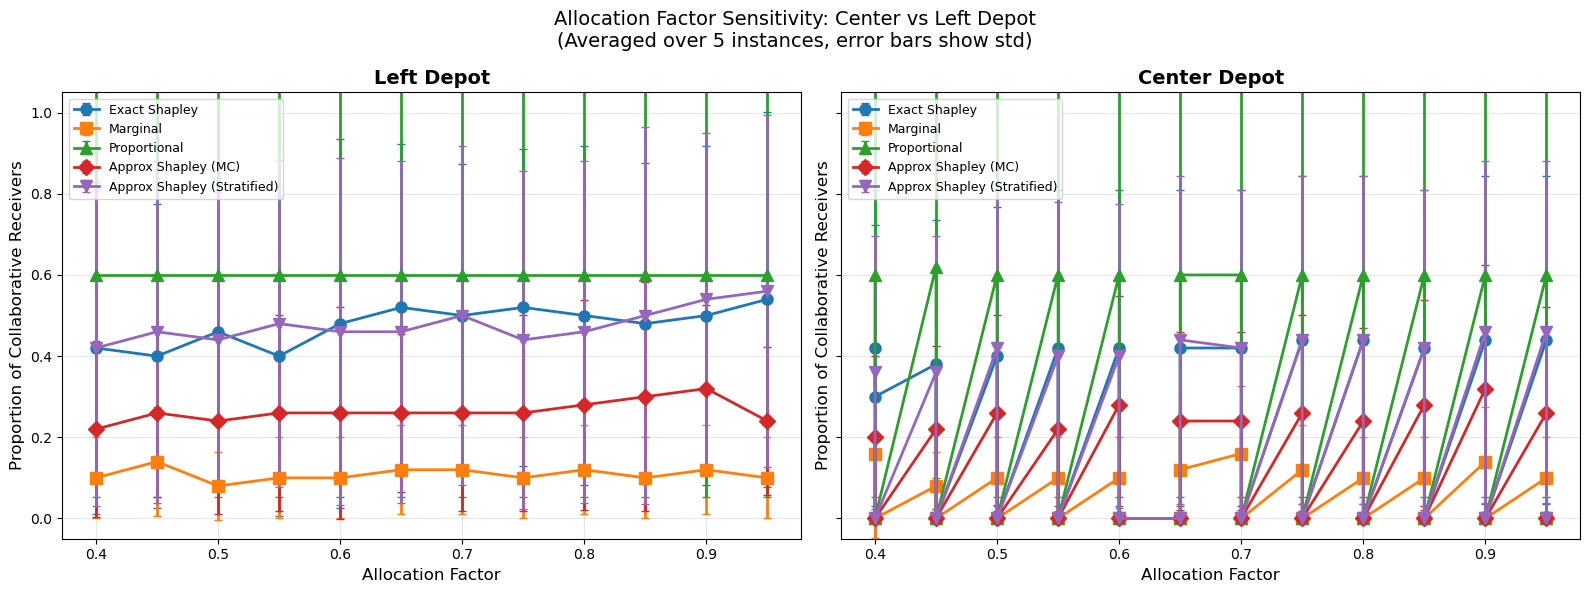

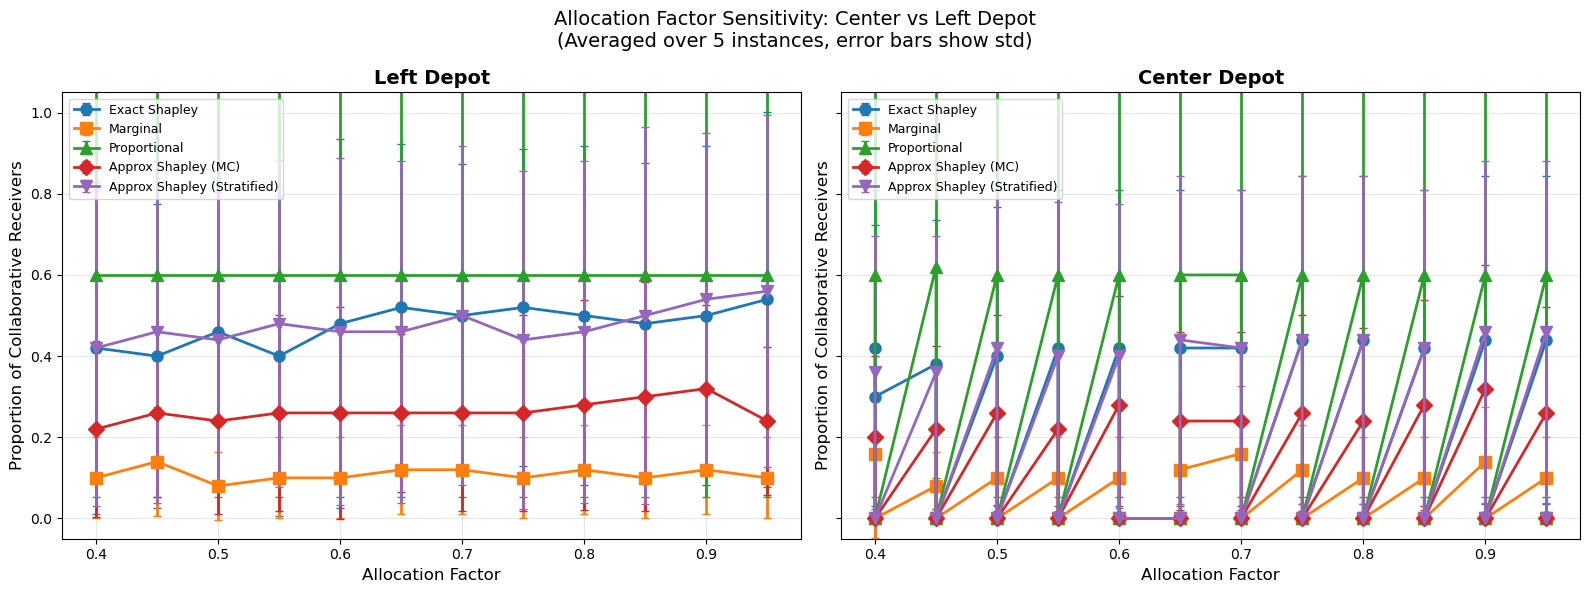

In [18]:
# Plot allocation sweep: Side by side comparison (Center vs Left)
plot_chessboard_alloc_sweep_comparison(chessboard_alloc_agg, output_path=None)

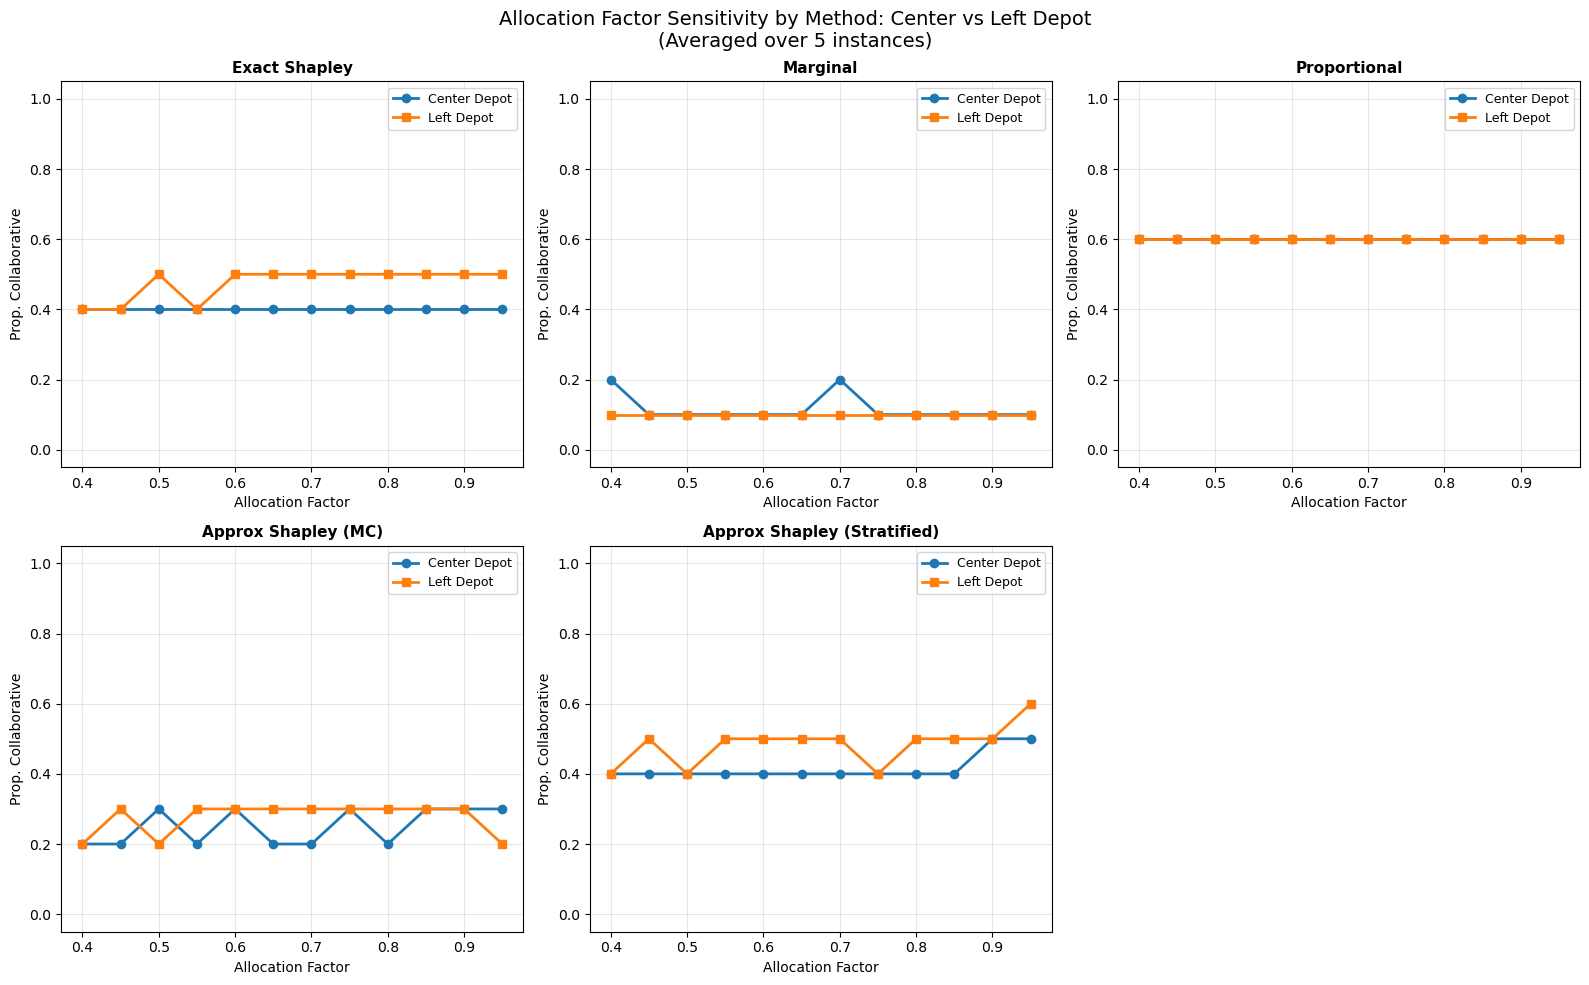

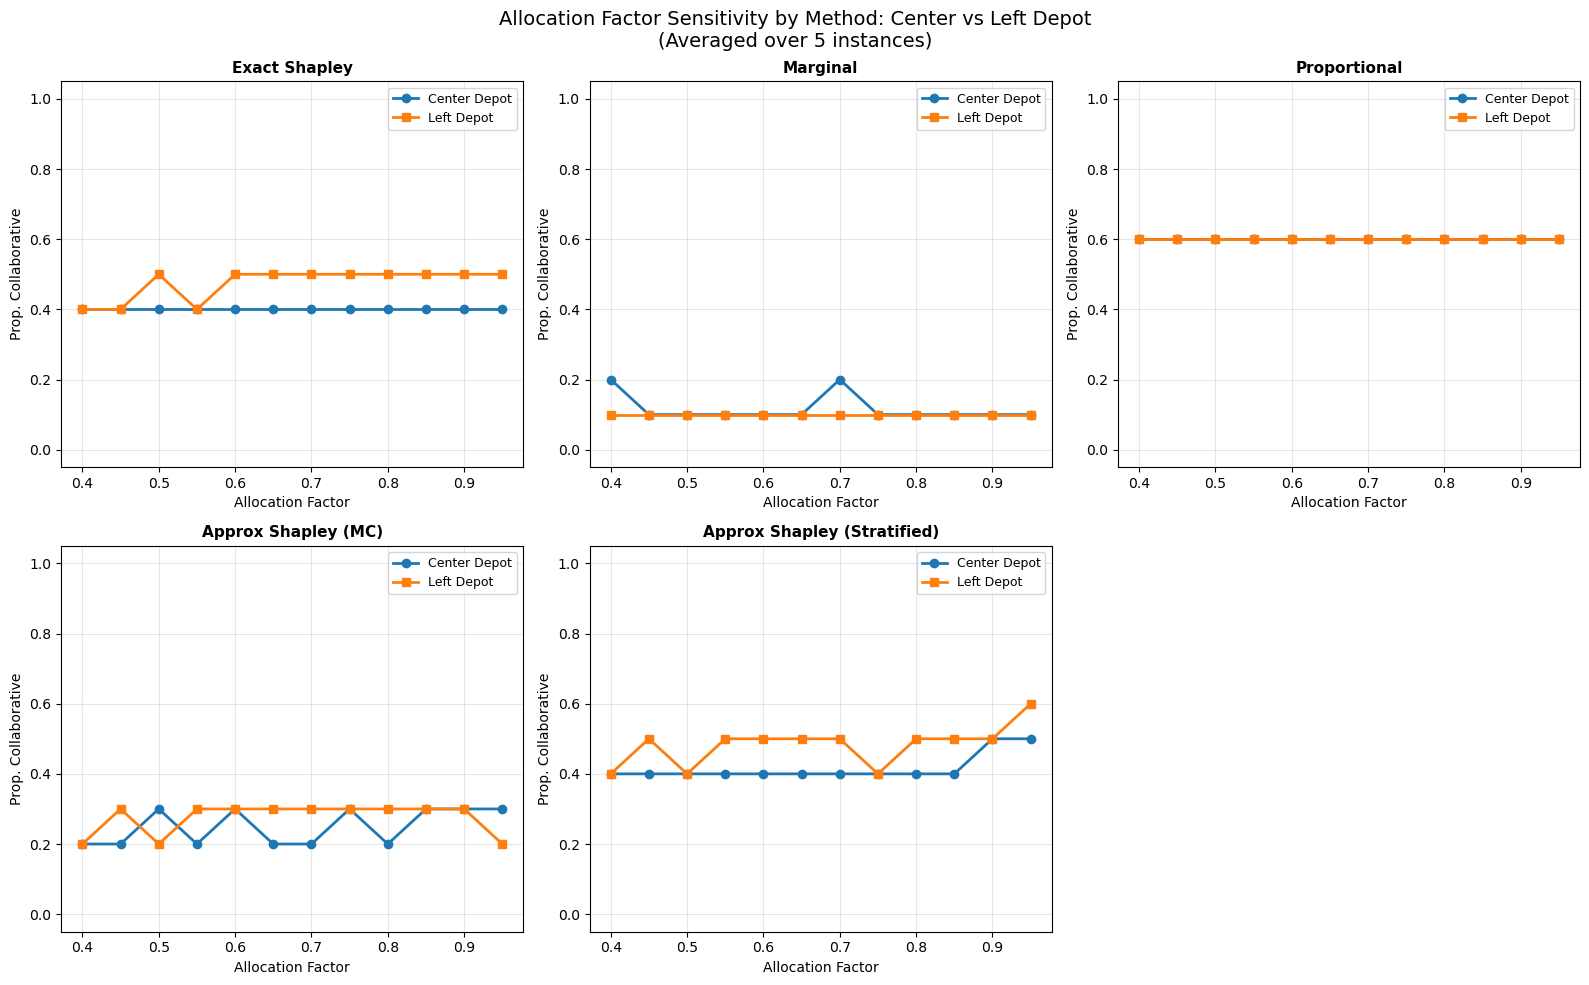

In [38]:
# Plot allocation sweep: By method (each method in separate subplot)
plot_chessboard_alloc_sweep_by_method(chessboard_alloc_agg, output_path=None)

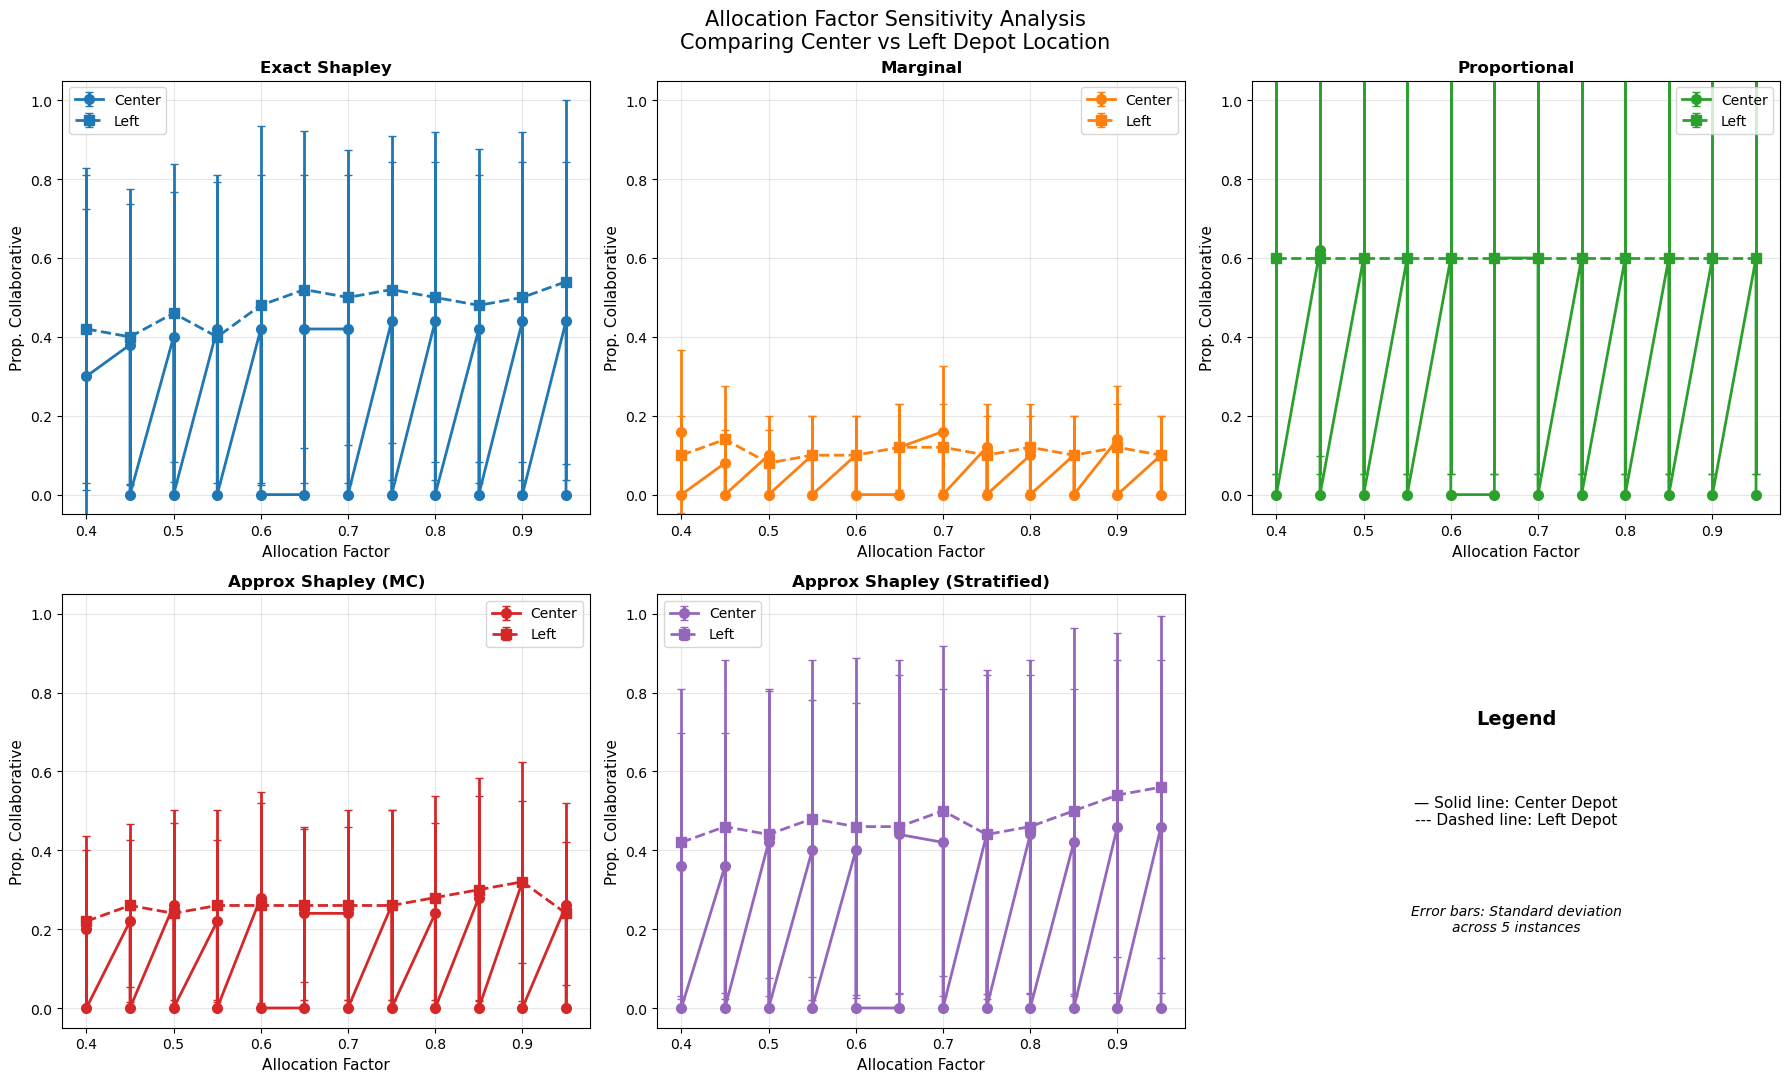

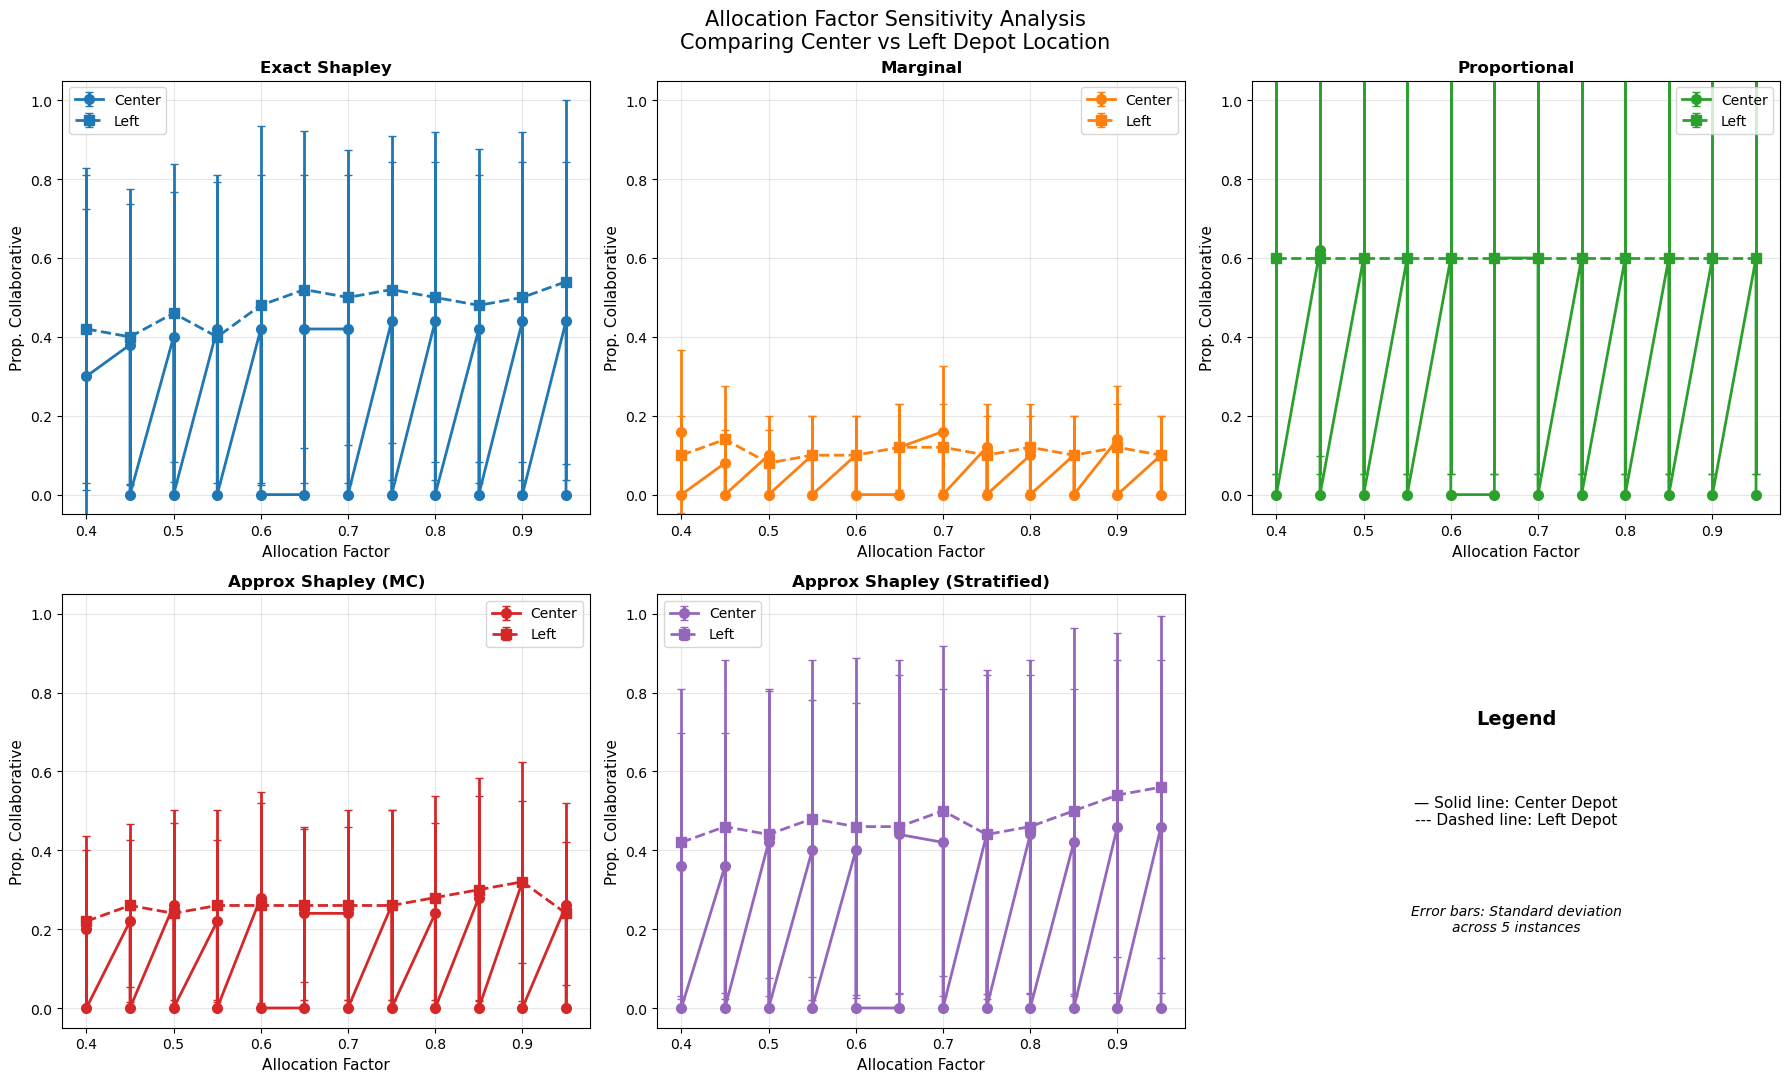

In [20]:
# Plot allocation sweep: Comprehensive view (same color per method, different linestyle per depot)
plot_chessboard_alloc_comprehensive(chessboard_alloc_agg, output_path=None)

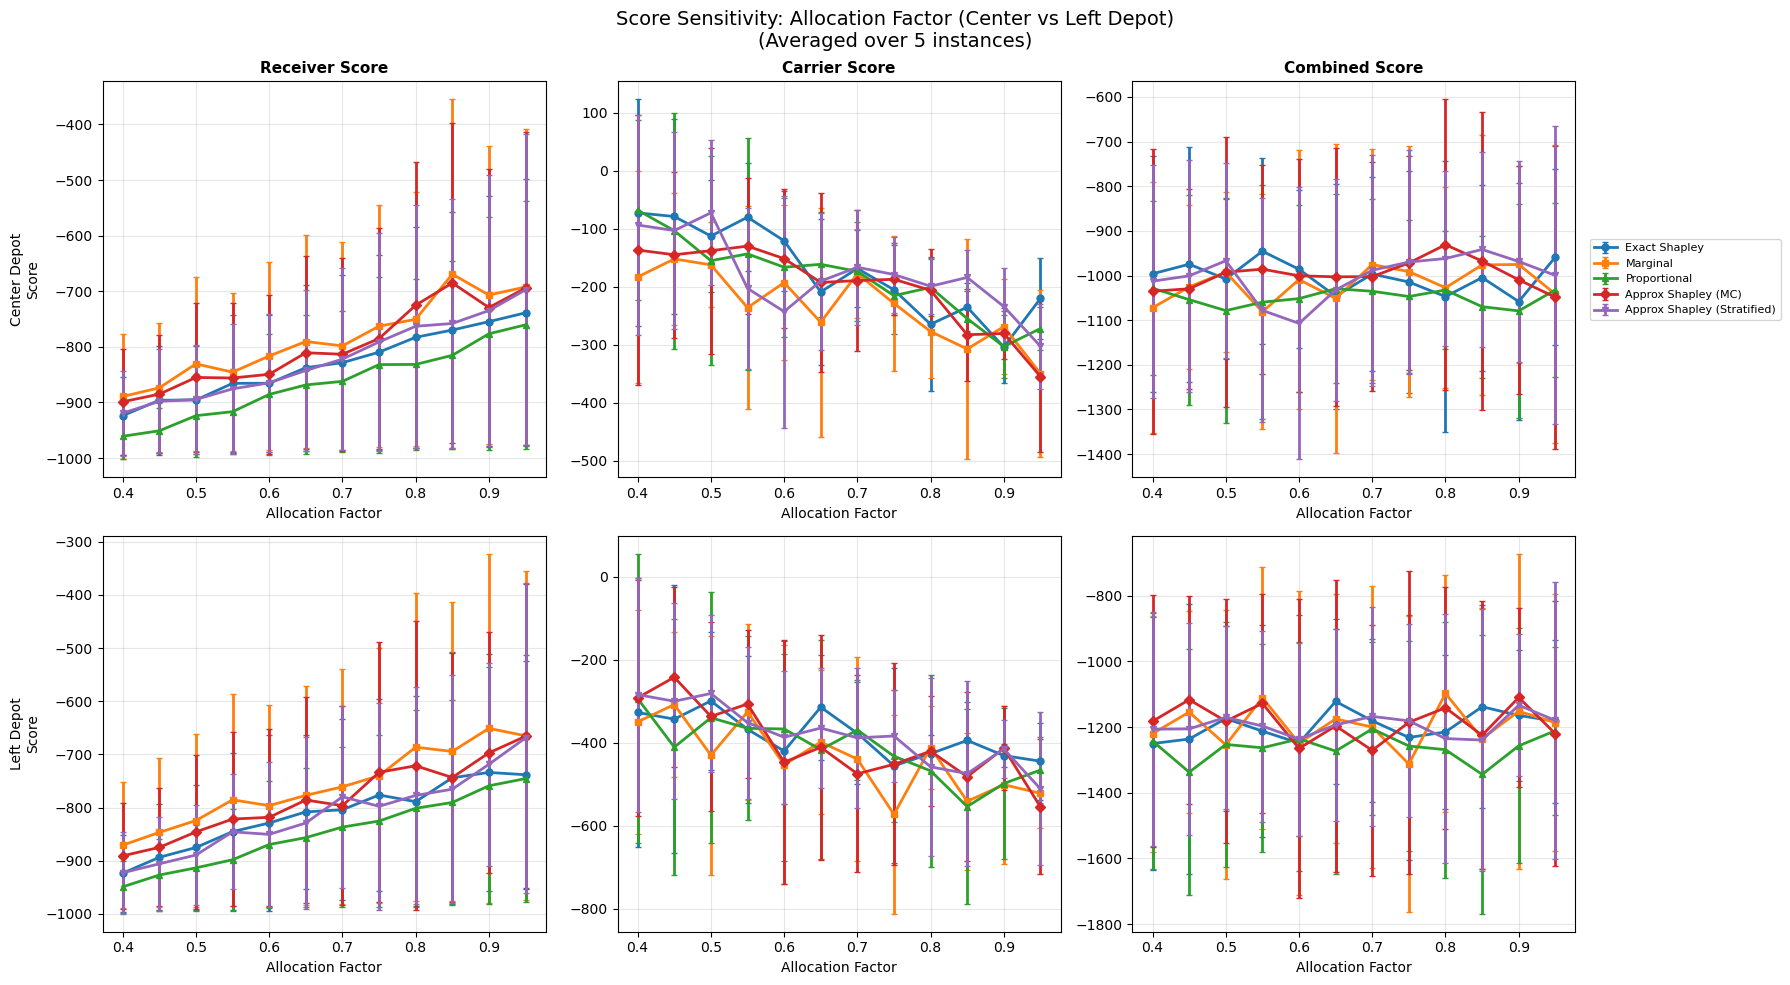

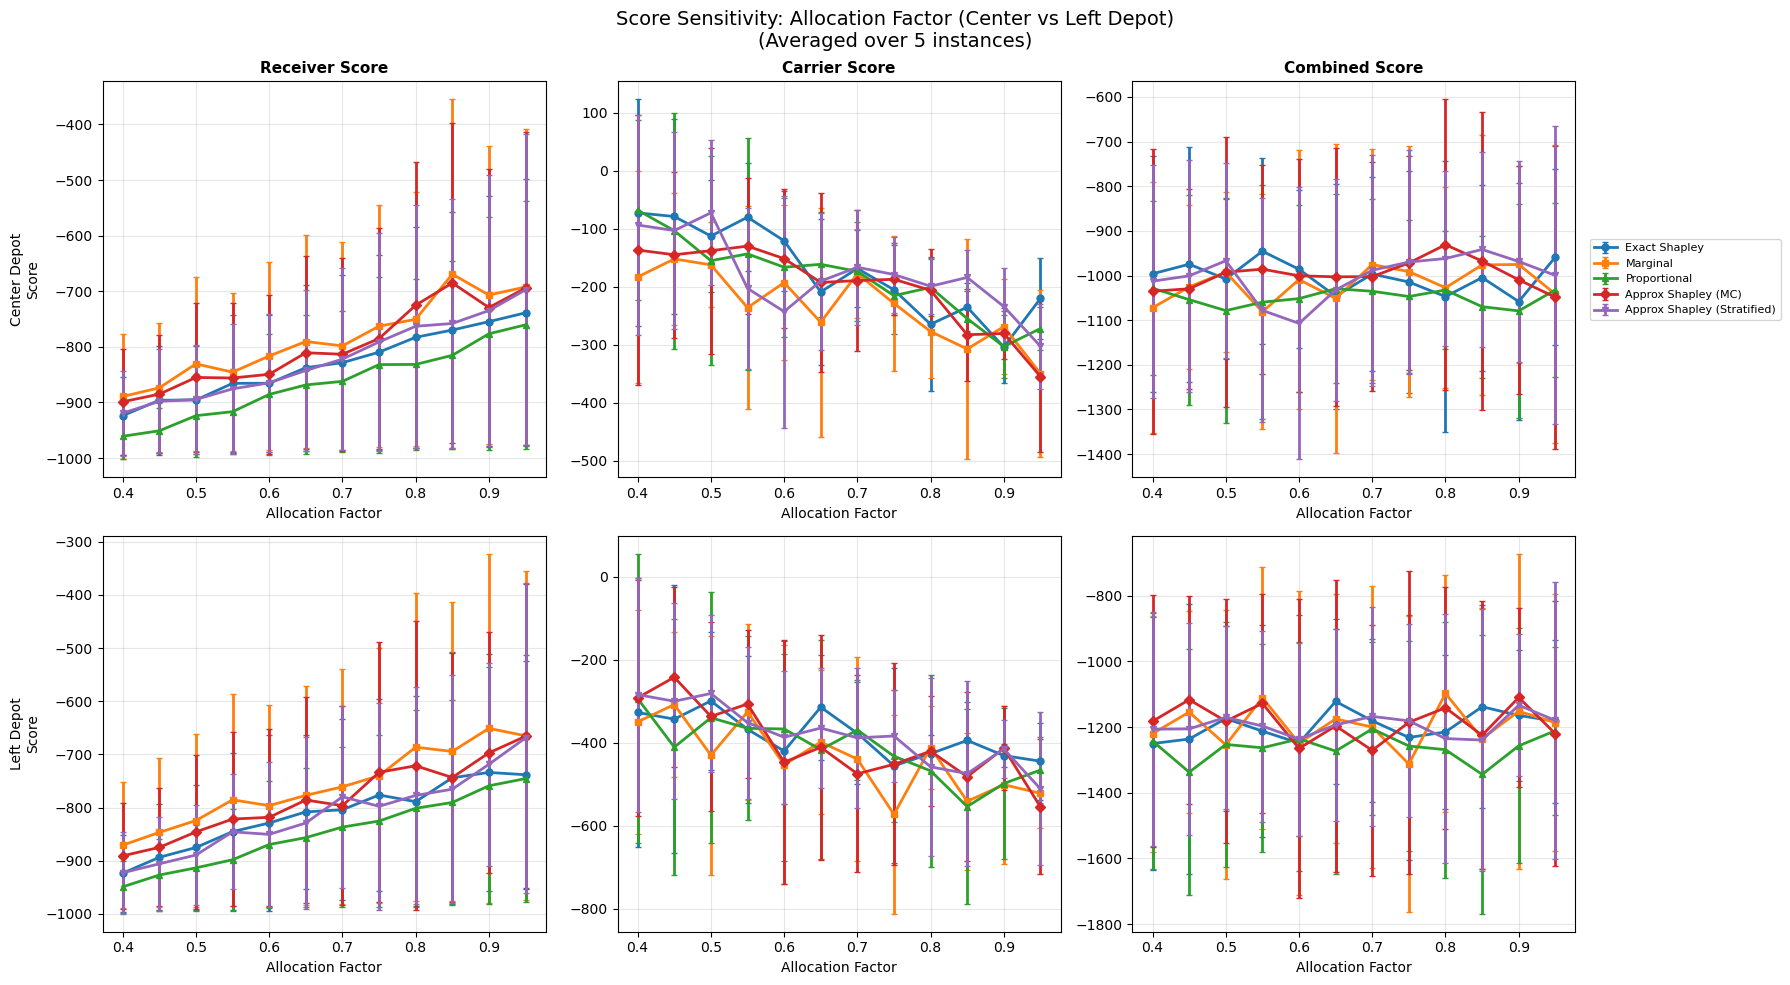

In [44]:
# Plot allocation sweep: Scores (receiver, carrier, combined)
plot_chessboard_alloc_sweep_scores(chessboard_alloc_agg, output_path=None)

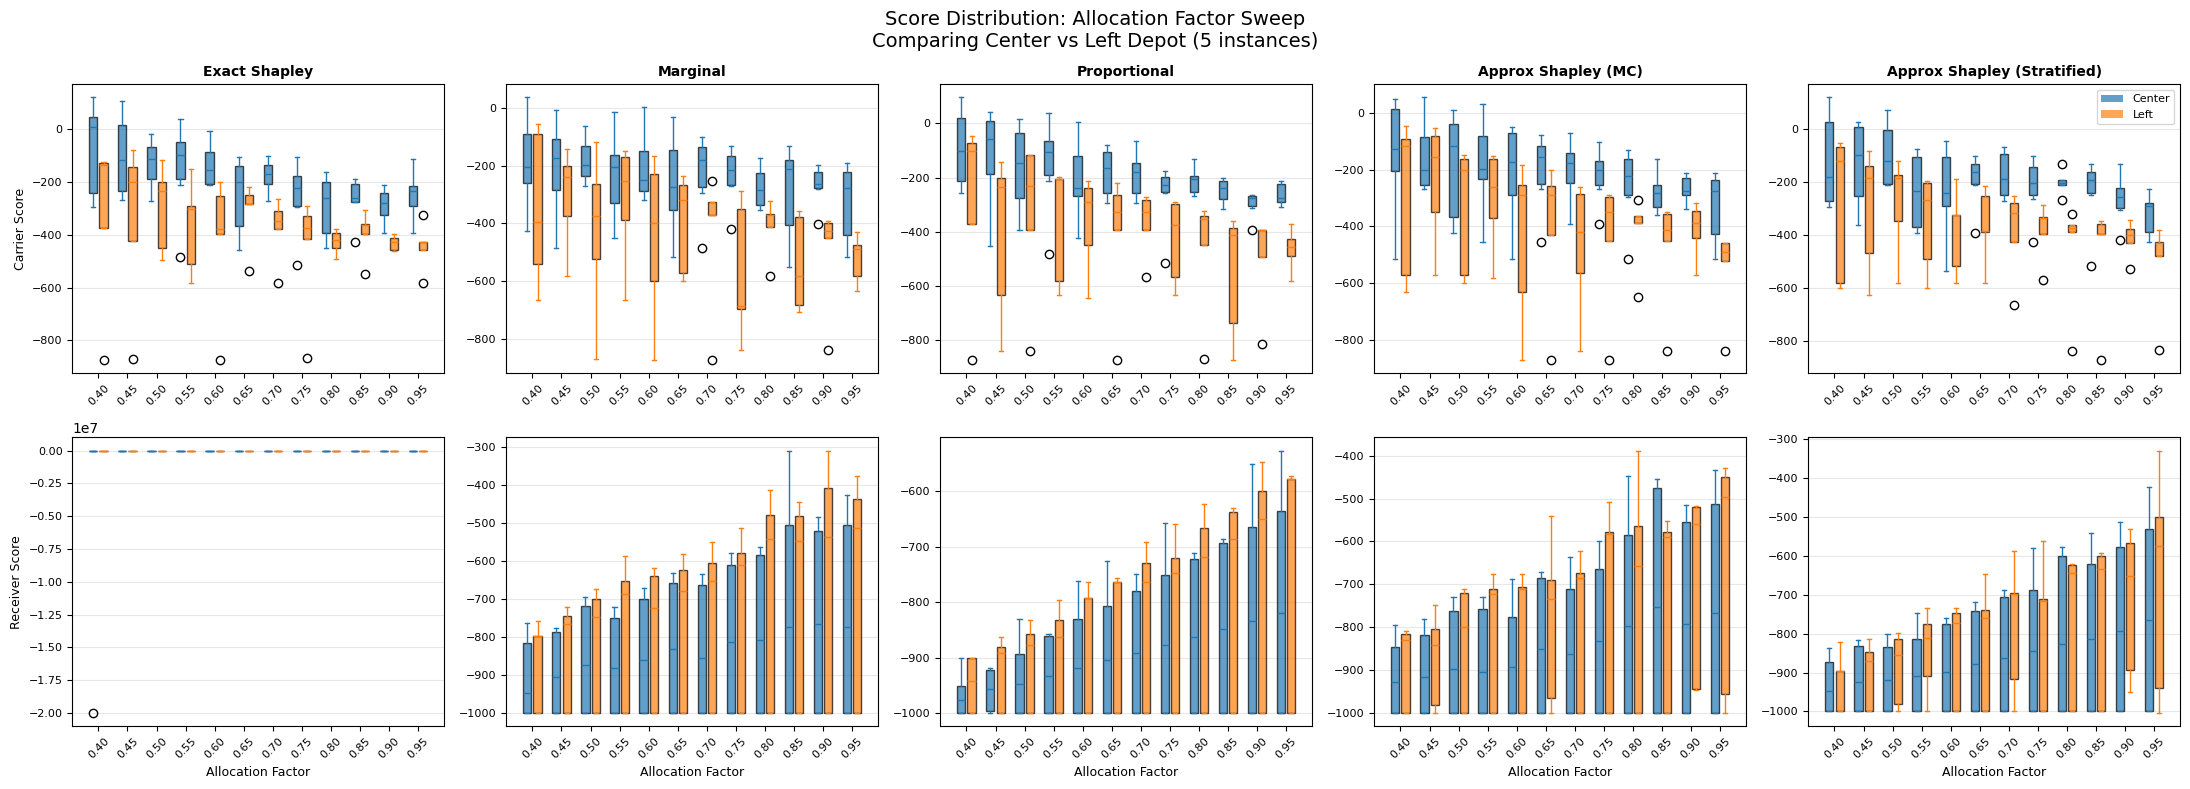

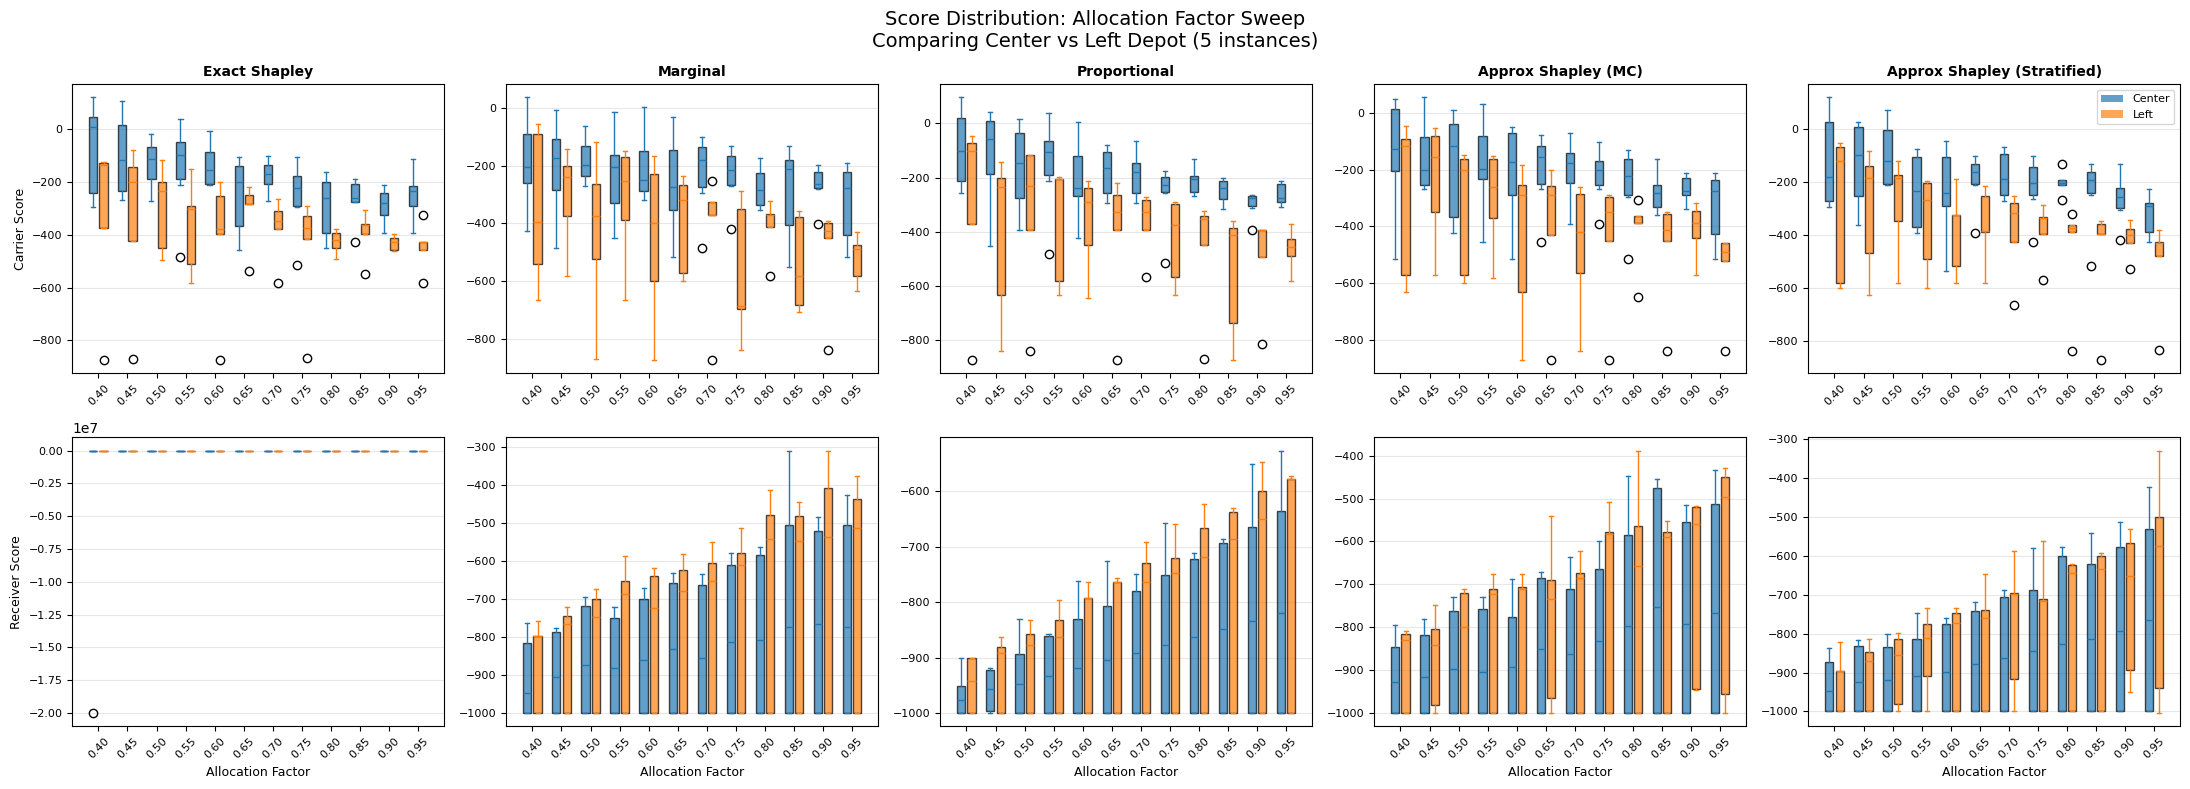

In [43]:
# Plot allocation sweep: Comprehensive scores view (box plots)
plot_chessboard_scores_comprehensive(chessboard_raw_df, sweep_type='alloc', output_path=None)

### Penalty Sweep Analysis

#### Fully-random location distribution

In [21]:
fully_random_agg_df = chessboard_pen_agg[chessboard_pen_agg['customer_distribution_type'] == 'FULLY_RANDOM'].copy()
fully_random_agg_df

,depot,customer_distribution_type,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
24,center,FULLY_RANDOM,penSweep,0.8,0.0000,exactShapley,8.1,1.911951,1.9,1.911951,10.0,0.8,0.191195,-7.726067e+02,111.990020,672.913880,79.805261,-9.969282e+01,182.612018,10
25,center,FULLY_RANDOM,penSweep,0.8,0.0003,exactShapley,3.2,2.394438,6.8,2.394438,10.0,0.3,0.239444,-8.783681e+02,94.323422,599.039470,26.998000,-2.793286e+02,118.701707,10
26,center,FULLY_RANDOM,penSweep,0.8,0.0006,exactShapley,2.1,1.663330,7.9,1.663330,10.0,0.2,0.166333,-9.391709e+02,43.851082,580.443799,14.584837,-3.587271e+02,52.459934,10
27,center,FULLY_RANDOM,penSweep,0.8,0.0008,exactShapley,2.3,1.888562,7.7,1.888562,10.0,0.2,0.188856,-9.345280e+02,45.995078,584.071550,18.130622,-3.504564e+02,57.759754,10
28,center,FULLY_RANDOM,penSweep,0.8,0.0014,exactShapley,1.6,0.966092,8.4,0.966092,10.0,0.2,0.096609,-9.494657e+02,28.290287,578.890153,14.748406,-3.705755e+02,34.981301,10
29,center,FULLY_RANDOM,penSweep,0.8,0.0028,exactShapley,1.3,0.948683,8.7,0.948683,10.0,0.1,0.094868,-9.465242e+02,39.954472,580.997729,16.854708,-3.655265e+02,47.087067,10
30,center,FULLY_RANDOM,penSweep,0.8,0.0056,exactShapley,0.6,0.699206,9.4,0.699206,10.0,0.1,0.069921,-9.619627e+02,42.395667,572.151411,13.768099,-3.898113e+02,47.557800,10
31,center,FULLY_RANDOM,penSweep,0.8,0.0098,exactShapley,0.4,0.516398,9.6,0.516398,10.0,0.0,0.051640,-9.834573e+02,23.084006,567.103282,14.441760,-4.163540e+02,33.100660,10
32,center,FULLY_RANDOM,penSweep,0.8,0.0140,exactShapley,0.4,0.516398,9.6,0.516398,10.0,0.0,0.051640,-9.910618e+02,15.941680,567.110794,11.307591,-4.239510e+02,21.341542,10
33,center,FULLY_RANDOM,penSweep,0.8,0.0167,exactShapley,0.0,NaN,10.0,NaN,10.0,0.0,NaN,-1.000000e+03,NaN,565.930000,NaN,-4.340700e+02,NaN,1


/var/folders/wc/gp218rn503j731s25nggwptw0000gp/T/ipykernel_46253/3818708938.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9)


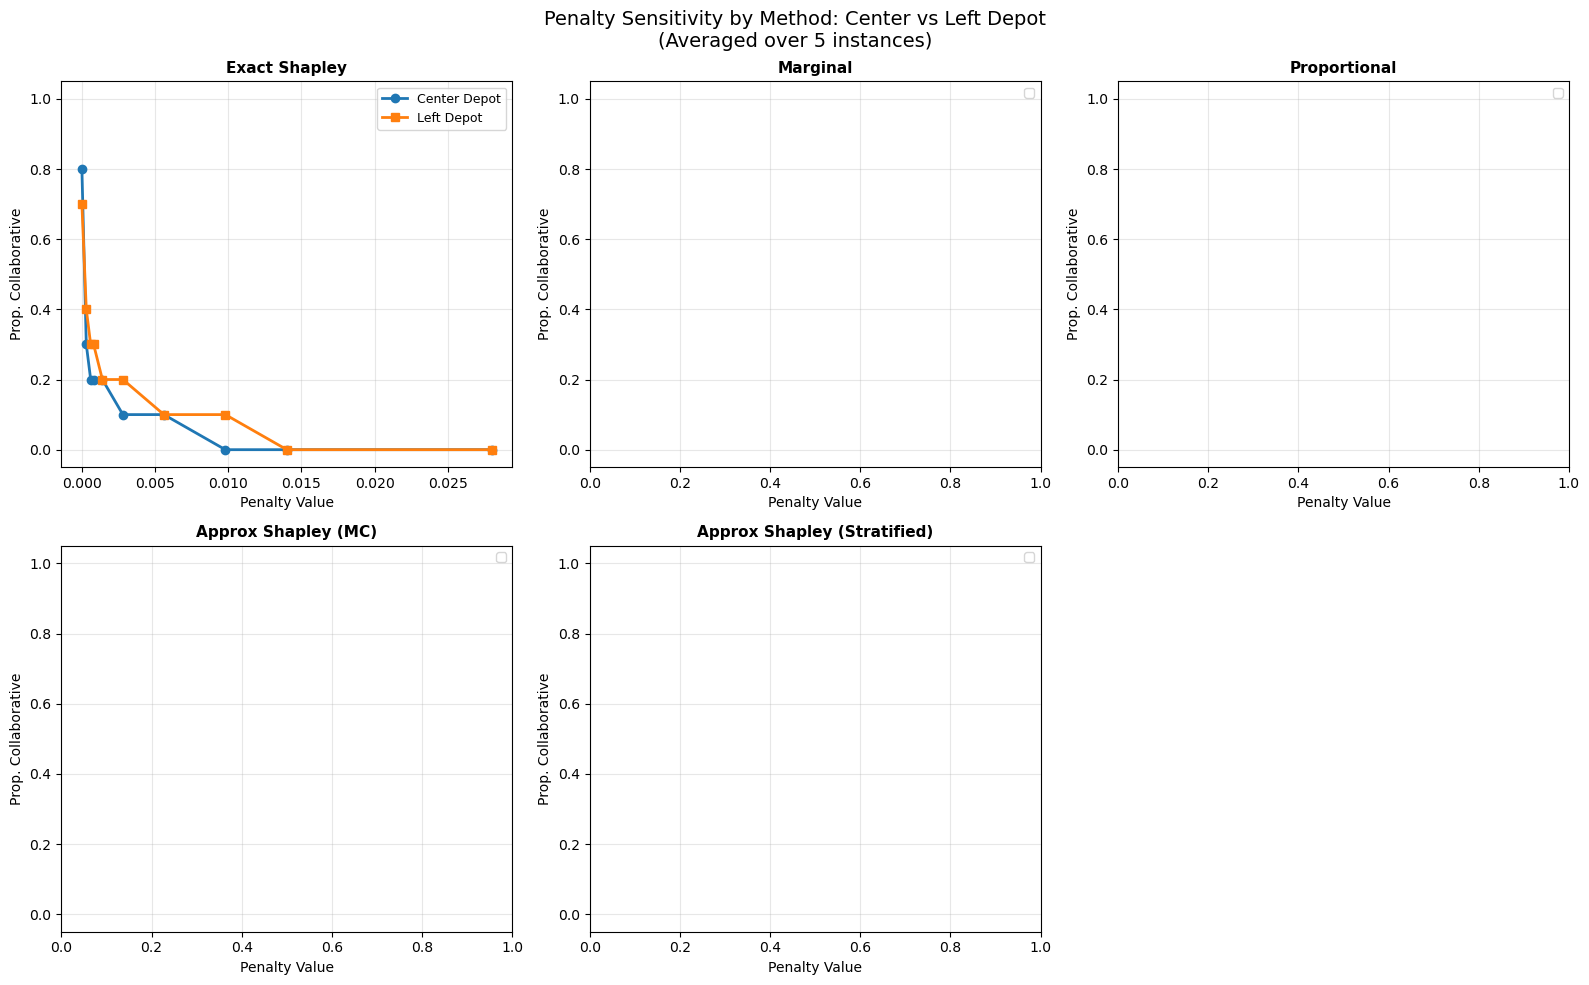

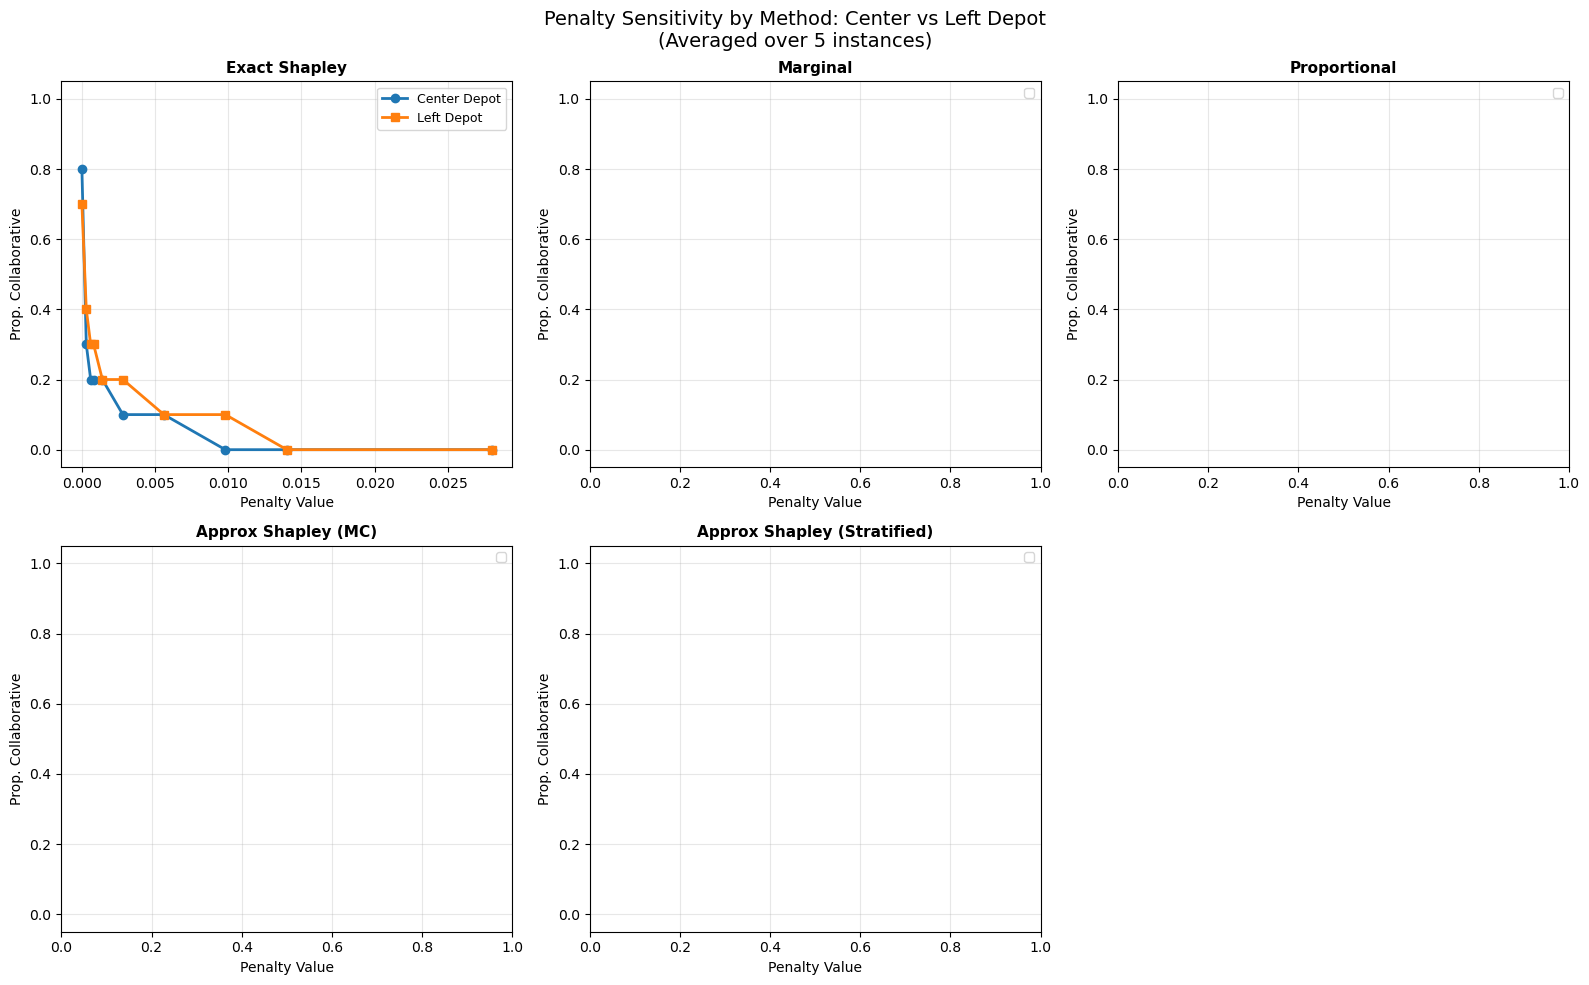

In [41]:
# Plot penalty sweep: By method (each method in separate subplot)
plot_chessboard_pen_sweep_by_method(fully_random_agg_df, output_path=None)

#### Clustered

In [22]:
clustered_agg_df = chessboard_pen_agg[chessboard_pen_agg['customer_distribution_type'] == 'CLUSTERED'].copy()
clustered_agg_df

,depot,customer_distribution_type,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
0,center,CLUSTERED,penSweep,0.8,0.0000,exactShapley,7.84,1.788398,2.16,1.788398,10.0,0.8,0.178840,-833.963818,143.701712,692.022888,75.193515,-141.940930,195.851061,50
1,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,2.94,2.637330,7.06,2.637330,10.0,0.3,0.263733,-894.718865,107.149853,617.029507,47.740522,-277.689357,143.052180,50
2,center,CLUSTERED,penSweep,0.8,0.0006,exactShapley,2.40,1.955050,7.60,1.955050,10.0,0.2,0.195505,-924.253196,50.855810,610.041036,24.736901,-314.212160,70.056943,10
3,center,CLUSTERED,penSweep,0.8,0.0008,exactShapley,1.76,1.802040,8.24,1.802040,10.0,0.2,0.180204,-933.173290,81.660152,610.826268,39.744969,-322.347022,114.527745,50
4,center,CLUSTERED,penSweep,0.8,0.0014,exactShapley,1.14,1.178203,8.86,1.178203,10.0,0.1,0.117820,-926.942008,85.424325,604.131081,23.812487,-322.810927,101.549382,50
5,center,CLUSTERED,penSweep,0.8,0.0028,exactShapley,0.94,0.912722,9.06,0.912722,10.0,0.1,0.091272,-939.338326,79.531800,605.035683,26.741045,-334.302643,94.790505,50
6,center,CLUSTERED,penSweep,0.8,0.0056,exactShapley,0.64,0.920514,9.36,0.920514,10.0,0.1,0.092051,-948.791510,67.527638,601.461917,20.980309,-347.329594,80.017297,50
7,center,CLUSTERED,penSweep,0.8,0.0098,exactShapley,0.34,0.519419,9.66,0.519419,10.0,0.0,0.051942,-962.913584,65.170277,599.844704,24.212329,-363.068880,83.664076,50
8,center,CLUSTERED,penSweep,0.8,0.0140,exactShapley,0.32,0.620730,9.68,0.620730,10.0,0.0,0.062073,-971.253345,55.317018,596.956114,22.093786,-374.297232,67.853347,50
9,center,CLUSTERED,penSweep,0.8,0.0167,exactShapley,0.18,0.437526,9.82,0.437526,10.0,0.0,0.043753,-974.184432,61.718171,596.660734,25.699723,-377.523699,80.413517,50


/var/folders/wc/gp218rn503j731s25nggwptw0000gp/T/ipykernel_3728/3818708938.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9)


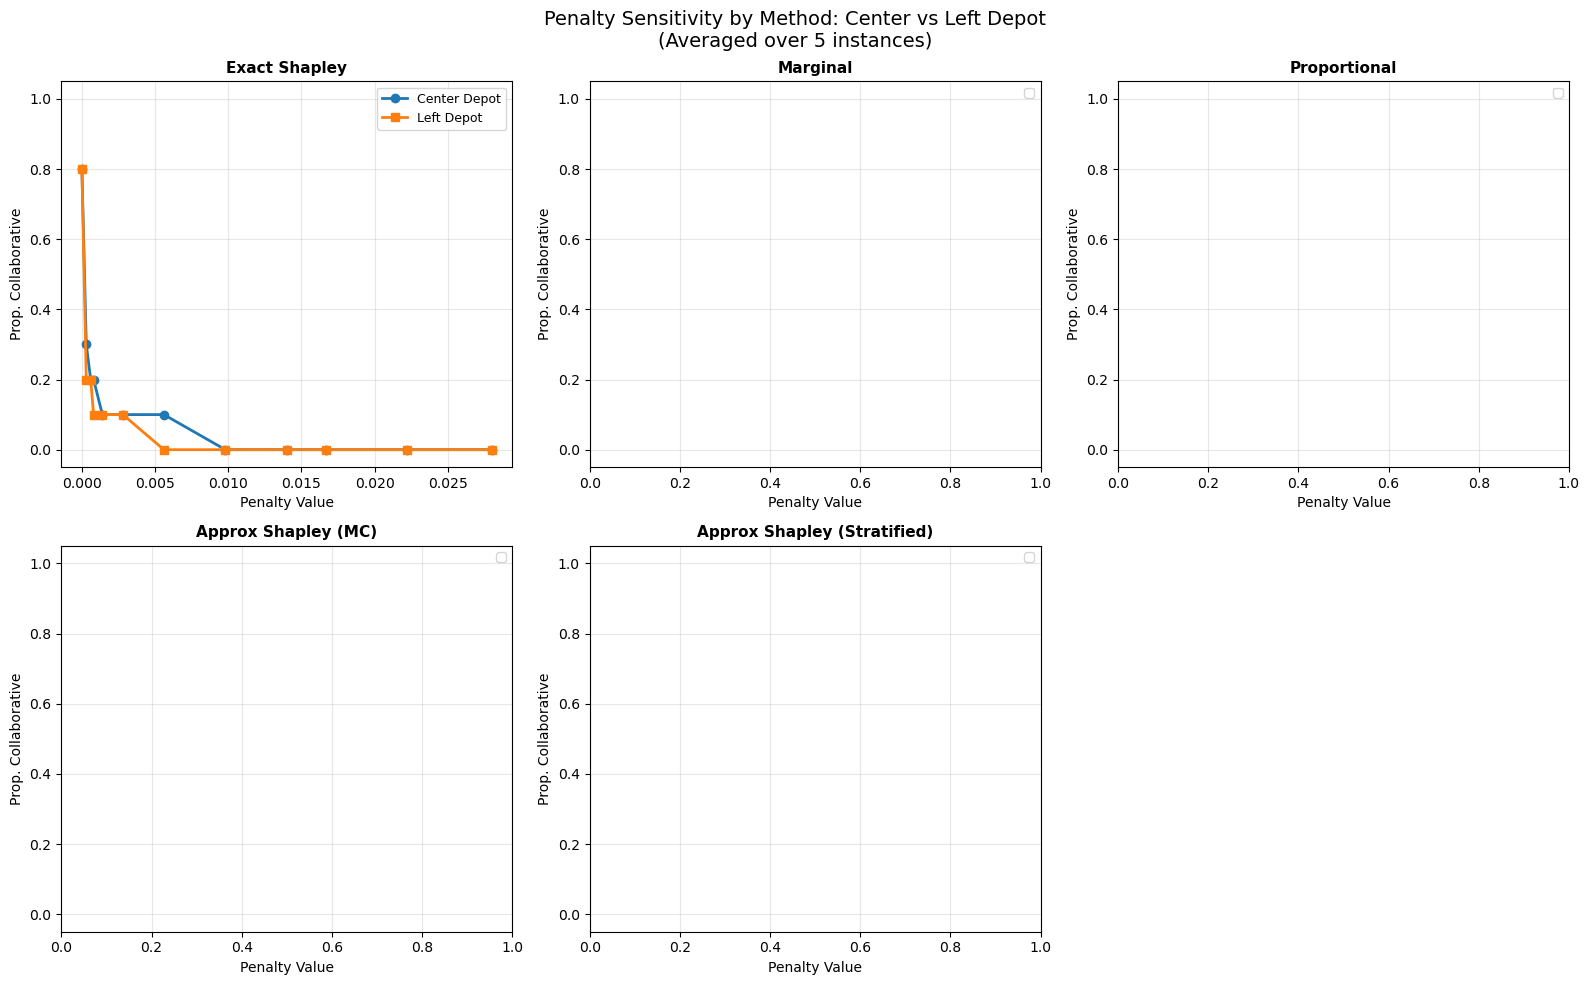

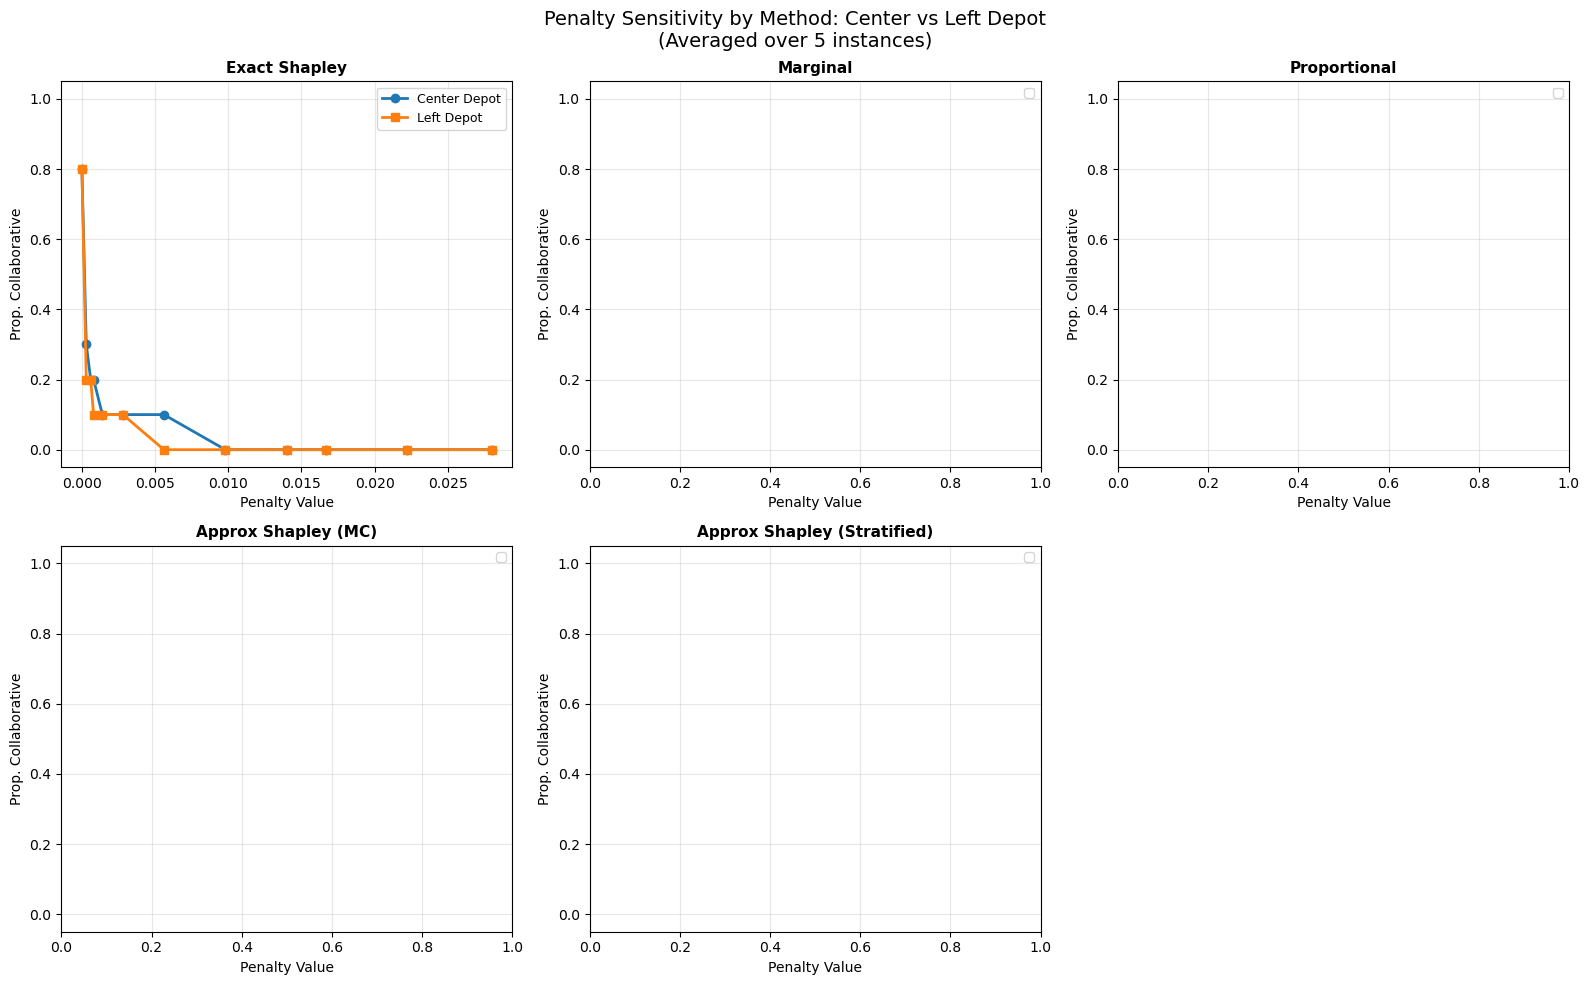

In [23]:
# Plot penalty sweep: By method (each method in separate subplot)
plot_chessboard_pen_sweep_by_method(clustered_agg_df, output_path=None)

#### Dispersed

In [24]:
dispersed_agg_df = chessboard_pen_agg[chessboard_pen_agg['customer_distribution_type'] == 'DISPERSED'].copy()
dispersed_agg_df

,depot,customer_distribution_type,sweep_type,af,penalty,method,count_collaborative_mean,count_collaborative_std,count_non_collaborative_mean,count_non_collaborative_std,total_receivers_mean,prop_collaborative_mean,prop_collaborative_std,receiver_score_mean,receiver_score_std,carrier_score_mean,carrier_score_std,combined_score_mean,combined_score_std,n_instances
12,center,DISPERSED,penSweep,0.8,0.0000,exactShapley,8.40,1.399708,1.60,1.399708,10.0,0.8,0.139971,-762.695441,141.594171,650.918777,72.606511,-111.776663,181.503530,50
13,center,DISPERSED,penSweep,0.8,0.0003,exactShapley,5.80,2.080031,4.20,2.080031,10.0,0.6,0.208003,-819.302648,120.208509,613.683097,50.161566,-205.619551,152.257662,50
14,center,DISPERSED,penSweep,0.8,0.0006,exactShapley,3.40,0.966092,6.60,0.966092,10.0,0.3,0.096609,-898.632323,46.287988,591.789868,10.147294,-306.842455,52.246026,10
15,center,DISPERSED,penSweep,0.8,0.0008,exactShapley,4.50,2.651530,5.50,2.651530,10.0,0.4,0.265153,-852.579343,100.830240,609.118799,40.509773,-243.460545,126.585221,50
16,center,DISPERSED,penSweep,0.8,0.0014,exactShapley,3.48,2.323263,6.52,2.323263,10.0,0.3,0.232326,-859.575278,102.409349,605.726415,41.719539,-253.848863,130.831979,50
17,center,DISPERSED,penSweep,0.8,0.0028,exactShapley,2.60,1.807016,7.40,1.807016,10.0,0.3,0.180702,-876.110955,98.655040,591.956082,36.238699,-284.154874,119.944931,50
18,center,DISPERSED,penSweep,0.8,0.0056,exactShapley,1.44,1.072095,8.56,1.072095,10.0,0.1,0.107210,-907.992645,82.478037,589.712351,36.192535,-318.280293,108.812219,50
19,center,DISPERSED,penSweep,0.8,0.0098,exactShapley,0.78,0.789988,9.22,0.789988,10.0,0.1,0.078999,-929.148467,96.253367,574.945001,40.822981,-354.203466,125.145305,50
20,center,DISPERSED,penSweep,0.8,0.0140,exactShapley,0.70,0.707107,9.30,0.707107,10.0,0.1,0.070711,-920.279749,89.426366,578.095509,36.091699,-342.184240,111.715562,50
21,center,DISPERSED,penSweep,0.8,0.0167,exactShapley,0.40,0.638877,9.60,0.638877,10.0,0.0,0.063888,-959.525114,67.271788,573.795064,26.818143,-385.730050,90.485836,50


/var/folders/wc/gp218rn503j731s25nggwptw0000gp/T/ipykernel_3728/3818708938.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9)


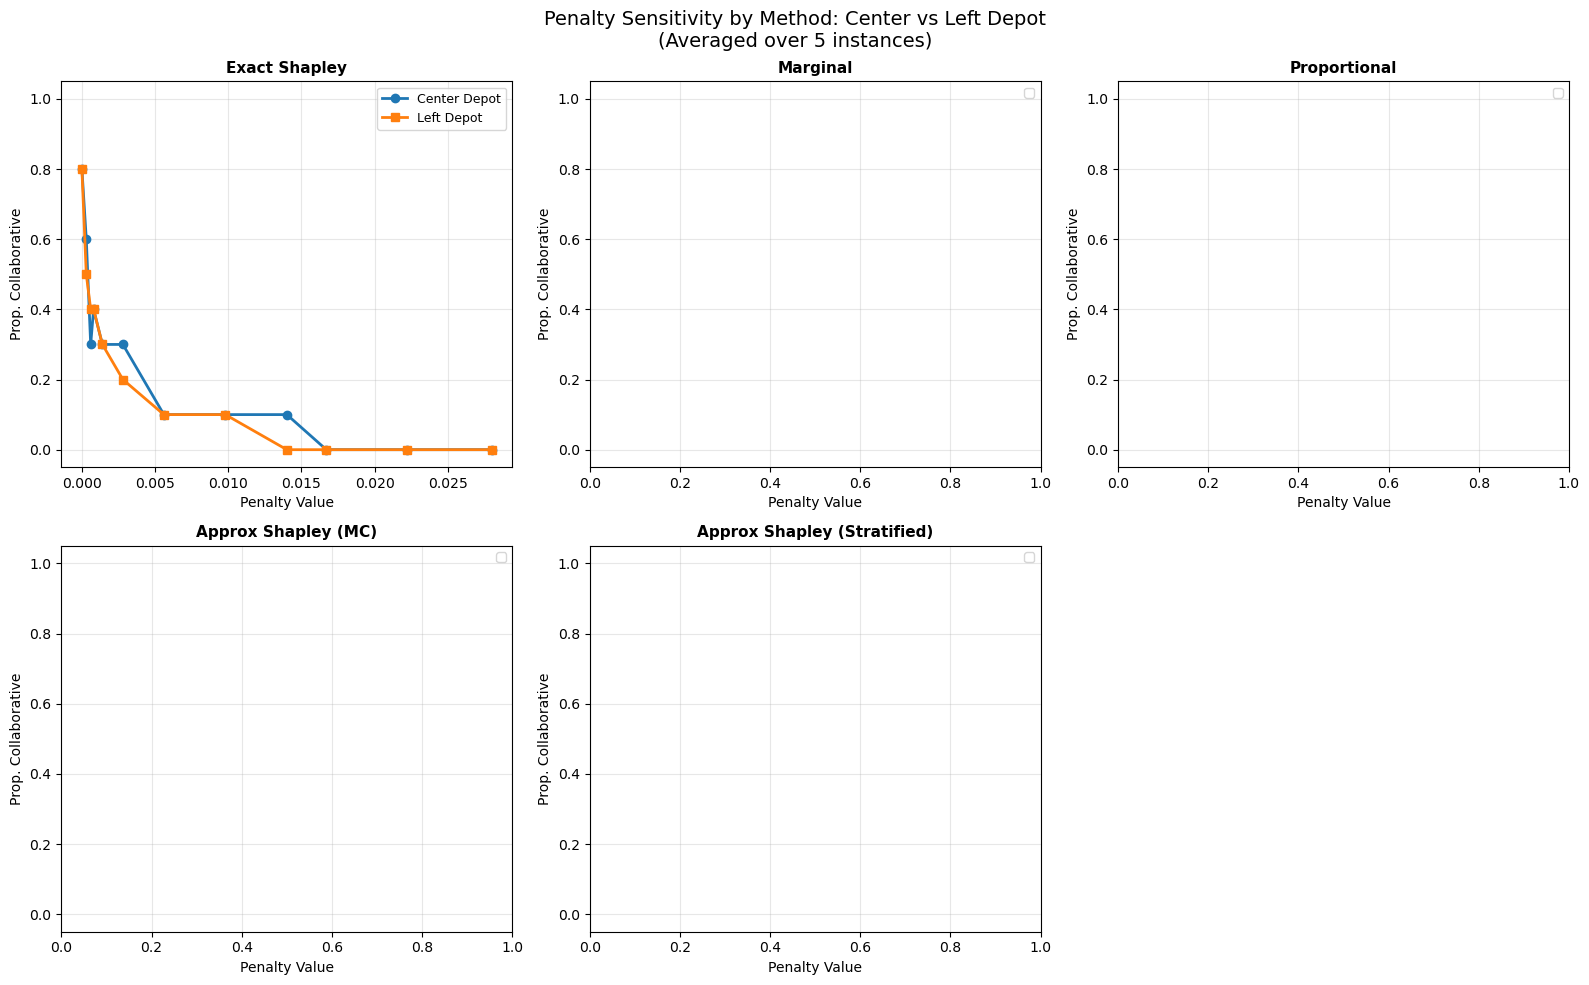

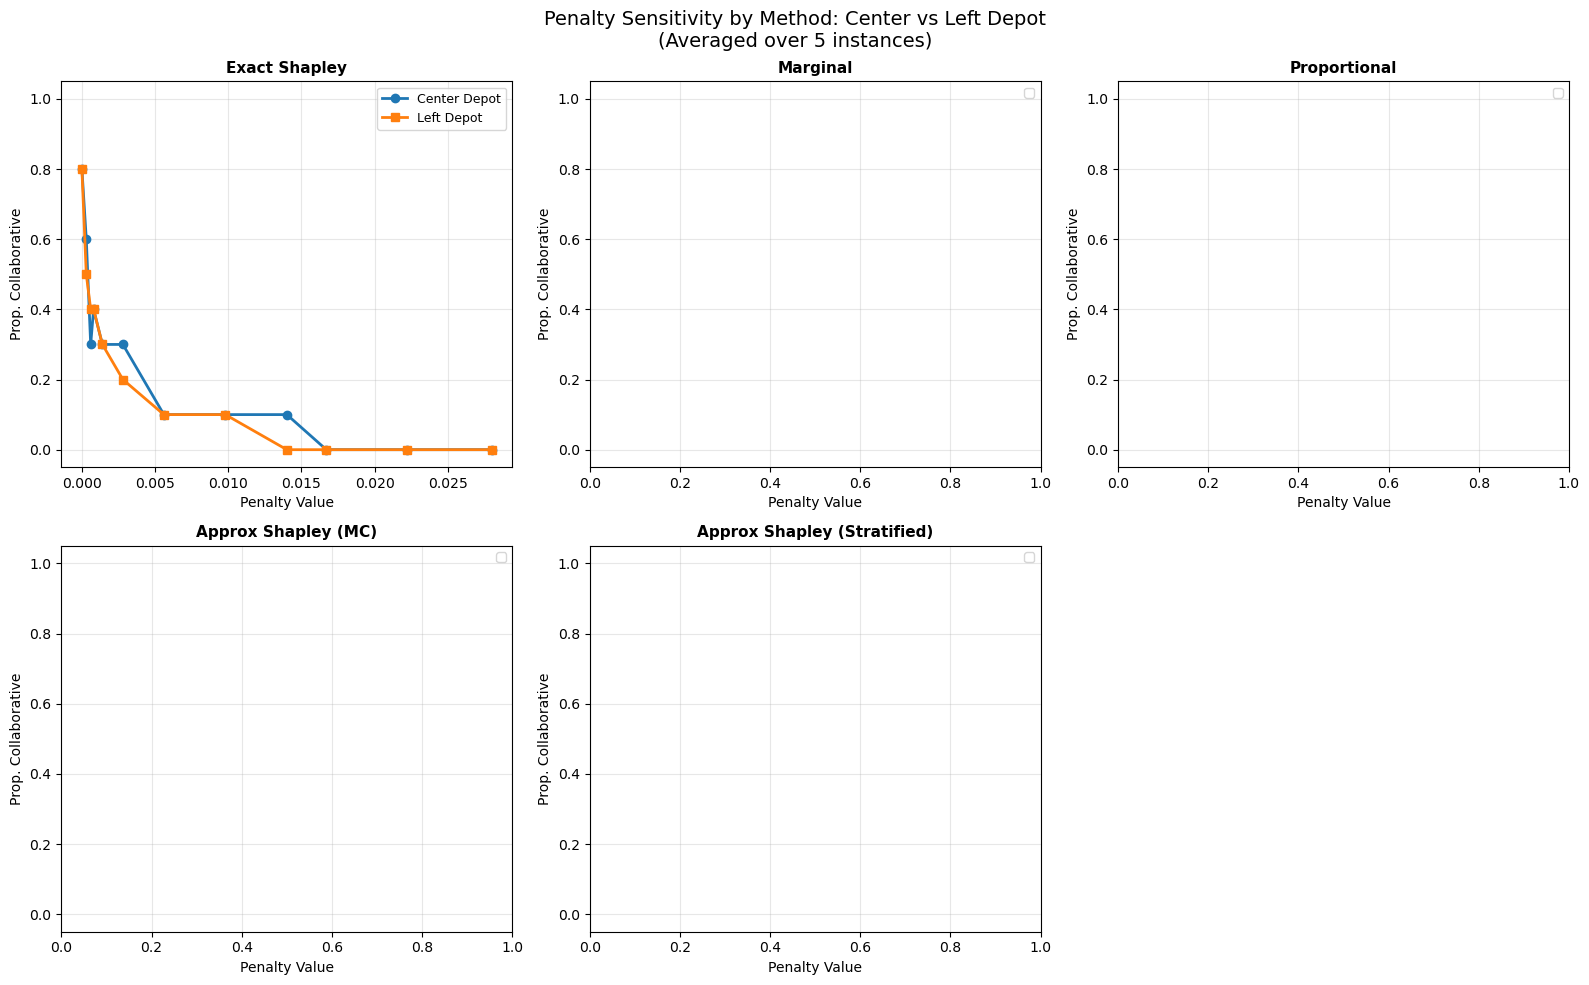

In [25]:
# Plot penalty sweep: By method (each method in separate subplot)
plot_chessboard_pen_sweep_by_method(dispersed_agg_df, output_path=None)

#### General

In [ ]:
# Plot penalty sweep: Side by side comparison (Center vs Left)
plot_chessboard_pen_sweep_comparison(chessboard_pen_agg, output_path=None)

/var/folders/wc/gp218rn503j731s25nggwptw0000gp/T/ipykernel_3728/3818708938.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9)


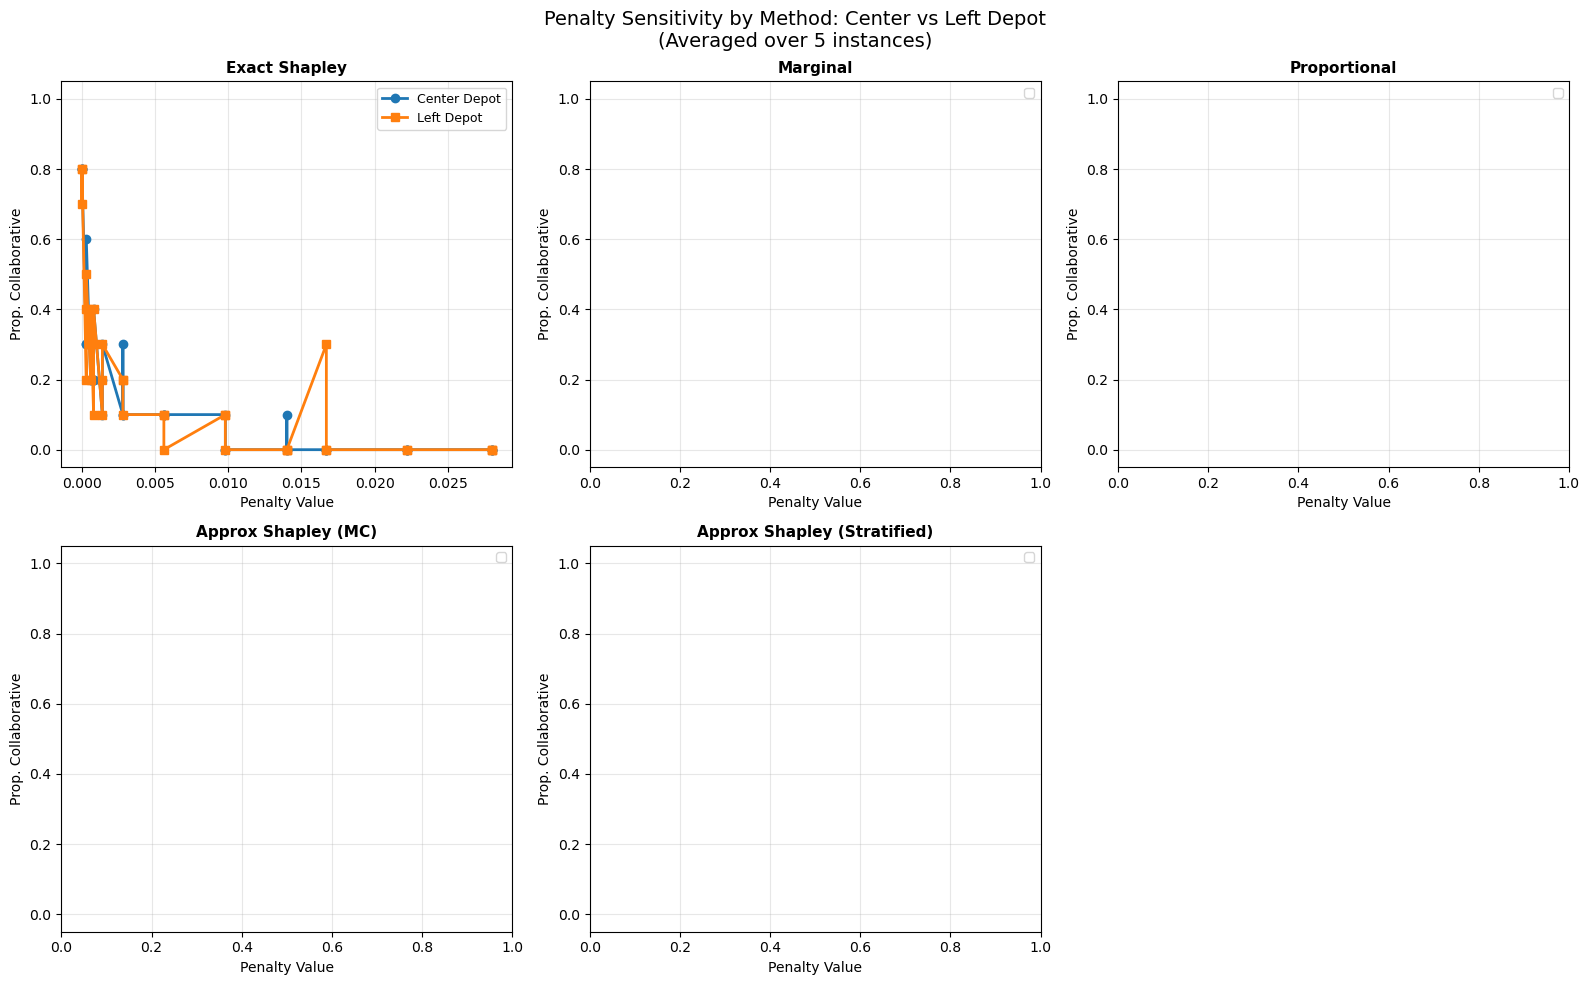

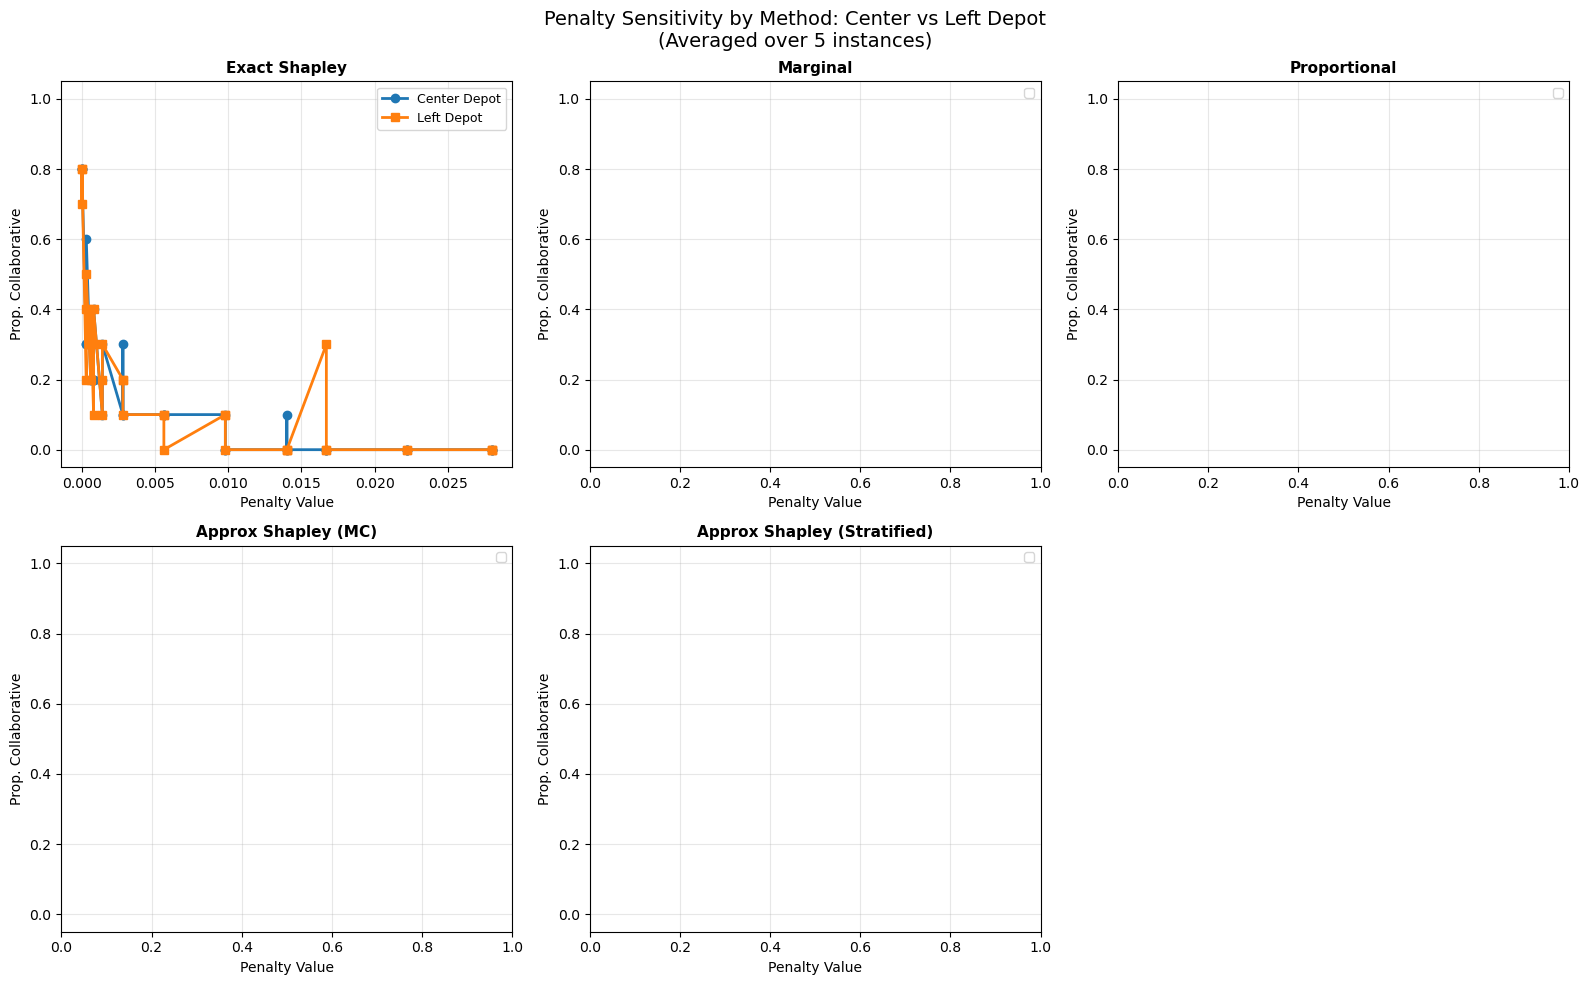

In [26]:
# Plot penalty sweep: By method (each method in separate subplot)
plot_chessboard_pen_sweep_by_method(chessboard_pen_agg, output_path=None)

In [ ]:
# Plot penalty sweep: Comprehensive view (same color per method, different linestyle per depot)
plot_chessboard_pen_comprehensive(chessboard_pen_agg, output_path=None)

In [ ]:
# Plot penalty sweep: Scores (receiver, carrier, combined)
plot_chessboard_pen_sweep_scores(chessboard_pen_agg, output_path=None)

In [ ]:
# Plot penalty sweep: Comprehensive scores view (box plots)
plot_chessboard_scores_comprehensive(chessboard_raw_df, sweep_type='pen', output_path=None)

### Single instance

In [47]:
chessboard_raw_df

,folder,depot,sweep_type,af,penalty,method,instance,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,left-allocSweep-af0.85-p0.005-exactShapley-i03,left,allocSweep,0.85,0.005,exactShapley,3,0,10,10,0.0,-1000.000000,-395.444000,-1395.444000
1,center-allocSweep-af0.40-p0.005-proportional-i02,center,allocSweep,0.40,0.005,proportional,2,10,0,10,1.0,-950.439798,7.666303,-942.773495
2,left-allocSweep-af0.75-p0.005-proportional-i04,left,allocSweep,0.75,0.005,proportional,4,10,0,10,1.0,-720.843505,-297.290535,-1018.134039
3,left-penSweep-af0.80-p0.035-approxShapMC-i01,left,penSweep,0.80,0.035,approxShapMC,1,2,8,10,0.2,-797.146762,-405.172690,-1202.319452
4,left-allocSweep-af0.95-p0.005-approxShapStrat-i02,left,allocSweep,0.95,0.005,approxShapStrat,2,7,3,10,0.7,-329.343601,-427.914288,-757.257889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1256,center-penSweep-af0.80-p0.040-exactShapley-i02,center,penSweep,0.80,0.040,exactShapley,2,1,9,10,0.1,-689.146762,-190.908818,-880.055579
1257,left-penSweep-af0.80-p0.030-approxShapMC-i02,left,penSweep,0.80,0.030,approxShapMC,2,1,9,10,0.1,-606.839006,-641.749904,-1248.588911
1258,center-allocSweep-af0.90-p0.005-proportional-i01,center,allocSweep,0.90,0.005,proportional,1,10,0,10,1.0,-550.012927,-265.687351,-815.700278
1259,center-penSweep-af0.80-p0.050-proportional-i01,center,penSweep,0.80,0.050,proportional,1,1,9,10,0.1,-726.752316,-407.092444,-1133.844760


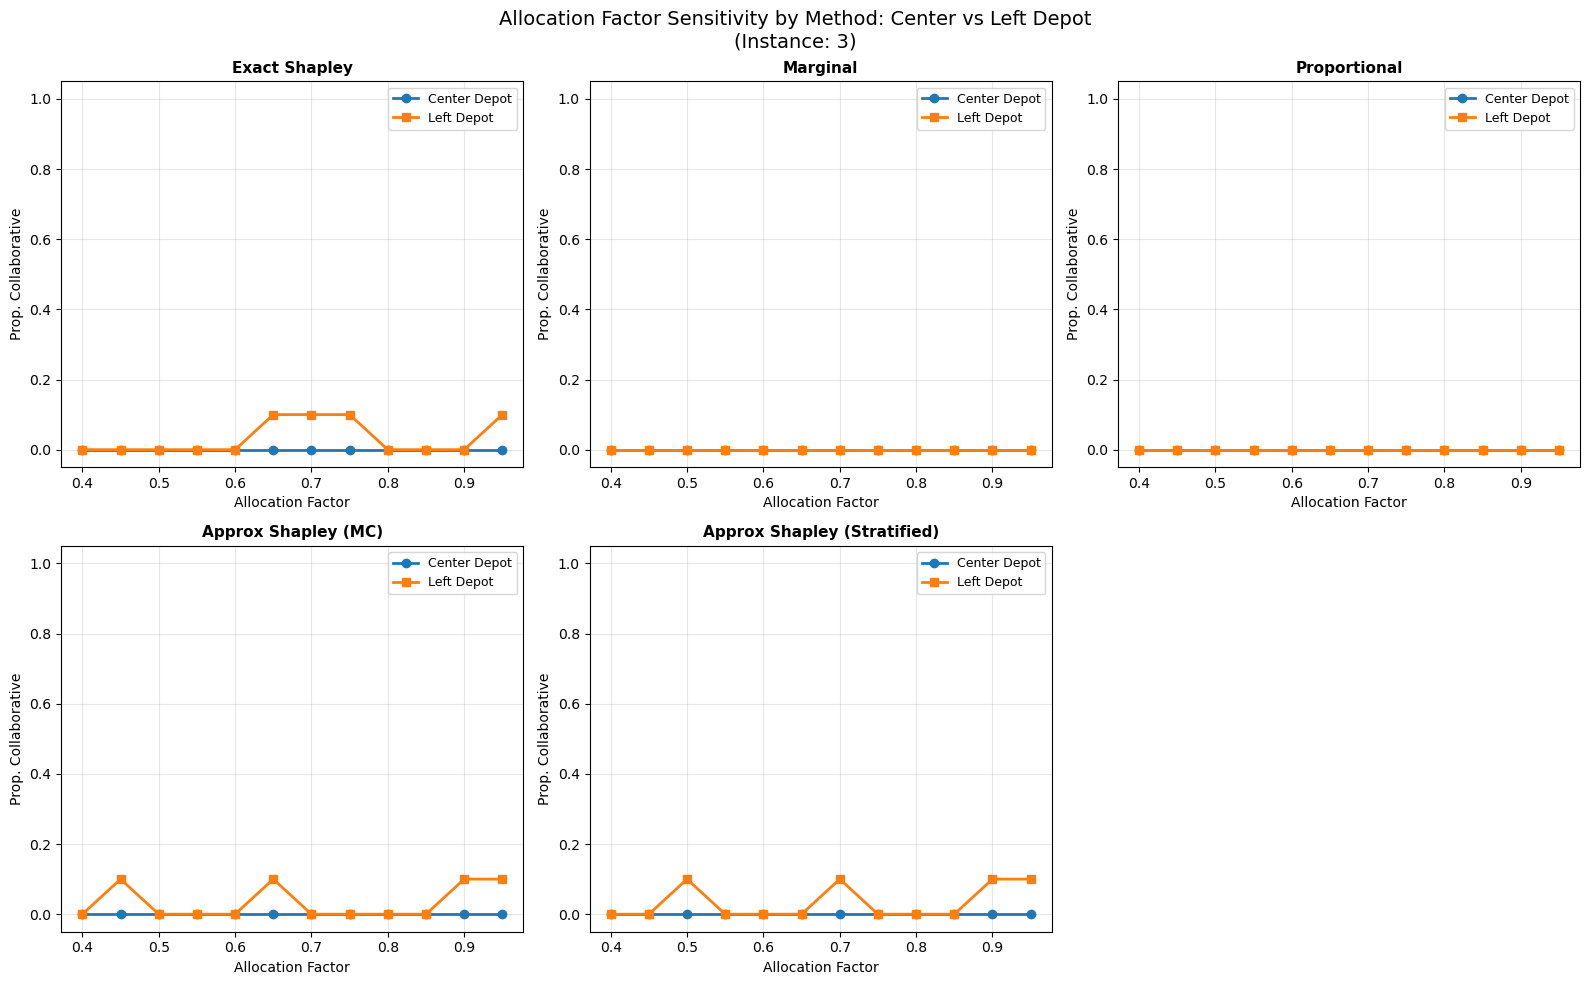

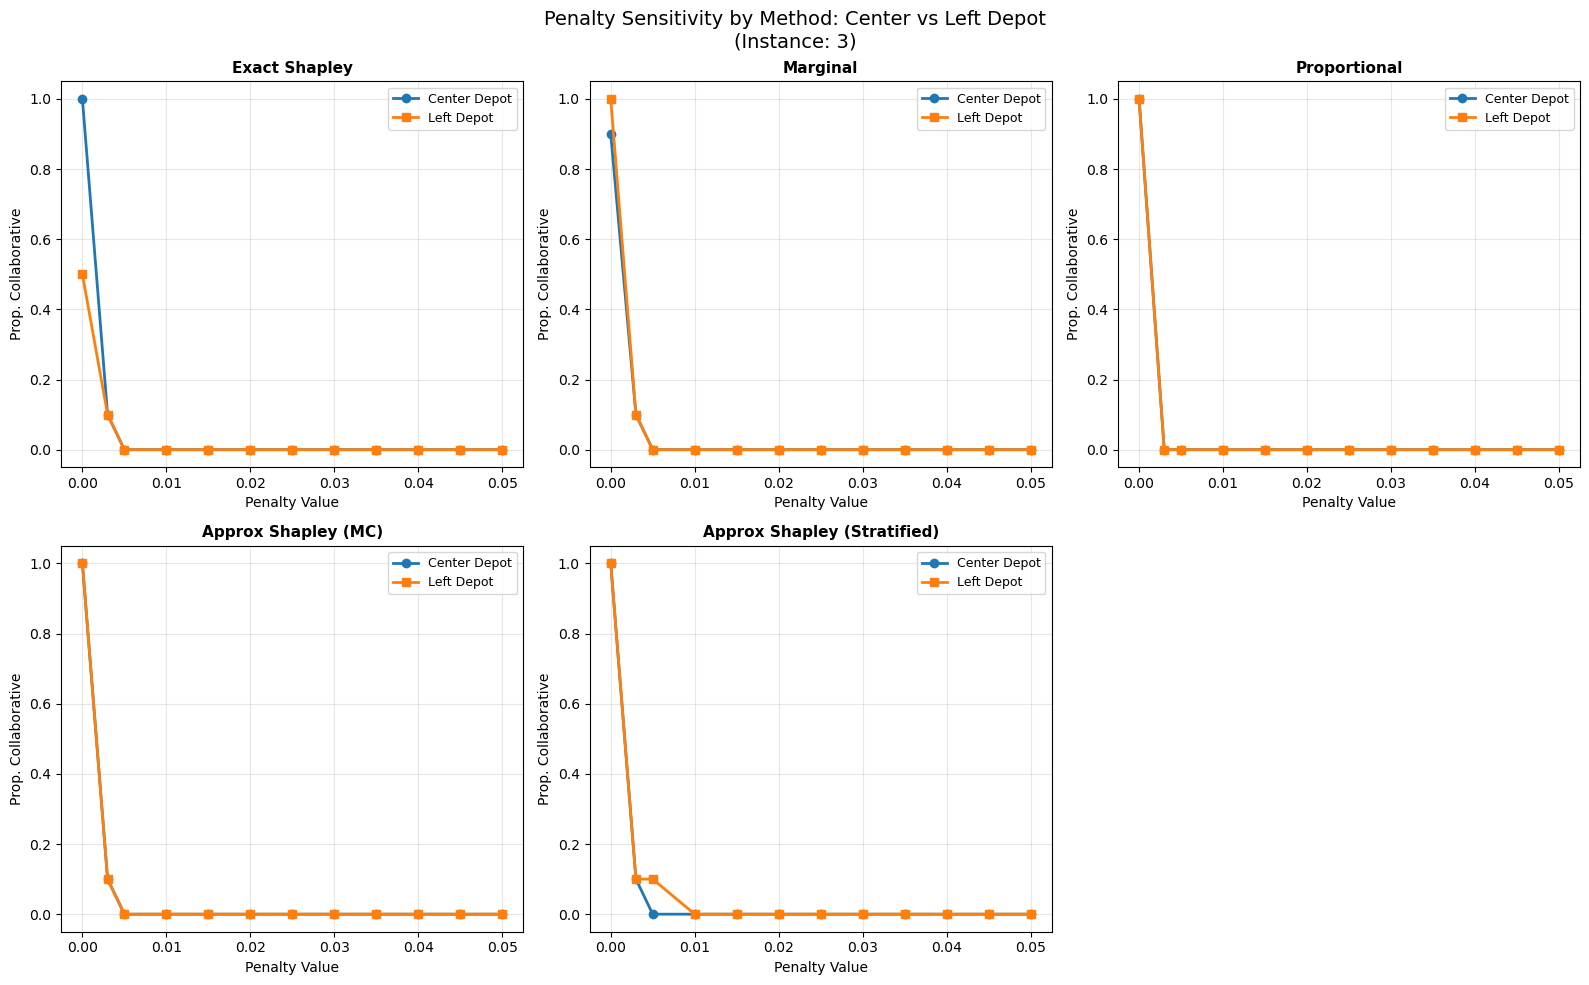

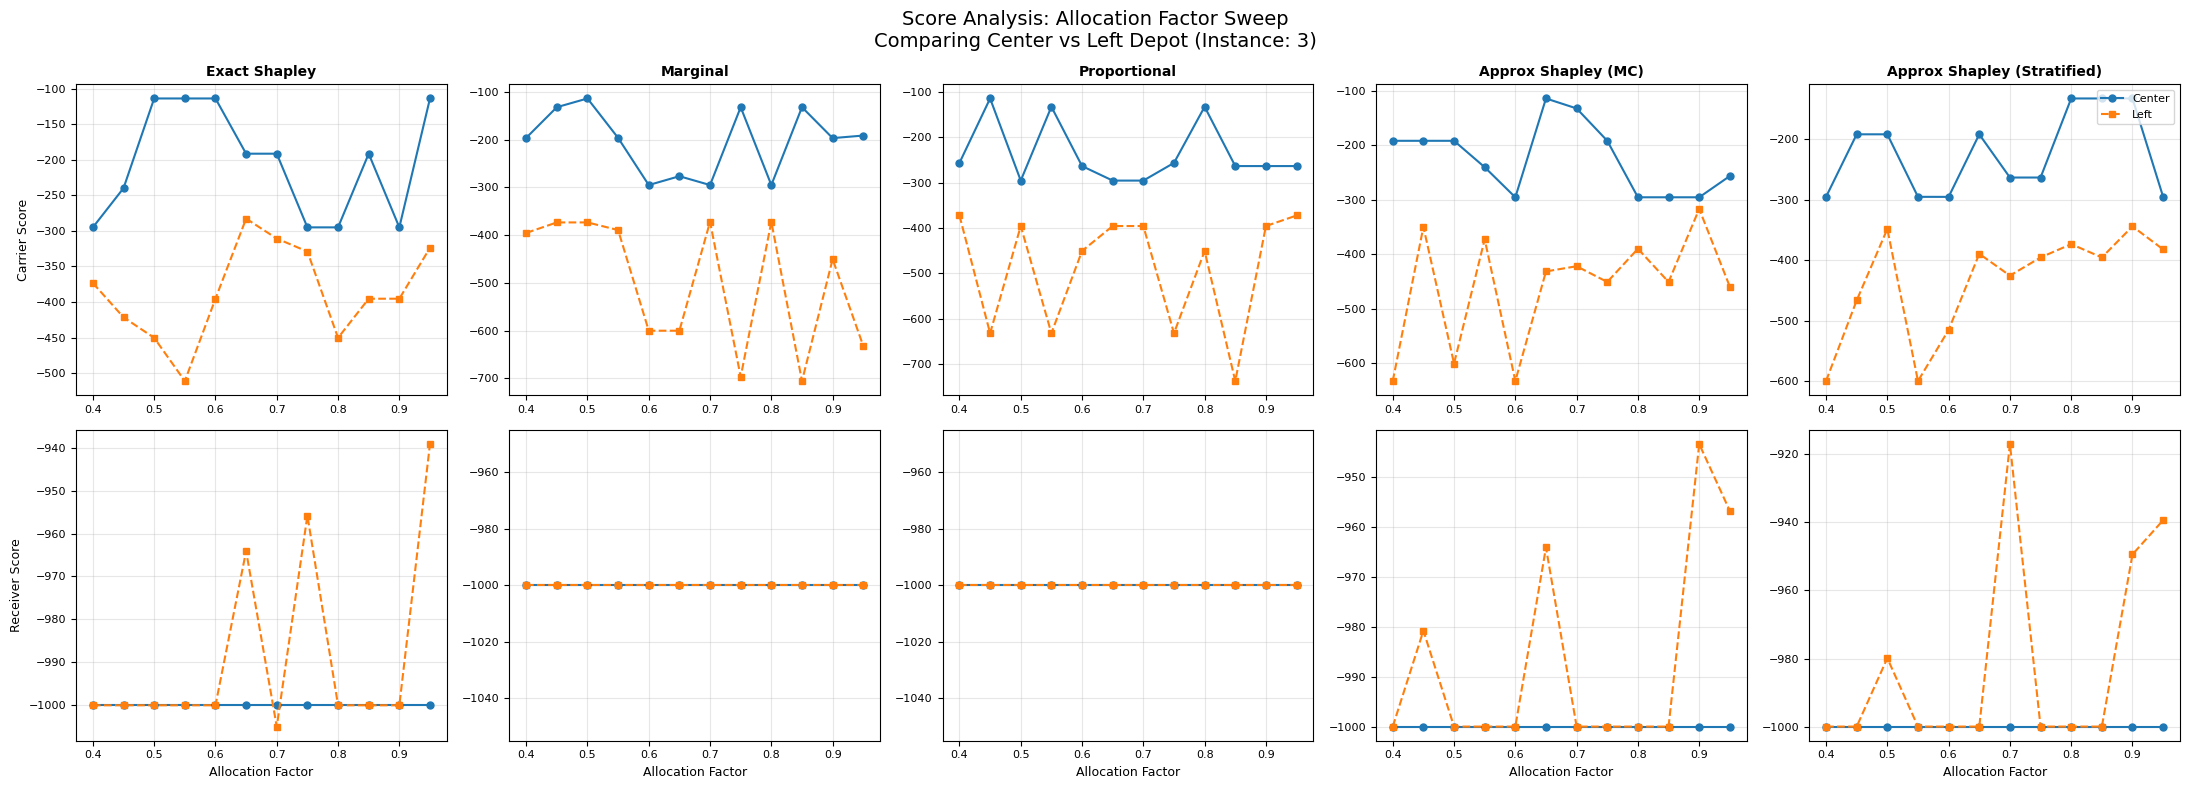

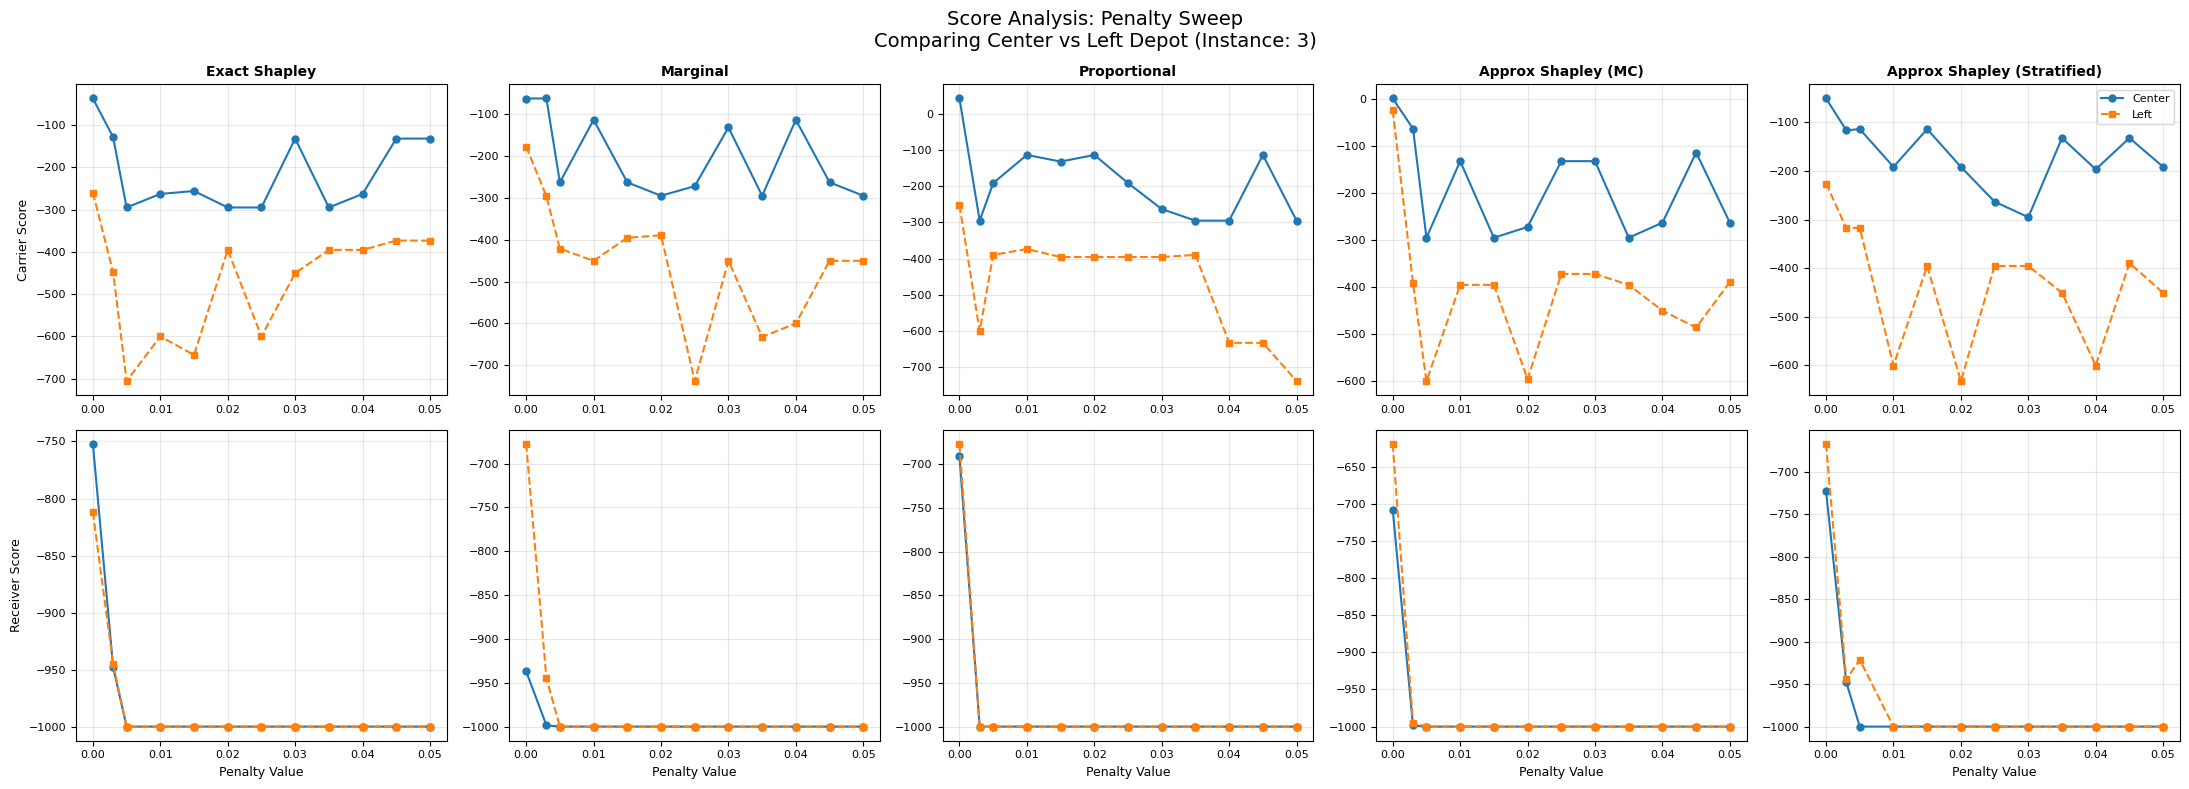

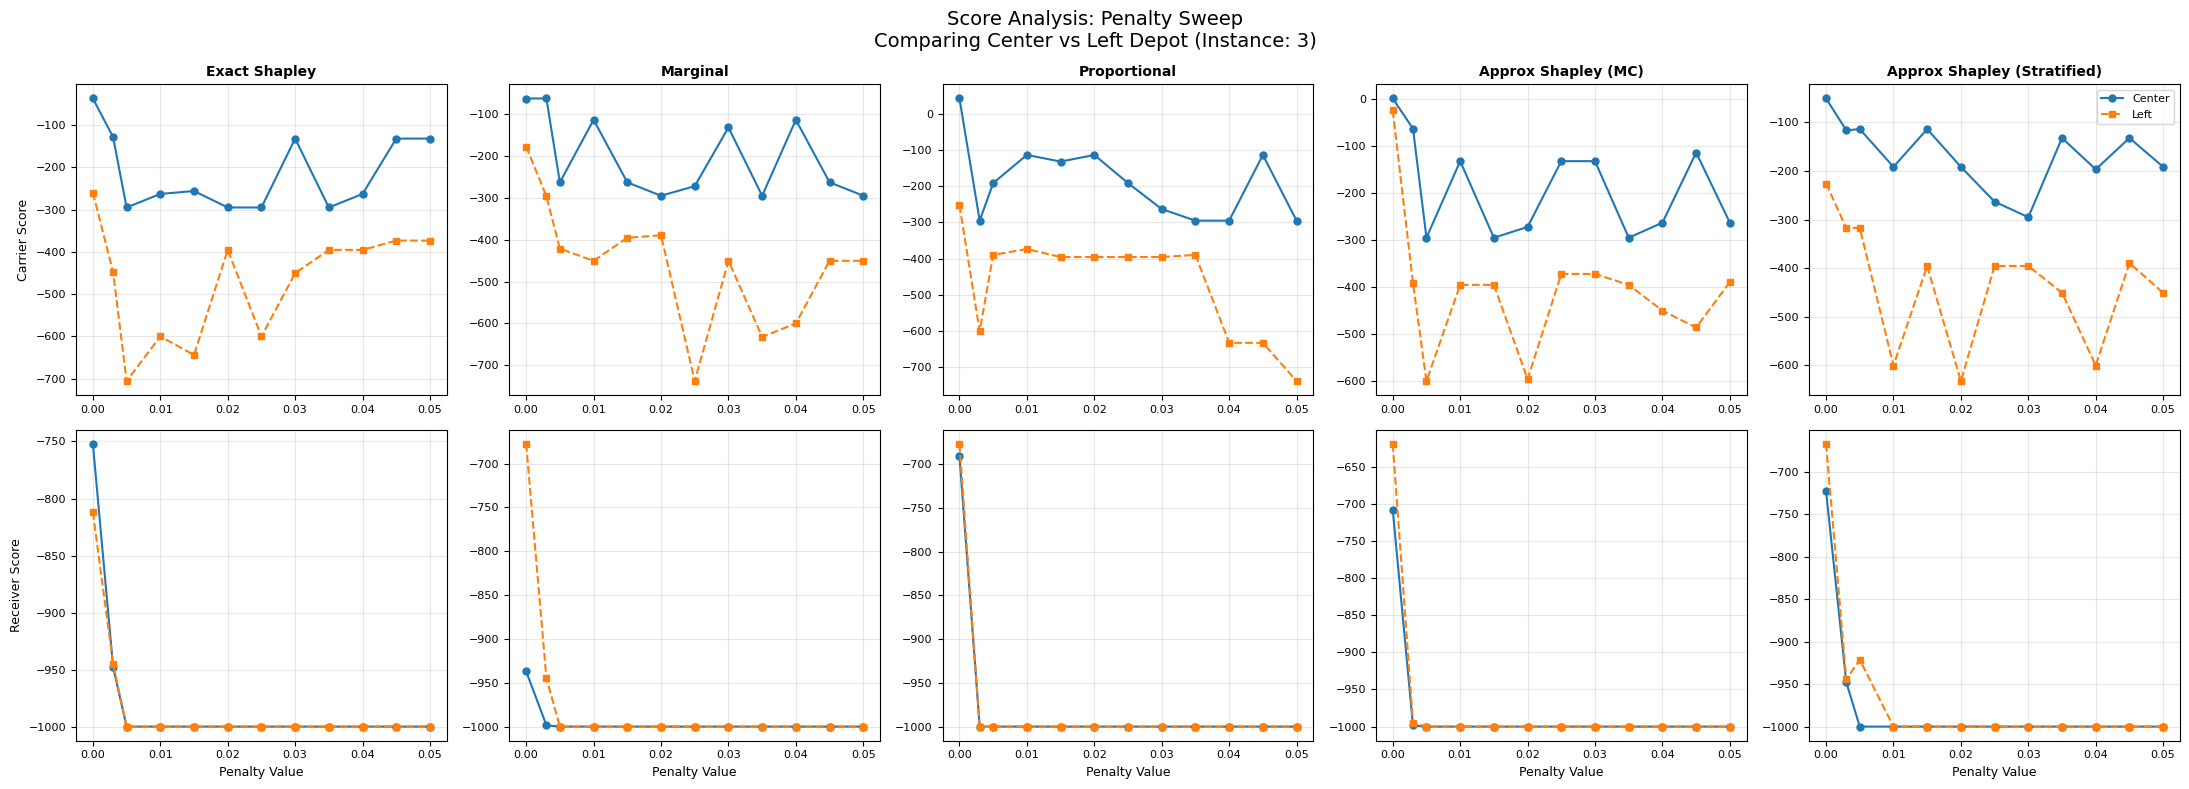

In [67]:
ins = 3
# 分析 instance i00 的 allocation sweep
plot_chessboard_alloc_sweep_by_method_single_instance(chessboard_raw_df, instance=ins)

# 分析 instance i02 的 penalty sweep
plot_chessboard_pen_sweep_by_method_single_instance(chessboard_raw_df, instance=ins)

# 分析 instance i01 的 allocation sweep scores (线图版本)
plot_chessboard_scores_lineplot_single_instance(chessboard_raw_df, sweep_type='alloc', instance=ins)

# 分析 instance i03 的 penalty sweep scores (线图版本)
plot_chessboard_scores_lineplot_single_instance(chessboard_raw_df, sweep_type='pen', instance=ins)

### Summary Statistics

In [27]:
# Summary statistics: Compare center vs left depot overall
summary_stats = chessboard_agg_df.groupby(['depot', 'sweep_type', 'method']).agg({
    'prop_collaborative_mean': ['mean', 'std', 'min', 'max'],
    'combined_score_mean': ['mean', 'std', 'min', 'max'],
    'n_instances': 'mean'
}).round(4)

print("Summary Statistics by Depot, Sweep Type, and Method:")
summary_stats

Summary Statistics by Depot, Sweep Type, and Method:


prop_collaborative_mean                    \
                                                  mean     std  min  max   
depot  sweep_type method                                                   
center penSweep   exactShapley                  0.1861  0.2344  0.0  0.8   
left   penSweep   exactShapley                  0.1971  0.2281  0.0  0.8   

                               combined_score_mean                \
                                              mean           std   
depot  sweep_type method                                           
center penSweep   exactShapley           -331.0339  8.561300e+01   
left   penSweep   exactShapley        -571806.6160  3.380574e+06   

                                                       n_instances  
                                         min       max        mean  
depot  sweep_type method                                            
center penSweep   exactShapley -4.376071e+02  -99.6928     33.9444  
left   penSweep   exactShapley -2.000013e+07 -161.4288     34.8857

In [ ]:
# Check instance coverage: Verify each scenario has expected number of instances
instance_coverage = chessboard_raw_df.groupby(['depot', 'sweep_type', 'af', 'penalty', 'method']).size().reset_index(name='n_instances')
incomplete = instance_coverage[instance_coverage['n_instances'] < 5]

if len(incomplete) > 0:
    print(f"Warning: {len(incomplete)} scenarios have fewer than 5 instances:")
    print(incomplete)
else:
    print("All scenarios have complete instance coverage (5 instances each)")
    
# Show distribution of instance counts
print(f"\nInstance count distribution:")
print(instance_coverage['n_instances'].value_counts().sort_index())

### Chessboard box plot

In [28]:
chessboard_raw_df

,folder,depot,customer_distribution_type,sweep_type,af,penalty,method,instance,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,center-CLUSTERED-penSweep-af0.80-p0.0003-exact...,center,CLUSTERED,penSweep,0.8,0.0003,exactShapley,23,6,4,10,0.6,-686.218115,688.000174,1.782059
1,left-CLUSTERED-penSweep-af0.80-p0.0222-exactSh...,left,CLUSTERED,penSweep,0.8,0.0222,exactShapley,3,0,10,10,0.0,-1000.000000,562.376000,-437.624000
2,left-DISPERSED-penSweep-af0.80-p0.0003-exactSh...,left,DISPERSED,penSweep,0.8,0.0003,exactShapley,27,7,3,10,0.7,-852.591046,537.253489,-315.337558
3,center-DISPERSED-penSweep-af0.80-p0.0222-exact...,center,DISPERSED,penSweep,0.8,0.0222,exactShapley,7,0,10,10,0.0,-1000.000000,557.016000,-442.984000
4,center-CLUSTERED-penSweep-af0.80-p0.0098-exact...,center,CLUSTERED,penSweep,0.8,0.0098,exactShapley,4,1,9,10,0.1,-936.749815,612.737099,-324.012717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438,left-CLUSTERED-penSweep-af0.80-p0.0028-exactSh...,left,CLUSTERED,penSweep,0.8,0.0028,exactShapley,43,1,9,10,0.1,-999.834222,546.137128,-453.697094
2439,left-DISPERSED-penSweep-af0.80-p0.0056-exactSh...,left,DISPERSED,penSweep,0.8,0.0056,exactShapley,14,2,8,10,0.2,-883.866050,565.470543,-318.395507
2440,center-CLUSTERED-penSweep-af0.80-p0.0140-exact...,center,CLUSTERED,penSweep,0.8,0.0140,exactShapley,5,0,10,10,0.0,-1000.000000,581.017000,-418.983000
2441,center-FULLY_RANDOM-penSweep-af0.80-p0.0028-ex...,center,FULLY_RANDOM,penSweep,0.8,0.0028,exactShapley,0,2,8,10,0.2,-940.390845,582.833740,-357.557104


In [29]:
single_scenario_df = chessboard_raw_df.pivot_table(index=['depot', 
                                                          'customer_distribution_type',
                                                          'sweep_type', 
                                                          'af', 
                                                          'penalty', 
                                                          'method'], 
                              columns='instance', 
                              values='prop_collaborative')
single_scenario_df

instance                                                                0   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.1   
                                                 0.0006  exactShapley  0.1   
                                                 0.0008  exactShapley  0.1   
                                                 0.0014  exactShapley  0.1   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.2   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  0.3   
                                                 0.0280  exactShapley  0.0   

instance                                                                1   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.9   
                                                 0.0003  exactShapley  0.7   
                                                 0.0006  exactShapley  0.6   
                                                 0.0008  exactShapley  0.7   
                                                 0.0014  exactShapley  0.3   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.1   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  NaN   
                                                 0.0280  exactShapley  0.0   

instance                                                                2   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  1.0   
                                                 0.0003  exactShapley  0.4   
                                                 0.0006  exactShapley  0.4   
                                                 0.0008  exactShapley  0.2   
                                                 0.0014  exactShapley  0.3   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.0   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  NaN   
                                                 0.0280  exactShapley  0.0   

instance                                                                3   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.4   
                                                 0.0006  exactShapley  0.2   
                                                 0.0008  exactShapley  0.2   
                                                 0.0014  exactShapley  0.2   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.2   
                                                 0.0098  exactShapley  0.1   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  NaN   
                   

In [47]:
# Get the instance id for "('center', 'CLUSTERED', 'penSweep', np.float64(0.8), np.float64(0.0008), 'exactShapley')" which has value <=0.1
test_center_dispersed_row = single_scenario_df.loc[('center', 'DISPERSED', 'penSweep', np.float64(0.8), np.float64(0.0008), 'exactShapley')]
to_filter_instances = list((test_center_dispersed_row[test_center_dispersed_row <= 0.1]).to_dict().keys())
to_filter_instances

[20, 23, 26, 29, 31]

In [48]:
# get rid of columns/isntances in the to_filter_instances list
filtered_single_scenario_df = single_scenario_df.drop(columns=to_filter_instances)
filtered_single_scenario_df

instance                                                                0   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.1   
                                                 0.0006  exactShapley  0.1   
                                                 0.0008  exactShapley  0.1   
                                                 0.0014  exactShapley  0.1   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.2   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  0.3   
                                                 0.0280  exactShapley  0.0   

instance                                                                1   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.9   
                                                 0.0003  exactShapley  0.7   
                                                 0.0006  exactShapley  0.6   
                                                 0.0008  exactShapley  0.7   
                                                 0.0014  exactShapley  0.3   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.1   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  NaN   
                                                 0.0280  exactShapley  0.0   

instance                                                                2   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  1.0   
                                                 0.0003  exactShapley  0.4   
                                                 0.0006  exactShapley  0.4   
                                                 0.0008  exactShapley  0.2   
                                                 0.0014  exactShapley  0.3   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.0   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  NaN   
                                                 0.0280  exactShapley  0.0   

instance                                                                3   \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.4   
                                                 0.0006  exactShapley  0.2   
                                                 0.0008  exactShapley  0.2   
                                                 0.0014  exactShapley  0.2   
...                                                                    ...   
left   FULLY_RANDOM               penSweep   0.8 0.0056  exactShapley  0.2   
                                                 0.0098  exactShapley  0.1   
                                                 0.0140  exactShapley  0.0   
                                                 0.0167  exactShapley  NaN   
                   

In [30]:
def plot_single_scenario_boxplot(pivot_df, depot='center', customer_distribution_type=None,
                                 sweep_type=None, x='af', penalty_filter=None,
                                 af_filter=None, methods=None, output_path=None):
    """
    Plot boxplots of prop_collaborative using the pivoted single_scenario_df.

    Parameters
    ----------
    pivot_df : pandas.DataFrame
        Output from pivot_table with index ['depot','customer_distribution_type','sweep_type','af','penalty','method']
        and columns as instances.
    depot : str
        'center' or 'left'.
    customer_distribution_type : str
        Required. For example: 'FULLY_RANDOM', 'CLUSTERED', 'DISPERSED'.
    sweep_type : str, optional
        'allocSweep' or 'penSweep'. If None, no sweep filtering.
    x : str
        'af' or 'penalty' for x-axis.
    penalty_filter : float or list, optional
        Filter by penalty value(s).
    af_filter : float or list, optional
        Filter by allocation factor value(s).
    methods : list, optional
        Filter by allocation methods.
    output_path : str, optional
        Save figure to this path if provided.
    """
    if depot not in ['center', 'left']:
        raise ValueError("depot must be 'center' or 'left'")
    if customer_distribution_type is None:
        raise ValueError("customer_distribution_type is required")
    if x not in ['af', 'penalty']:
        raise ValueError("x must be 'af' or 'penalty'")

    df = pivot_df.reset_index()
    df_long = df.melt(
        id_vars=['depot', 'customer_distribution_type', 'sweep_type', 'af', 'penalty', 'method'],
        var_name='instance',
        value_name='prop_collaborative'
    )

    # Filters
    df_long = df_long[df_long['depot'] == depot]
    df_long = df_long[df_long['customer_distribution_type'] == customer_distribution_type]
    if sweep_type is not None:
        df_long = df_long[df_long['sweep_type'] == sweep_type]
    if penalty_filter is not None:
        penalty_vals = penalty_filter if isinstance(penalty_filter, (list, tuple, set)) else [penalty_filter]
        df_long = df_long[df_long['penalty'].isin(penalty_vals)]
    if af_filter is not None:
        af_vals = af_filter if isinstance(af_filter, (list, tuple, set)) else [af_filter]
        df_long = df_long[df_long['af'].isin(af_vals)]
    if methods is not None:
        df_long = df_long[df_long['method'].isin(methods)]

    if df_long.empty:
        raise ValueError("No data left after filtering. Check your filters.")

    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(data=df_long, x=x, y='prop_collaborative', hue='method')
    ax.set_xlabel('Allocation Factor' if x == 'af' else 'Penalty Value')
    ax.set_ylabel('Proportion of Collaborative Receivers')
    title_parts = [f"Depot: {depot}", f"Distribution: {customer_distribution_type}"]
    if sweep_type:
        title_parts.append(f"Sweep: {sweep_type}")
    ax.set_title(" | ".join(title_parts))
    ax.grid(True, axis='y', alpha=0.3)
    plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    if output_path:
        filename = f"single_scenario_boxplot_{depot}_{customer_distribution_type}_{x}.png".replace(" ", "_")
        plt.savefig(os.path.join(output_path, filename), dpi=150, bbox_inches='tight')
    plt.show()
    return ax

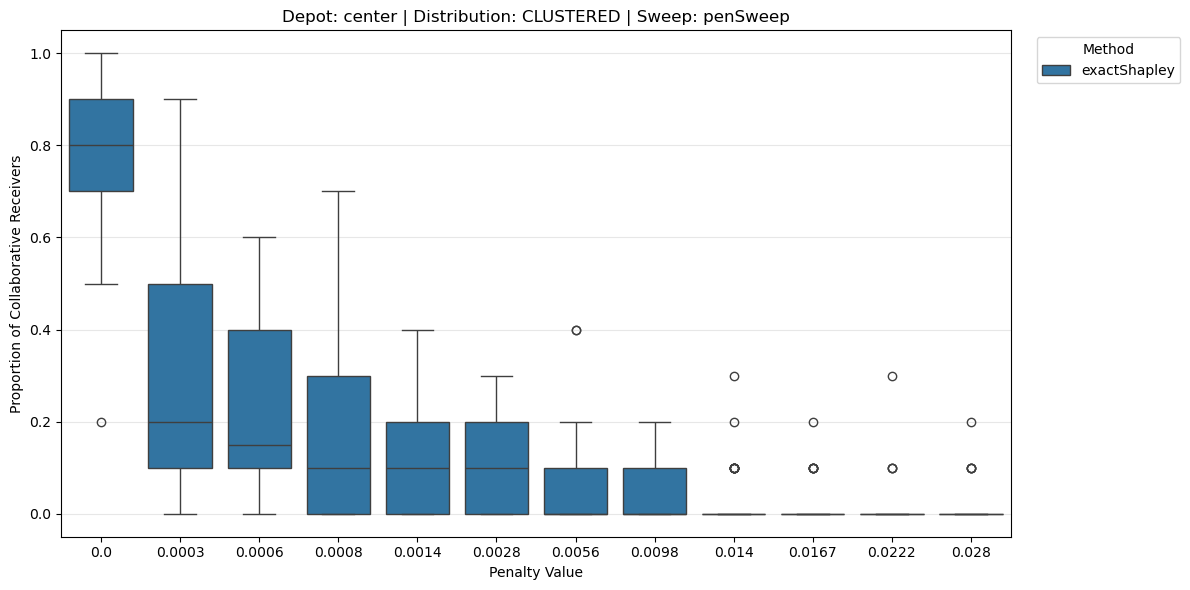

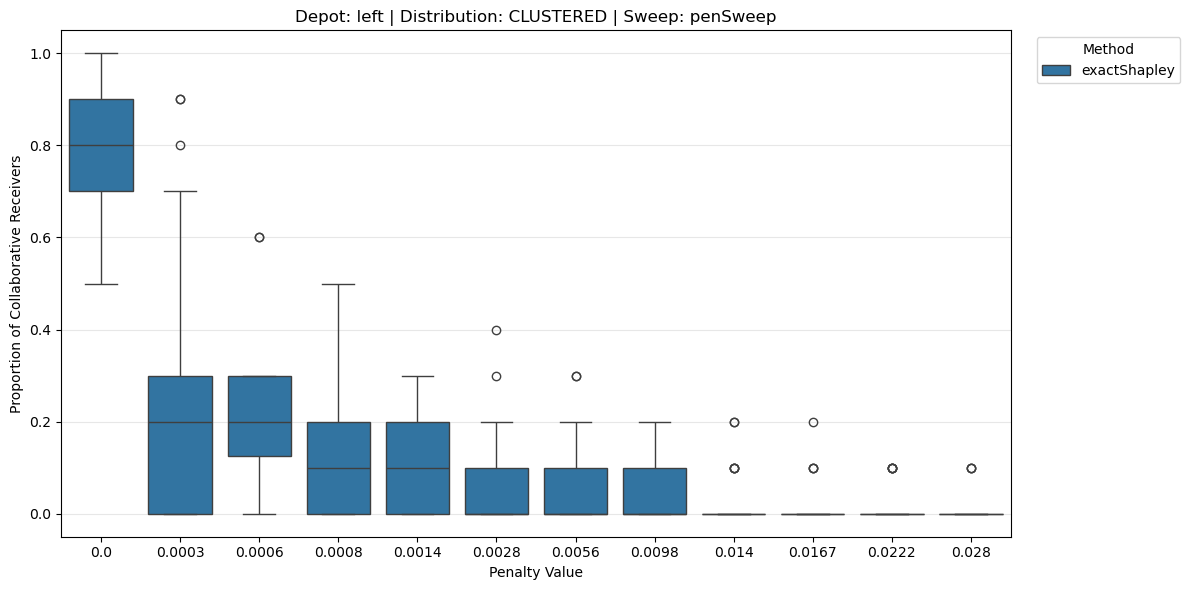

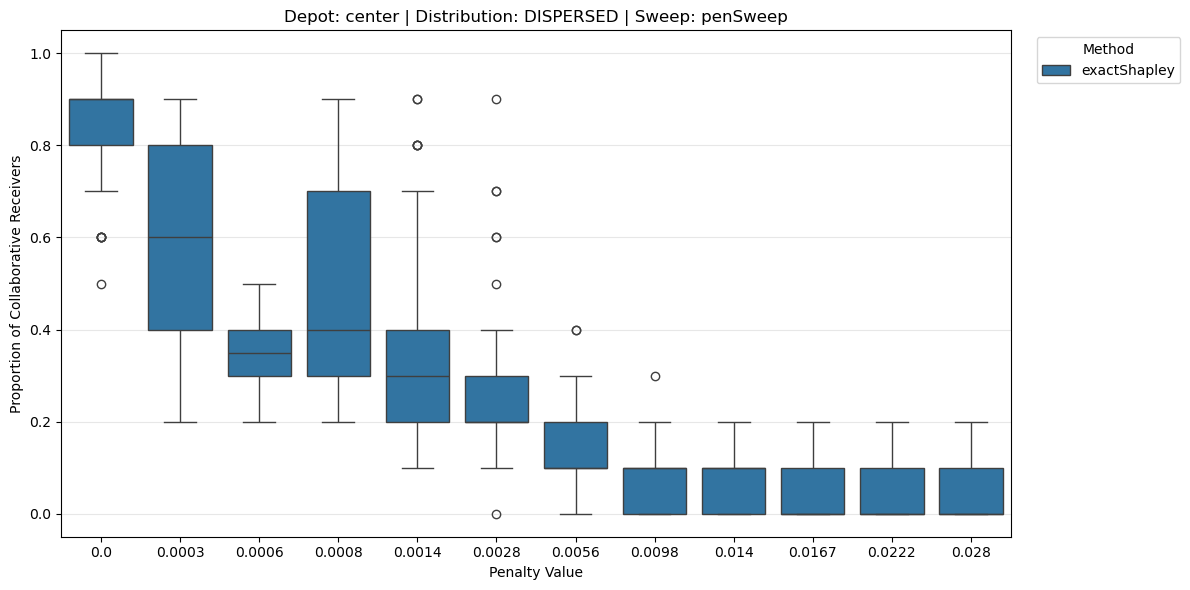

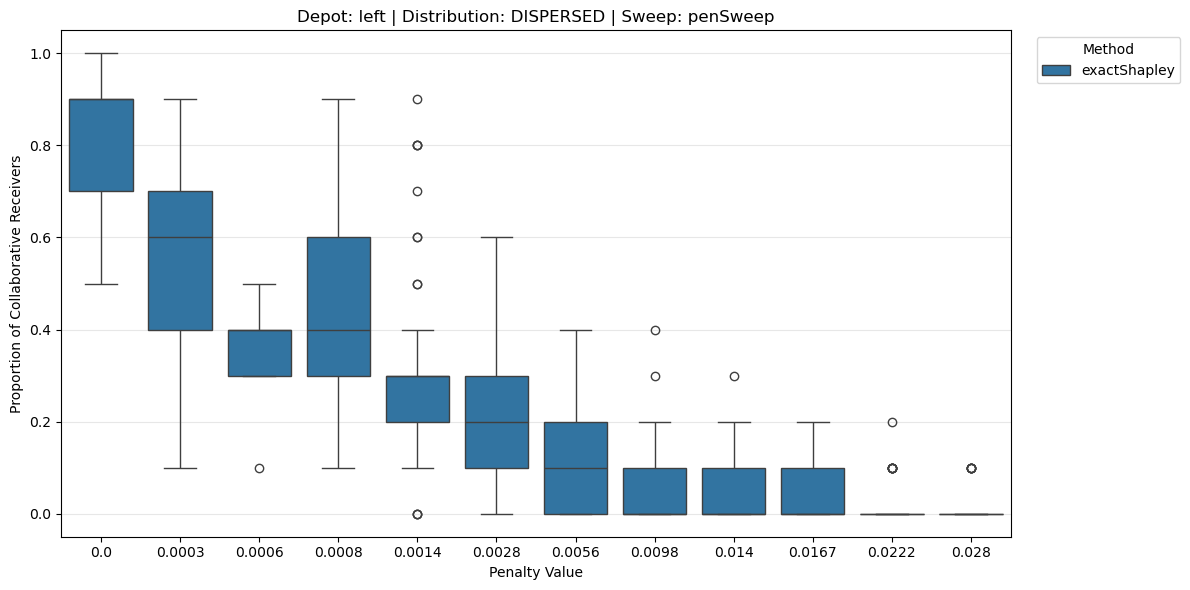

<Axes: title={'center': 'Depot: left | Distribution: DISPERSED | Sweep: penSweep'}, xlabel='Penalty Value', ylabel='Proportion of Collaborative Receivers'>

In [49]:
to_plot_single_scenario_df = filtered_single_scenario_df.copy()

plot_single_scenario_boxplot(to_plot_single_scenario_df, 
                             depot='center',
                             customer_distribution_type='CLUSTERED',
                             sweep_type='penSweep',
                             x='penalty')

plot_single_scenario_boxplot(to_plot_single_scenario_df, 
                             depot='left',
                             customer_distribution_type='CLUSTERED',
                             sweep_type='penSweep',
                             x='penalty')

plot_single_scenario_boxplot(to_plot_single_scenario_df, 
                             depot='center',
                             customer_distribution_type='DISPERSED',
                             sweep_type='penSweep',
                             x='penalty')

plot_single_scenario_boxplot(to_plot_single_scenario_df, 
                             depot='left',
                             customer_distribution_type='DISPERSED',
                             sweep_type='penSweep',
                             x='penalty')

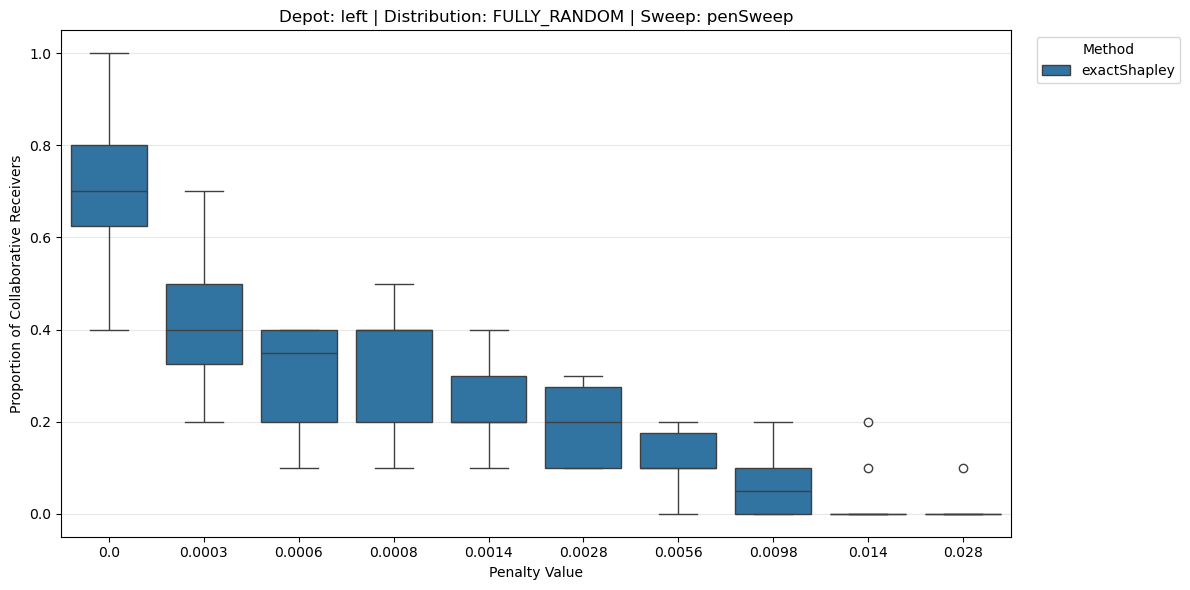

<Axes: title={'center': 'Depot: left | Distribution: FULLY_RANDOM | Sweep: penSweep'}, xlabel='Penalty Value', ylabel='Proportion of Collaborative Receivers'>

In [ ]:
plot_single_scenario_boxplot(
    single_scenario_df, 
    depot='center',
    customer_distribution_type='FULLY_RANDOM',
    sweep_type='allocSweep', x='af') 



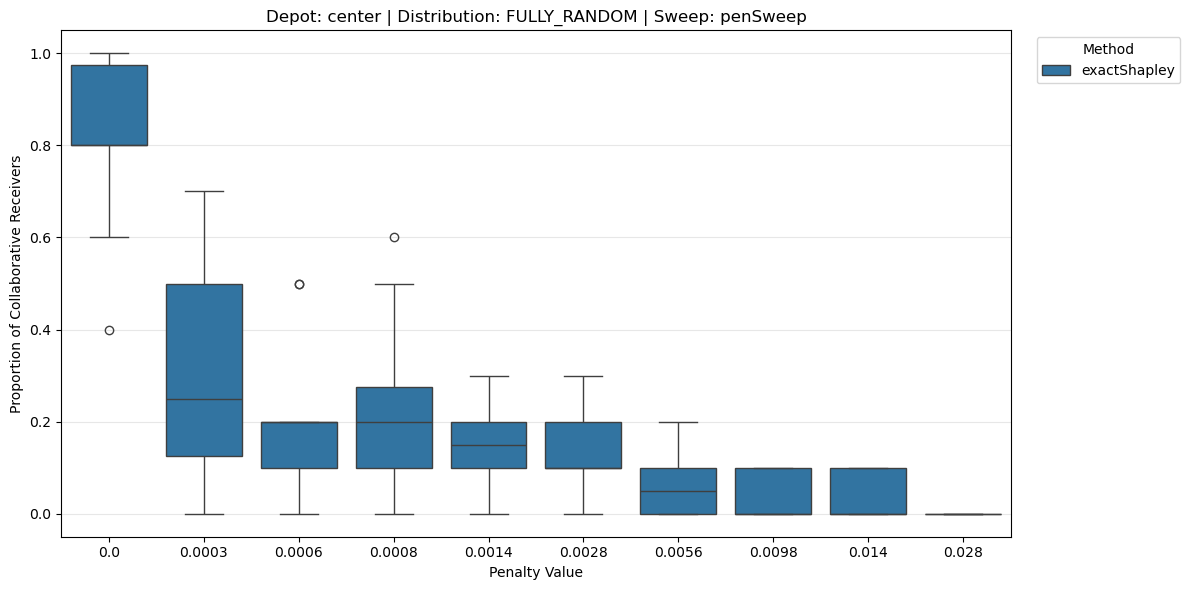

<Axes: title={'center': 'Depot: center | Distribution: FULLY_RANDOM | Sweep: penSweep'}, xlabel='Penalty Value', ylabel='Proportion of Collaborative Receivers'>

In [25]:
plot_single_scenario_boxplot(single_scenario_df, 
                             depot='center',
                             customer_distribution_type='FULLY_RANDOM',
                             sweep_type='penSweep',
                             x='penalty')

In [28]:
single_scenario_df

instance                                                                 0  \
depot  customer_distribution_type sweep_type af  penalty method              
center CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.1   
                                                 0.0006  exactShapley  0.1   
                                                 0.0008  exactShapley  0.1   
                                                 0.0014  exactShapley  0.1   
                                                 0.0028  exactShapley  0.1   
                                                 0.0056  exactShapley  0.1   
                                                 0.0098  exactShapley  0.1   
                                                 0.0140  exactShapley  0.1   
                                                 0.0280  exactShapley  0.0   
       DISPERSED                  penSweep   0.8 0.0000  exactShapley  0.9   
                                                 0.0003  exactShapley  0.4   
                                                 0.0006  exactShapley  0.5   
                                                 0.0008  exactShapley  0.5   
                                                 0.0014  exactShapley  0.4   
                                                 0.0028  exactShapley  0.1   
                                                 0.0056  exactShapley  0.2   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                                                 0.0280  exactShapley  0.0   
       FULLY_RANDOM               penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.2   
                                                 0.0006  exactShapley  0.2   
                                                 0.0008  exactShapley  0.2   
                                                 0.0014  exactShapley  0.2   
                                                 0.0028  exactShapley  0.2   
                                                 0.0056  exactShapley  0.2   
                                                 0.0098  exactShapley  0.1   
                                                 0.0140  exactShapley  0.1   
                                                 0.0280  exactShapley  0.0   
left   CLUSTERED                  penSweep   0.8 0.0000  exactShapley  0.7   
                                                 0.0003  exactShapley  0.1   
                                                 0.0006  exactShapley  0.1   
                                                 0.0008  exactShapley  0.2   
                                                 0.0014  exactShapley  0.1   
                                                 0.0028  exactShapley  0.0   
                                                 0.0056  exactShapley  0.1   
                                                 0.0098  exactShapley  0.1   
                                                 0.0140  exactShapley  0.0   
                                                 0.0280  exactShapley  0.0   
       DISPERSED                  penSweep   0.8 0.0000  exactShapley  0.8   
                                                 0.0003  exactShapley  0.4   
                                                 0.0006  exactShapley  0.5   
                                                 0.0008  exactShapley  0.3   
                                                 0.0014  exactShapley  0.3   
                                                 0.0028  exactShapley  0.1   
                                                 0.0056  exactShapley  0.0   
                                                 0.0098  exactShapley  0.0   
                                                 0.0140  exactShapley  0.0   
                      

# Read receivers and carriers locations 

In [29]:
# ============================================================================
# Network Visualization Functions
# ============================================================================

def read_receiver_locations(receiver_file_path):
    """
    Read receiver locations (linkId) from a receivers.xml.gz file.
    
    Parameters:
    -----------
    receiver_file_path : str
        Path to the receivers.xml.gz file
    
    Returns:
    --------
    dict : Dictionary with receiver_id as key and linkId as value
    """
    from lxml import etree
    import gzip
    
    receiver_locations = {}
    
    with gzip.open(receiver_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    for receiver in root.findall('.//receiver'):
        receiver_id = receiver.get('id')
        link_id = receiver.get('linkId')
        receiver_locations[receiver_id] = link_id
    
    return receiver_locations


def read_carrier_depot_locations(carrier_file_path):
    """
    Read carrier depot locations (depotLinkId) from a carriers.xml.gz file.
    
    Parameters:
    -----------
    carrier_file_path : str
        Path to the carriers.xml.gz file
    
    Returns:
    --------
    dict : Dictionary with carrier_id as key and a set of depot linkIds as value
    """
    from lxml import etree
    import gzip
    
    carrier_depots = {}
    
    with gzip.open(carrier_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    # Handle namespace
    ns = {'': 'http://www.matsim.org/files/dtd'}
    
    for carrier in root.findall('.//{http://www.matsim.org/files/dtd}carrier'):
        carrier_id = carrier.get('id')
        depot_links = set()
        
        for vehicle in carrier.findall('.//{http://www.matsim.org/files/dtd}vehicle'):
            depot_link_id = vehicle.get('depotLinkId')
            if depot_link_id:
                depot_links.add(depot_link_id)
        
        carrier_depots[carrier_id] = depot_links
    
    return carrier_depots


def read_network(network_file_path):
    """
    Read network from a network.xml.gz file.
    
    Parameters:
    -----------
    network_file_path : str
        Path to the output_network.xml.gz file
    
    Returns:
    --------
    tuple : (nodes_df, links_df)
        - nodes_df: DataFrame with columns ['node_id', 'x', 'y']
        - links_df: DataFrame with columns ['link_id', 'from_node', 'to_node', 'length']
    """
    from lxml import etree
    import gzip
    
    with gzip.open(network_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    # Parse nodes
    nodes_data = []
    for node in root.findall('.//node'):
        node_id = node.get('id')
        x = float(node.get('x'))
        y = float(node.get('y'))
        nodes_data.append({'node_id': node_id, 'x': x, 'y': y})
    
    nodes_df = pd.DataFrame(nodes_data)
    
    # Parse links
    links_data = []
    for link in root.findall('.//link'):
        link_id = link.get('id')
        from_node = link.get('from')
        to_node = link.get('to')
        length = float(link.get('length'))
        links_data.append({
            'link_id': link_id, 
            'from_node': from_node, 
            'to_node': to_node, 
            'length': length
        })
    
    links_df = pd.DataFrame(links_data)
    
    return nodes_df, links_df


def get_link_coordinates(link_id, nodes_df, links_df):
    """
    Get the midpoint coordinates of a link.
    
    Parameters:
    -----------
    link_id : str
        The link ID
    nodes_df : DataFrame
        Nodes DataFrame from read_network()
    links_df : DataFrame
        Links DataFrame from read_network()
    
    Returns:
    --------
    tuple : (x, y) coordinates of the link's midpoint, or None if not found
    """
    link_row = links_df[links_df['link_id'] == link_id]
    if link_row.empty:
        return None
    
    from_node = link_row.iloc[0]['from_node']
    to_node = link_row.iloc[0]['to_node']
    
    from_coords = nodes_df[nodes_df['node_id'] == from_node]
    to_coords = nodes_df[nodes_df['node_id'] == to_node]
    
    if from_coords.empty or to_coords.empty:
        return None
    
    x = (from_coords.iloc[0]['x'] + to_coords.iloc[0]['x']) / 2
    y = (from_coords.iloc[0]['y'] + to_coords.iloc[0]['y']) / 2
    
    return (x, y)


def collect_location_data_for_instance(output_path, folder_name):
    """
    Collect receiver locations, carrier depot locations, and network data for a single instance.
    
    Parameters:
    -----------
    output_path : str
        Base output path (e.g., 'output/chessboardCarrierReceiverCollab/')
    folder_name : str
        Folder name of the instance
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'receiver_locations': dict of receiver_id -> linkId
        - 'carrier_depots': dict of carrier_id -> set of depotLinkIds
        - 'nodes_df': DataFrame of network nodes
        - 'links_df': DataFrame of network links
        - 'receiver_coords': dict of receiver_id -> (x, y)
        - 'depot_coords': dict of carrier_id -> list of (x, y)
    """
    folder_path = os.path.join(output_path, folder_name)
    
    receiver_file = os.path.join(folder_path, 'receivers.xml.gz')
    carrier_file = os.path.join(folder_path, 'carriers.xml.gz')
    network_file = os.path.join(folder_path, 'output_network.xml.gz')
    
    # Read data
    receiver_locations = read_receiver_locations(receiver_file)
    carrier_depots = read_carrier_depot_locations(carrier_file)
    nodes_df, links_df = read_network(network_file)
    
    # Get coordinates for receivers
    receiver_coords = {}
    for rec_id, link_id in receiver_locations.items():
        coords = get_link_coordinates(link_id, nodes_df, links_df)
        if coords:
            receiver_coords[rec_id] = coords
    
    # Get coordinates for depots
    depot_coords = {}
    for carrier_id, depot_links in carrier_depots.items():
        depot_coords[carrier_id] = []
        for link_id in depot_links:
            coords = get_link_coordinates(link_id, nodes_df, links_df)
            if coords:
                depot_coords[carrier_id].append(coords)
    
    return {
        'receiver_locations': receiver_locations,
        'carrier_depots': carrier_depots,
        'nodes_df': nodes_df,
        'links_df': links_df,
        'receiver_coords': receiver_coords,
        'depot_coords': depot_coords
    }

In [50]:
def plot_network_with_locations(location_data, depot='center', customer_distribution_type='FULLY_RANDOM',
                                 instance=0, title=None, figsize=(12, 12), output_path=None):
    """
    Visualize the network with receiver and depot locations.
    
    Parameters:
    -----------
    location_data : dict
        Output from collect_location_data_for_instance()
    depot : str
        'center' or 'left' - used for title if title is None
    customer_distribution_type : str
        Distribution type - used for title if title is None
    instance : int
        Instance number - used for title if title is None
    title : str, optional
        Custom title for the plot
    figsize : tuple
        Figure size
    output_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    matplotlib.figure.Figure
    """
    nodes_df = location_data['nodes_df']
    links_df = location_data['links_df']
    receiver_coords = location_data['receiver_coords']
    depot_coords = location_data['depot_coords']
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw the central region rectangle with shadow effect
    from matplotlib.patches import Rectangle, FancyBboxPatch
    # Shadow rectangle (slightly offset)
    shadow = FancyBboxPatch((2000 + 50, 2000 - 50), 5000, 5000, 
                             boxstyle="round,pad=0.02", 
                             facecolor='lightblue', alpha=0.15, 
                             edgecolor='None', linestyle='--', 
                             zorder=0)
    ax.add_patch(shadow)
    # Main rectangle for central region
    central_region = Rectangle((2000, 2000), 5000, 5000, 
                                 linewidth=2, edgecolor='#4a90d9', facecolor='#4a90d9', 
                                 alpha=0.08, linestyle='--', zorder=0.5, 
                                 label='Central Region (2000-7000)')
    ax.add_patch(central_region)
    
    # Plot network links as directed arrows
    from matplotlib.patches import FancyArrowPatch
    for _, link in links_df.iterrows():
        from_node = nodes_df[nodes_df['node_id'] == link['from_node']]
        to_node = nodes_df[nodes_df['node_id'] == link['to_node']]
        if not from_node.empty and not to_node.empty:
            x1, y1 = from_node.iloc[0]['x'], from_node.iloc[0]['y']
            x2, y2 = to_node.iloc[0]['x'], to_node.iloc[0]['y']
            arrow = FancyArrowPatch((x1, y1), (x2, y2), 
                                     arrowstyle='->', mutation_scale=8,
                                     color='gray', linewidth=0.8, alpha=0.7,
                                     shrinkA=3, shrinkB=3)
            ax.add_patch(arrow)
    
    # Plot network nodes as small dots
    ax.scatter(nodes_df['x'], nodes_df['y'], c='lightgray', s=10, zorder=1, label='Network Nodes')
    
    # Plot receivers
    if receiver_coords:
        rec_x = [coord[0] for coord in receiver_coords.values()]
        rec_y = [coord[1] for coord in receiver_coords.values()]
        ax.scatter(rec_x, rec_y, c='orange', s=100, marker='o', zorder=3, 
                   label=f'Receivers (n={len(receiver_coords)})', alpha=0.7, edgecolors='darkorange')
    
    # Plot depots
    all_depot_x = []
    all_depot_y = []
    for carrier_id, coords_list in depot_coords.items():
        for coord in coords_list:
            all_depot_x.append(coord[0])
            all_depot_y.append(coord[1])
    
    if all_depot_x:
        ax.scatter(all_depot_x, all_depot_y, c='red', s=200, marker='*', zorder=4, 
                   label=f'Depot(s) (n={len(all_depot_x)})', edgecolors='darkred')
    
    ax.set_xlabel('X Coordinate (m)', fontsize=12)
    ax.set_ylabel('Y Coordinate (m)', fontsize=12)
    
    if title is None:
        title = f'Network Layout: {depot.capitalize()} Depot, {customer_distribution_type} Distribution (Instance {instance})'
    ax.set_title(title, fontsize=14)
    
    ax.legend(loc='upper right', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_path:
        filename = f'network_layout_{depot}_{customer_distribution_type}_i{instance:02d}.png'
        plt.savefig(os.path.join(output_path, filename), dpi=150, bbox_inches='tight')
    
    plt.show()


def compare_network_layouts(output_path, depot='center', customer_distribution_type='FULLY_RANDOM',
                            instances=[0, 1, 2], figsize=(16, 5)):
    """
    Compare network layouts across multiple instances side by side.
    
    Parameters:
    -----------
    output_path : str
        Base output path
    depot : str
        'center' or 'left'
    customer_distribution_type : str
        Distribution type (e.g., 'FULLY_RANDOM', 'CLUSTERED', 'DISPERSED')
    instances : list
        List of instance numbers to compare
    figsize : tuple
        Figure size
    """
    # Find sample folders for each instance
    all_folders = os.listdir(output_path)
    
    fig, axes = plt.subplots(1, len(instances), figsize=figsize)
    if len(instances) == 1:
        axes = [axes]
    
    for idx, inst in enumerate(instances):
        # Find a folder matching the criteria
        pattern = f'{depot}-{customer_distribution_type}-penSweep-'
        matching_folders = [f for f in all_folders if f.startswith(pattern) and f'-i{inst:02d}' in f]
        
        if not matching_folders:
            print(f"No folder found for instance {inst}")
            axes[idx].text(0.5, 0.5, f'No data for i{inst:02d}', ha='center', va='center',
                          transform=axes[idx].transAxes)
            continue
        
        folder_name = matching_folders[0]
        location_data = collect_location_data_for_instance(output_path, folder_name)
        
        ax = axes[idx]
        nodes_df = location_data['nodes_df']
        links_df = location_data['links_df']
        receiver_coords = location_data['receiver_coords']
        depot_coords = location_data['depot_coords']
        
        # Plot network links
        for _, link in links_df.iterrows():
            from_node = nodes_df[nodes_df['node_id'] == link['from_node']]
            to_node = nodes_df[nodes_df['node_id'] == link['to_node']]
            if not from_node.empty and not to_node.empty:
                x_coords = [from_node.iloc[0]['x'], to_node.iloc[0]['x']]
                y_coords = [from_node.iloc[0]['y'], to_node.iloc[0]['y']]
                ax.plot(x_coords, y_coords, 'gray', linewidth=0.5, alpha=0.3)
        
        # Plot nodes
        ax.scatter(nodes_df['x'], nodes_df['y'], c='lightgray', s=5, zorder=1)
        
        # Plot receivers
        if receiver_coords:
            rec_x = [coord[0] for coord in receiver_coords.values()]
            rec_y = [coord[1] for coord in receiver_coords.values()]
            ax.scatter(rec_x, rec_y, c='blue', s=50, marker='o', zorder=3, alpha=0.7, edgecolors='darkblue')
        
        # Plot depots
        for carrier_id, coords_list in depot_coords.items():
            for coord in coords_list:
                ax.scatter(coord[0], coord[1], c='red', s=150, marker='*', zorder=4, edgecolors='darkred')
        
        ax.set_title(f'Instance {inst}', fontsize=12)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'{depot.capitalize()} Depot | {customer_distribution_type} Distribution', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig


def compare_distribution_types(output_path, depot='center', instance=0, figsize=(18, 5)):
    """
    Compare different distribution types for the same depot and instance.
    
    Parameters:
    -----------
    output_path : str
        Base output path
    depot : str
        'center' or 'left'
    instance : int
        Instance number
    figsize : tuple
        Figure size
    """
    distribution_types = ['FULLY_RANDOM', 'CLUSTERED', 'DISPERSED']
    all_folders = os.listdir(output_path)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for idx, dist_type in enumerate(distribution_types):
        pattern = f'{depot}-{dist_type}-penSweep-'
        matching_folders = [f for f in all_folders if f.startswith(pattern) and f'-i{instance:02d}' in f]
        
        if not matching_folders:
            print(f"No folder found for {dist_type}")
            axes[idx].text(0.5, 0.5, f'No data for {dist_type}', ha='center', va='center',
                          transform=axes[idx].transAxes)
            continue
        
        folder_name = matching_folders[0]
        location_data = collect_location_data_for_instance(output_path, folder_name)
        
        ax = axes[idx]
        nodes_df = location_data['nodes_df']
        links_df = location_data['links_df']
        receiver_coords = location_data['receiver_coords']
        depot_coords = location_data['depot_coords']
        
        # Plot network links
        for _, link in links_df.iterrows():
            from_node = nodes_df[nodes_df['node_id'] == link['from_node']]
            to_node = nodes_df[nodes_df['node_id'] == link['to_node']]
            if not from_node.empty and not to_node.empty:
                x_coords = [from_node.iloc[0]['x'], to_node.iloc[0]['x']]
                y_coords = [from_node.iloc[0]['y'], to_node.iloc[0]['y']]
                ax.plot(x_coords, y_coords, 'gray', linewidth=0.5, alpha=0.3)
        
        ax.scatter(nodes_df['x'], nodes_df['y'], c='lightgray', s=5, zorder=1)
        
        if receiver_coords:
            rec_x = [coord[0] for coord in receiver_coords.values()]
            rec_y = [coord[1] for coord in receiver_coords.values()]
            ax.scatter(rec_x, rec_y, c='blue', s=50, marker='o', zorder=3, alpha=0.7, 
                       edgecolors='darkblue', label=f'Receivers (n={len(receiver_coords)})')
        
        for carrier_id, coords_list in depot_coords.items():
            for coord in coords_list:
                ax.scatter(coord[0], coord[1], c='red', s=150, marker='*', zorder=4, 
                          edgecolors='darkred', label='Depot')
        
        ax.set_title(f'{dist_type}', fontsize=12, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)
    
    fig.suptitle(f'{depot.capitalize()} Depot | Instance {instance}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig

In [55]:
def plot_all_instances_receiver_locations(output_path, customer_distribution_type='CLUSTERED', 
                                          figsize=(20, 8), show_network=True):
    """
    Plot receiver locations for all 10 instances (i00-i09) in a single figure with 10 subplots.
    Also shows both depot locations (center and left) in each subplot.
    
    Parameters:
    -----------
    output_path : str
        Base output path (e.g., 'output/chessboardCarrierReceiverCollab/')
    customer_distribution_type : str
        'CLUSTERED', 'DISPERSED', or 'FULLY_RANDOM'
    figsize : tuple
        Figure size (width, height)
    show_network : bool
        Whether to show the network links and nodes
    
    Returns:
    --------
    matplotlib.figure.Figure
    """
    from matplotlib.patches import Rectangle, FancyBboxPatch
    
    fig, axes = plt.subplots(2, 5, figsize=figsize)
    axes = axes.flatten()
    
    all_folders = os.listdir(output_path)
    
    for inst_idx in range(10):
        ax = axes[inst_idx]
        instance_str = f'i{inst_idx:02d}'
        
        # Find folders for both depots for this instance
        center_depot_coords = None
        left_depot_coords = None
        receiver_coords = None
        nodes_df = None
        links_df = None
        
        for depot in ['center', 'left']:
            pattern = f'{depot}-{customer_distribution_type}-penSweep-'
            matching_folders = [f for f in all_folders if f.startswith(pattern) and f'-{instance_str}' in f]
            
            if matching_folders:
                folder_name = matching_folders[0]  # Use the first matching folder
                folder_path = os.path.join(output_path, folder_name)
                
                try:
                    # Read carrier depots for this depot type
                    carrier_file = os.path.join(folder_path, 'carriers.xml.gz')
                    carrier_depots = read_carrier_depot_locations(carrier_file)
                    
                    # Get network if not already loaded
                    if nodes_df is None:
                        network_file = os.path.join(folder_path, 'output_network.xml.gz')
                        nodes_df, links_df = read_network(network_file)
                    
                    # Read receiver locations (same for both depots in same instance)
                    if receiver_coords is None:
                        receiver_file = os.path.join(folder_path, 'receivers.xml.gz')
                        receiver_locations = read_receiver_locations(receiver_file)
                        receiver_coords = {}
                        for rec_id, link_id in receiver_locations.items():
                            coords = get_link_coordinates(link_id, nodes_df, links_df)
                            if coords:
                                receiver_coords[rec_id] = coords
                    
                    # Get depot coordinates
                    depot_coord_list = []
                    for carrier_id, depot_links in carrier_depots.items():
                        for link_id in depot_links:
                            coords = get_link_coordinates(link_id, nodes_df, links_df)
                            if coords:
                                depot_coord_list.append(coords)
                    
                    if depot == 'center':
                        center_depot_coords = depot_coord_list
                    else:
                        left_depot_coords = depot_coord_list
                        
                except Exception as e:
                    print(f"Error loading {depot} depot for instance {inst_idx}: {e}")
        
        # Draw the central region rectangle with shadow effect
        shadow = FancyBboxPatch((2000 + 30, 2000 - 30), 5000, 5000, 
                                 boxstyle="round,pad=0.02", 
                                 facecolor='lightblue', alpha=0.15, 
                                 edgecolor='None', zorder=0)
        ax.add_patch(shadow)
        central_region = Rectangle((2000, 2000), 5000, 5000, 
                                     linewidth=1.5, edgecolor='#4a90d9', facecolor='#4a90d9', 
                                     alpha=0.08, linestyle='--', zorder=0.5)
        ax.add_patch(central_region)
        
        # Draw network if available and requested
        if show_network and nodes_df is not None and links_df is not None:
            for _, link in links_df.iterrows():
                from_node = nodes_df[nodes_df['node_id'] == link['from_node']]
                to_node = nodes_df[nodes_df['node_id'] == link['to_node']]
                if not from_node.empty and not to_node.empty:
                    x_coords = [from_node.iloc[0]['x'], to_node.iloc[0]['x']]
                    y_coords = [from_node.iloc[0]['y'], to_node.iloc[0]['y']]
                    ax.plot(x_coords, y_coords, 'gray', linewidth=0.3, alpha=0.2)
            
            ax.scatter(nodes_df['x'], nodes_df['y'], c='lightgray', s=3, zorder=1)
        
        # Plot receivers
        if receiver_coords:
            rec_x = [coord[0] for coord in receiver_coords.values()]
            rec_y = [coord[1] for coord in receiver_coords.values()]
            ax.scatter(rec_x, rec_y, c='orange', s=40, marker='o', zorder=3, alpha=0.7, 
                       edgecolors='darkorange', label=f'Receivers ({len(receiver_coords)})')
        
        # Plot center depot (red star)
        if center_depot_coords:
            for coord in center_depot_coords:
                ax.scatter(coord[0], coord[1], c='red', s=120, marker='*', zorder=4, 
                          edgecolors='darkred', label='Center Depot')
        
        # Plot left depot (green triangle)
        if left_depot_coords:
            for coord in left_depot_coords:
                ax.scatter(coord[0], coord[1], c='green', s=80, marker='^', zorder=4, 
                          edgecolors='darkgreen', label='Left Depot')
        
        ax.set_title(f'Instance {inst_idx}', fontsize=10, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-500, 10500)
        ax.set_ylim(-500, 10500)
        
        # Only add legend for first subplot
        if inst_idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    fig.suptitle(f'Receiver Locations Across 10 Instances\n{customer_distribution_type} Distribution', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

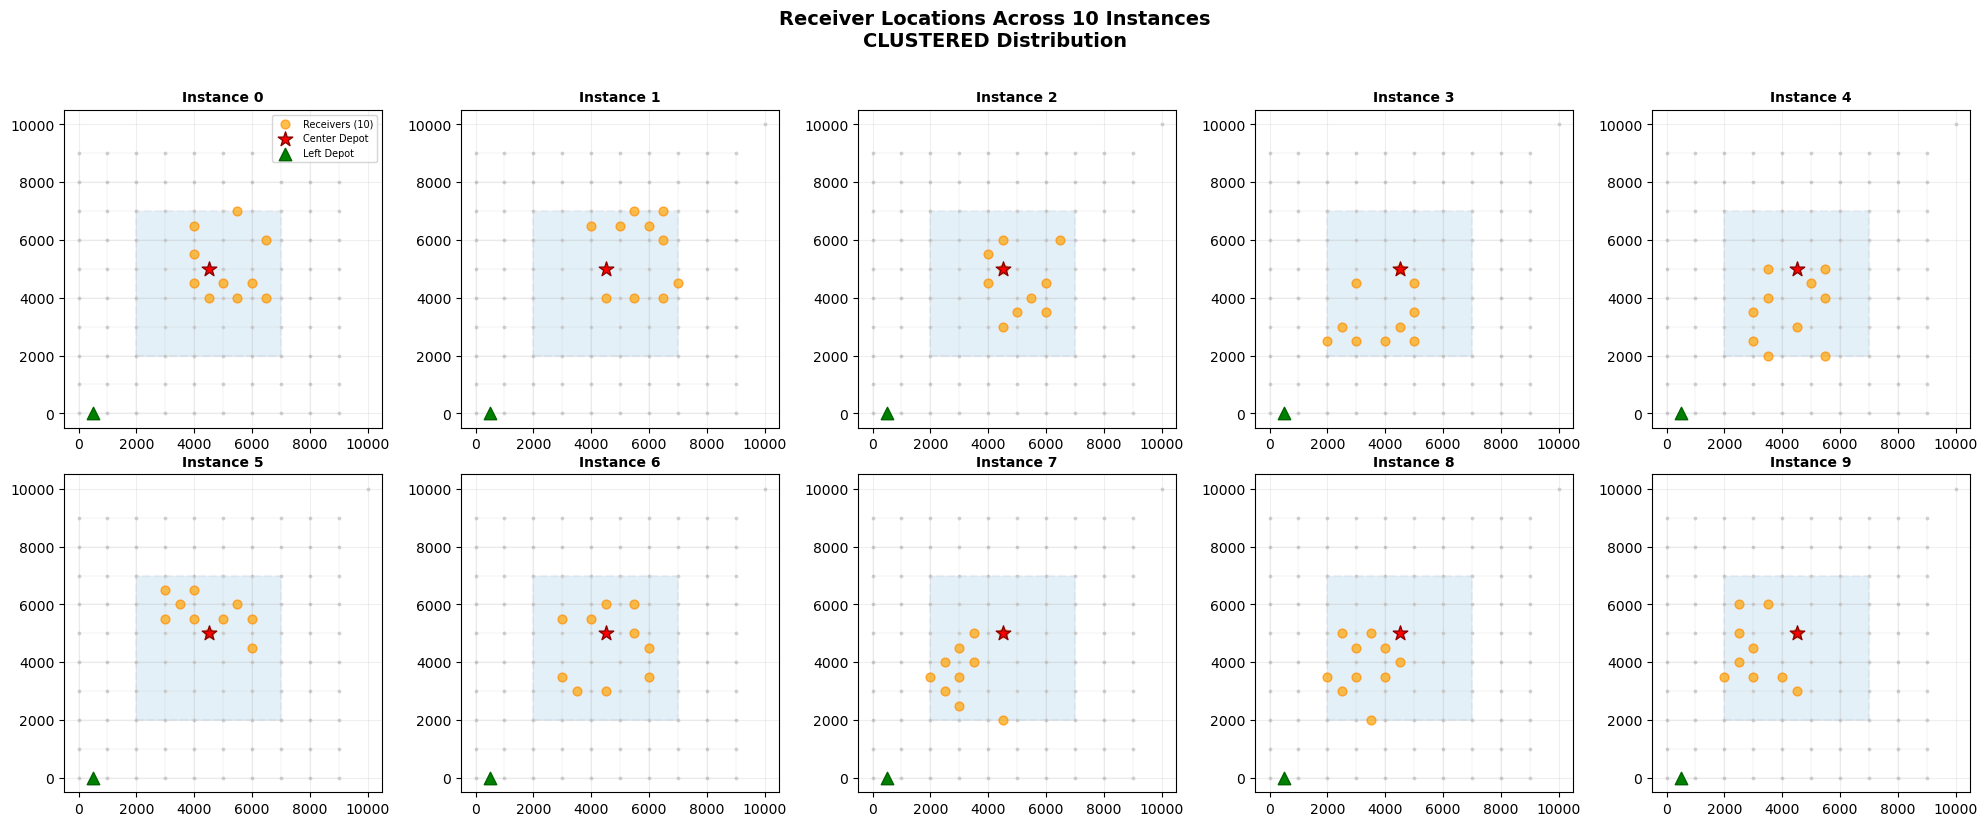

In [56]:
# Plot all 10 instances for CLUSTERED distribution
plot_all_instances_receiver_locations(chessboard_output_path, customer_distribution_type='CLUSTERED')

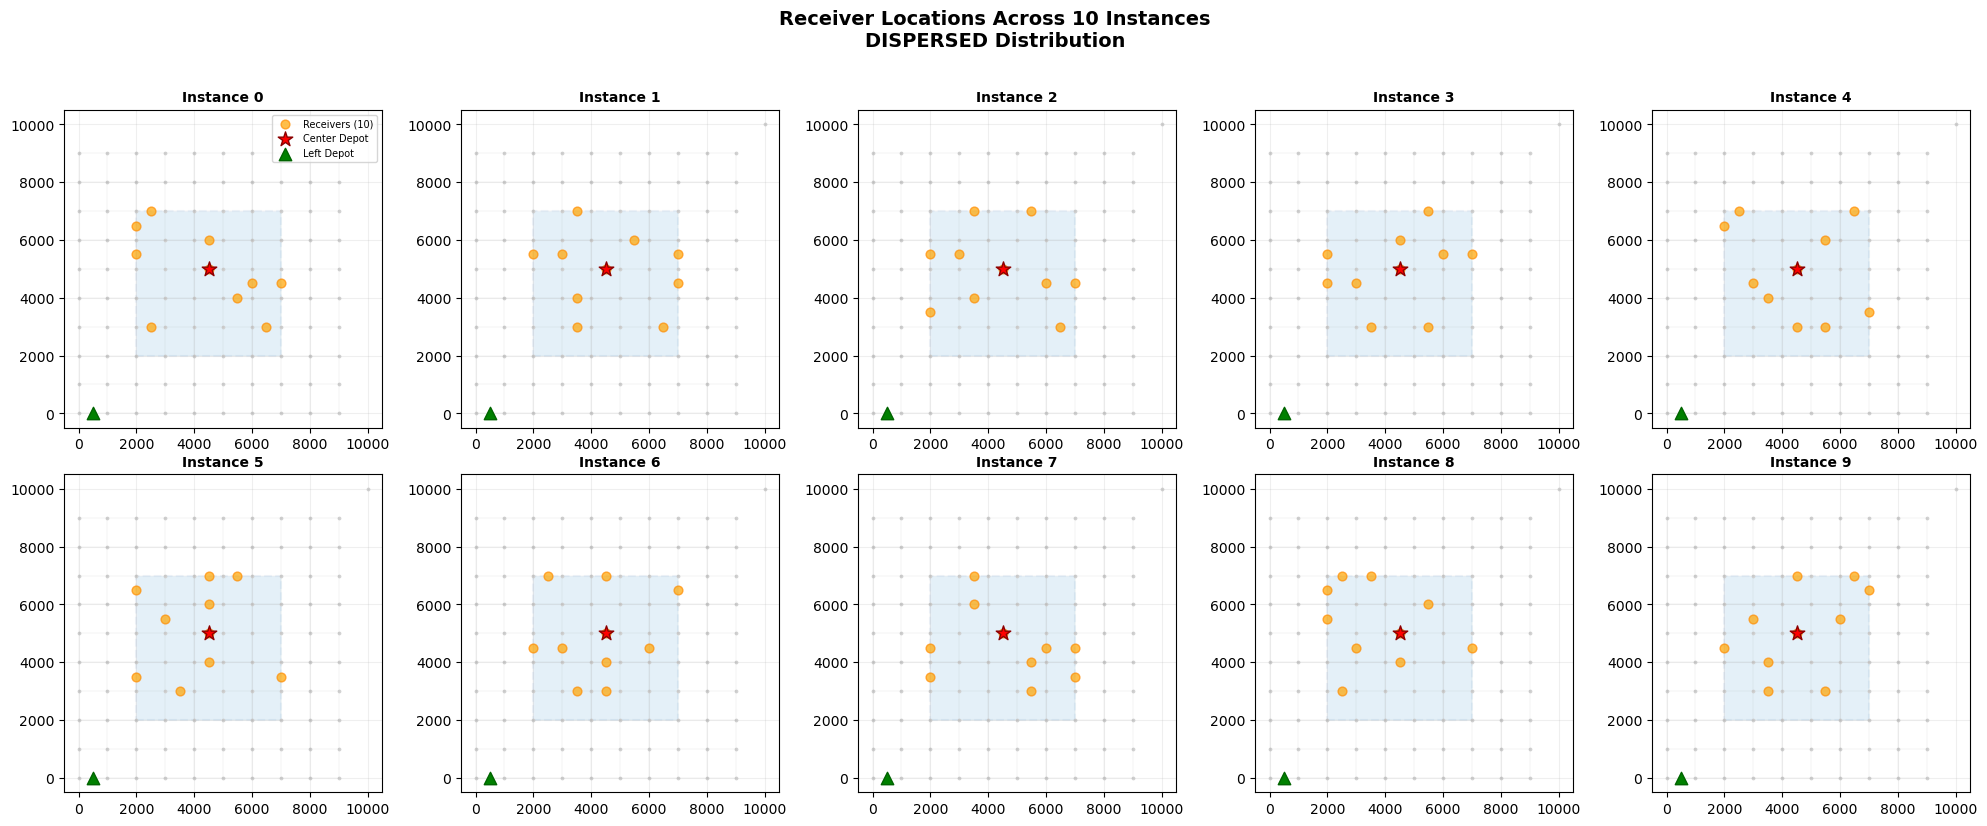

In [57]:
# Plot all 10 instances for DISPERSED distribution
plot_all_instances_receiver_locations(chessboard_output_path, customer_distribution_type='DISPERSED')

## Example Usage: Visualize Network

Loaded 10 receivers and 1 carriers

Receiver locations sample (first 5):
  receiver_00: linkId=i(5,4), coords=(4500.0, 4000.0)
  receiver_01: linkId=i(7,4), coords=(6500.0, 4000.0)
  receiver_02: linkId=i(6,4), coords=(5500.0, 4000.0)
  receiver_03: linkId=i(6,7)R, coords=(5500.0, 7000.0)
  receiver_04: linkId=j(5,5), coords=(5000.0, 4500.0)

Carrier depot locations:
  carrier1: depotLinks={'i(5,5)R'}, coords=[(4500.0, 5000.0)]


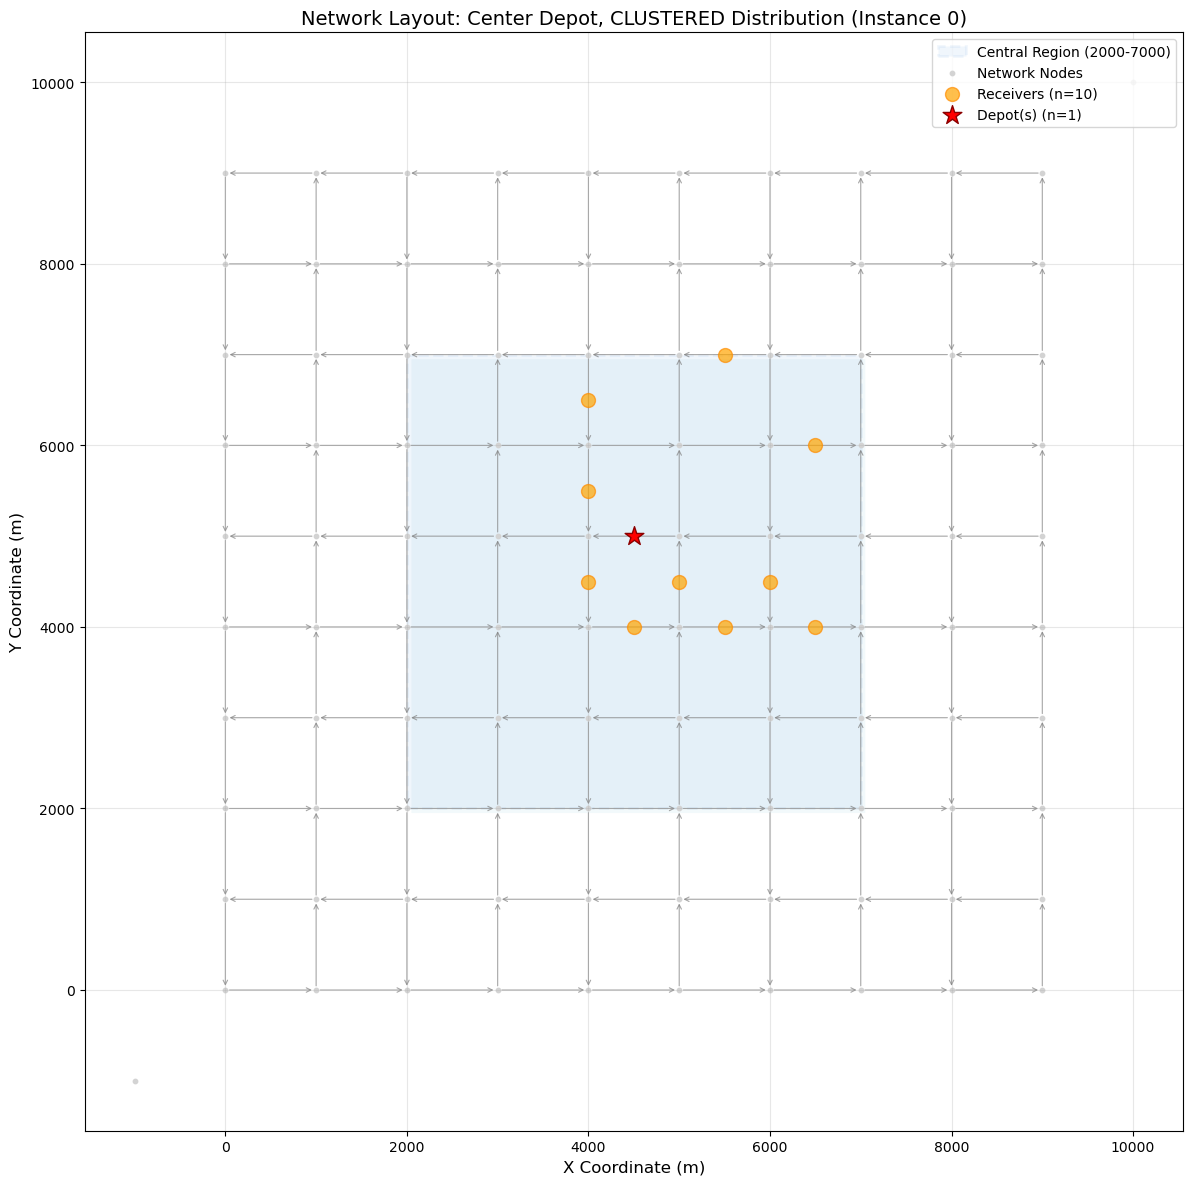

In [51]:
# Single instance visualization example
sample_folder = 'center-CLUSTERED-penSweep-af0.80-p0.0000-exactShapley-i00'
location_data = collect_location_data_for_instance(chessboard_output_path, sample_folder)

print(f"Loaded {len(location_data['receiver_locations'])} receivers and {len(location_data['carrier_depots'])} carriers")
print(f"\nReceiver locations sample (first 5):")
for i, (rec_id, link_id) in enumerate(list(location_data['receiver_locations'].items())[:5]):
    print(f"  {rec_id}: linkId={link_id}, coords={location_data['receiver_coords'].get(rec_id)}")
print(f"\nCarrier depot locations:")
for carrier_id, depot_links in location_data['carrier_depots'].items():
    print(f"  {carrier_id}: depotLinks={depot_links}, coords={location_data['depot_coords'].get(carrier_id)}")

plot_network_with_locations(location_data, depot='center', customer_distribution_type='CLUSTERED', instance=0)

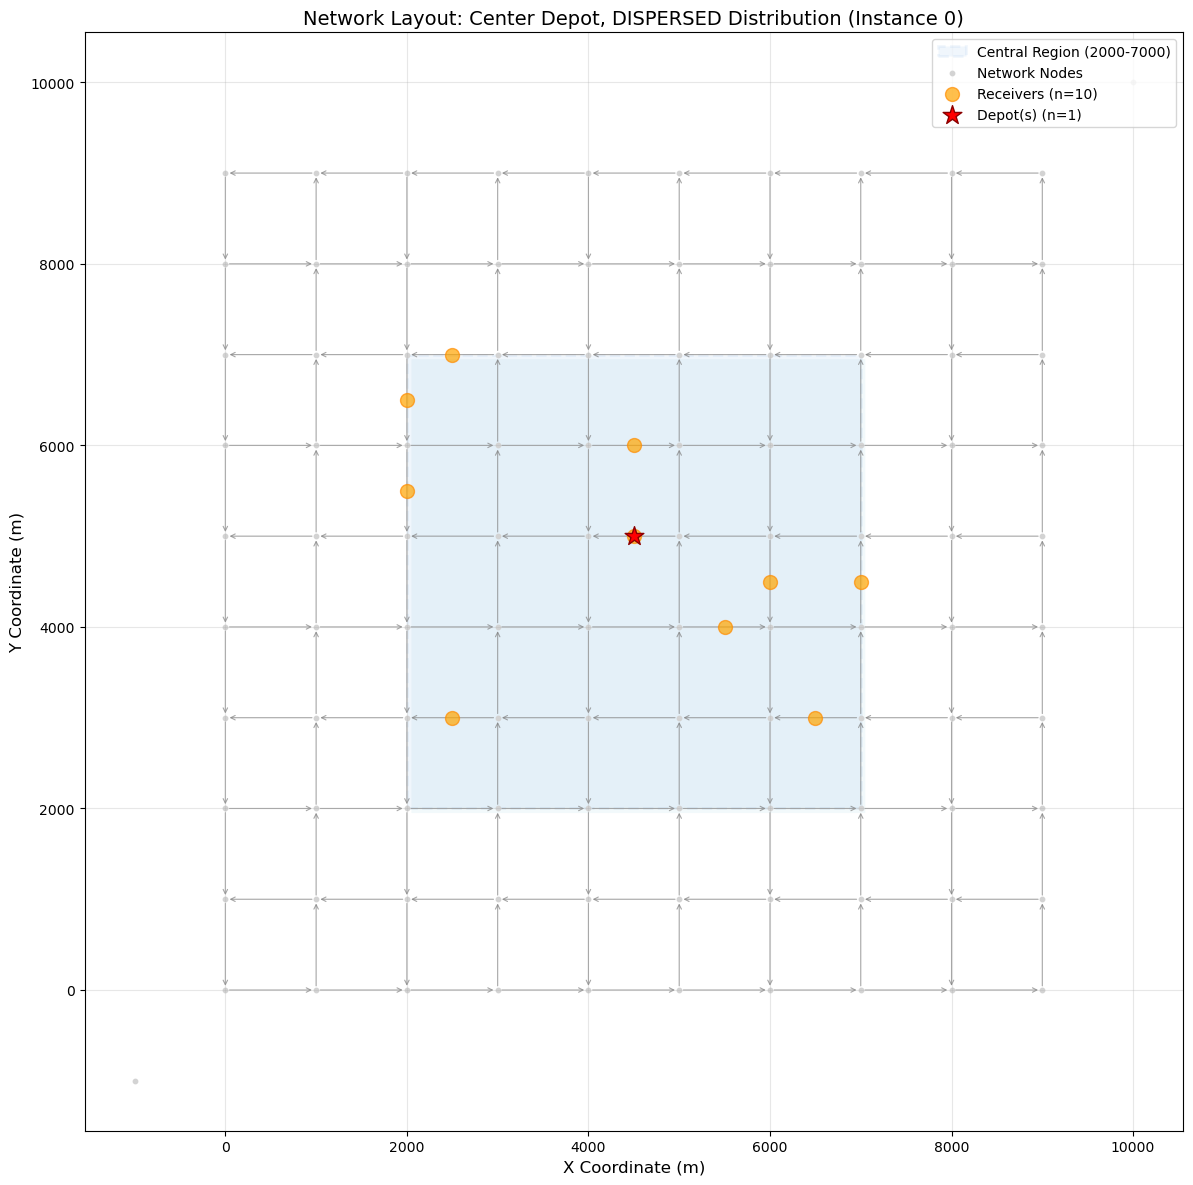

In [52]:
# Single instance visualization example
sample_folder = 'center-Dispersed-penSweep-af0.80-p0.0000-exactShapley-i00'
location_data = collect_location_data_for_instance(chessboard_output_path, sample_folder)
plot_network_with_locations(location_data, depot='center', customer_distribution_type='DISPERSED', instance=0)